In [6]:
import pandas as pd
import sqlite3
import os

print("Librairies chargées ✓")

Librairies chargées ✓


In [7]:
# Cellule 2 — Chargement du NOUVEAU dataset
df_raw = pd.read_csv(
    r"C:\Users\Jean Lavital\ALTER11\data\raw\players_data-2025_2026.csv",
    encoding="utf-8",
    sep=","
)

print(f"Shape : {df_raw.shape}")
print(f"Ligues : {df_raw['Comp'].value_counts().to_string()}")

Shape : (2779, 102)
Ligues : Comp
es La Liga            594
it Serie A            585
fr Ligue 1            554
eng Premier League    544
de Bundesliga         502


In [8]:
# # Cellule 3 — VERSION 2 avec stats défensives
rename_map = {
    "Player": "player_name",
    "Nation": "nation_raw",
    "Pos":    "position_raw",
    "Squad":  "team_name",
    "Comp":   "competition",
    "Age":    "age_raw",
    "Born":   "birth_year",
    "MP":     "matches_played",
    "Min":    "minutes",
    "90s":    "nineties",
    "Gls":    "goals",
    "Ast":    "assists",
    "Sh":     "shots",
    "SoT":    "shots_on_target",
    "Int":    "interceptions",
    "TklW":   "tackles_won",
    "CrdY":   "yellow_cards",
    "CrdR":   "red_cards",
    # Nouvelles colonnes
    "Fls":    "fouls_committed",
    "Fld":    "fouls_drawn",
    "Crs":    "crosses",
    "Mn/MP":  "min_per_match",
    "+/-":    "plus_minus",
    "PPM":    "points_per_match",
}

cols = {k: v for k, v in rename_map.items() if k in df_raw.columns}
df = df_raw[list(cols.keys())].rename(columns=cols).copy()

print(f"Colonnes gardées : {len(df.columns)}")
print(list(df.columns))

Colonnes gardées : 24
['player_name', 'nation_raw', 'position_raw', 'team_name', 'competition', 'age_raw', 'birth_year', 'matches_played', 'minutes', 'nineties', 'goals', 'assists', 'shots', 'shots_on_target', 'interceptions', 'tackles_won', 'yellow_cards', 'red_cards', 'fouls_committed', 'fouls_drawn', 'crosses', 'min_per_match', 'plus_minus', 'points_per_match']


In [9]:
# Cellule 4 — Nettoyage + filtre Ligue 1
# Supprimer les lignes parasites
df = df[df["player_name"] != "Player"].dropna(subset=["player_name"])
df = df[~df["team_name"].isin(["2TM", "3TM"])].copy()

# Nettoyer Nation : "fr FRA" → "FRA"
df["nation"] = df["nation_raw"].str.split().str[-1].str.upper()

# Nettoyer Position : "MF,FW" → "MF"
df["position"] = df["position_raw"].str.split(",").str[0].str.strip()
df["position"] = df["position"].map({"GK":"GK","DF":"DF","MF":"MF","FW":"FW"}).fillna("MF")

# Age en entier
df["age"] = pd.to_numeric(df["age_raw"], errors="coerce").fillna(0).astype(int)

# Toutes les stats en numérique
num_cols = ["birth_year","matches_played","minutes","nineties",
            "goals","assists","shots","shots_on_target",
            "interceptions","tackles_won","yellow_cards","red_cards"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

LIGUES = ['fr Ligue 1', 'es La Liga', 'it Serie A', 'eng Premier League', 'de Bundesliga']
df_l1 = df[df["competition"].isin(LIGUES)].copy()

print(f"Total joueurs 5 ligues : {len(df_l1)}")
print(f"Par ligue :\n{df_l1['competition'].value_counts()}")
print(f"U20 (≤20 ans) : {len(df_l1[df_l1['age'] <= 20])}")

Total joueurs 5 ligues : 2779
Par ligue :
competition
es La Liga            594
it Serie A            585
fr Ligue 1            554
eng Premier League    544
de Bundesliga         502
Name: count, dtype: int64
U20 (≤20 ans) : 373


In [10]:
# Cellule 5 — Construction des tables et export SQLite

# dim_team
dim_team = (
    df_l1[["team_name", "competition"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_team.insert(0, "team_id", range(1, len(dim_team) + 1))

# dim_player
df_l1 = df_l1.merge(dim_team[["team_id", "team_name"]], on="team_name", how="left")
dim_player = (
    df_l1[["player_name", "nation", "position", "birth_year", "age", "team_id"]]
    .drop_duplicates(subset=["player_name"])
    .reset_index(drop=True)
)
dim_player.insert(0, "player_id", range(1, len(dim_player) + 1))

# fact_stats
df_l1 = df_l1.merge(dim_player[["player_id", "player_name"]], on="player_name", how="left")
stat_cols = [
    "player_id", "matches_played", "minutes", "nineties",
    "goals", "assists", "shots", "shots_on_target",
    "interceptions", "tackles_won", "yellow_cards", "red_cards",
    "fouls_committed", "fouls_drawn", "min_per_match",
    "plus_minus", "points_per_match", "crosses"  # ← ajouté
]
fact_stats = df_l1[stat_cols].copy()
fact_stats.insert(0, "stat_id", range(1, len(fact_stats) + 1))

# Export SQLite
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
dim_team.to_sql("dim_team", conn, if_exists="replace", index=False)
dim_player.to_sql("dim_player", conn, if_exists="replace", index=False)
fact_stats.to_sql("fact_stats", conn, if_exists="replace", index=False)
conn.close()

print(f"dim_team    : {len(dim_team)} clubs")
print(f"dim_player  : {len(dim_player)} joueurs")
print(f"fact_stats  : {len(fact_stats)} lignes")
print("✓ Base alter11.db créée !")

dim_team    : 96 clubs
dim_player  : 2627 joueurs
fact_stats  : 2779 lignes
✓ Base alter11.db créée !


In [11]:
# Cellule 6 — ALTERSCORE Attaquants U20 
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

query = """
    SELECT 
        p.player_name,
        p.age,
        t.team_name,
        f.minutes,
        f.matches_played,
        ROUND(f.minutes / NULLIF(f.matches_played, 0), 0)  AS min_par_match,
        f.goals,
        f.shots,
        ROUND(f.shots  / NULLIF(f.nineties, 0), 2)         AS tirs_p90,
        ROUND(f.shots_on_target / NULLIF(f.nineties, 0), 2) AS tirs_cadres_p90,
        ROUND(f.goals  / NULLIF(f.shots, 0) * 100, 1)      AS ratio_buts_tirs_pct,
        f.assists,

        -- ALTERSCORE : volume + audace + efficacité + régularité + bonus âge
        ROUND(
            (f.shots / NULLIF(f.nineties, 0)) * 2.5
          + (f.shots_on_target / NULLIF(f.nineties, 0)) * 2.0
          + (f.goals / NULLIF(f.shots, 0)) * 8
          + (f.minutes / NULLIF(f.matches_played, 0)) / 25
          + CASE WHEN p.age <= 18 THEN 4
                 WHEN p.age <= 19 THEN 3
                 WHEN p.age = 20  THEN 2
                 ELSE 1 END
        , 2) AS alterscore

    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team   t ON p.team_id   = t.team_id
    WHERE p.position = 'FW'
      AND p.age <= 20
      AND f.minutes >= 200
    ORDER BY alterscore DESC
    LIMIT 15
"""

top_fw = pd.read_sql(query, conn)
conn.close()

print("🔥 ALTERSCORE — Attaquants U20 Ligue 1 2025/2026\n")
print(top_fw.to_string(index=False))

🔥 ALTERSCORE — Attaquants U20 Ligue 1 2025/2026

          player_name  age           team_name  minutes  matches_played  min_par_match  goals  shots  tirs_p90  tirs_cadres_p90  ratio_buts_tirs_pct  assists  alterscore
Charalampos Kostoulas   18            Brighton      325              18           18.0      2     17      4.72             1.94                  0.0        1       19.69
              Endrick   19         Real Madrid     1055              14           75.0      5     40      3.42             1.97                  0.0        6       18.48
         Said El Mala   19                Köln     1787              32           55.0     12     71      3.57             1.41                  0.0        4       16.73
          Kader Meïté   18              Rennes      535              17           31.0      3     22      3.73             1.19                  0.0        2       16.69
    George Ilenikhena   19              Monaco      385              15           25.0      2     15 

In [12]:
print(list(df_raw.columns))

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_s

In [13]:
for i, col in enumerate(df_raw.columns):
    print(f"{i:3} | {col}")

  0 | Rk
  1 | Player
  2 | Nation
  3 | Pos
  4 | Squad
  5 | Comp
  6 | Age
  7 | Born
  8 | MP
  9 | Starts
 10 | Min
 11 | 90s
 12 | Gls
 13 | Ast
 14 | G+A
 15 | G-PK
 16 | PK
 17 | PKatt
 18 | CrdY
 19 | CrdR
 20 | G+A-PK
 21 | Rk_stats_keeper
 22 | Nation_stats_keeper
 23 | Pos_stats_keeper
 24 | Comp_stats_keeper
 25 | Age_stats_keeper
 26 | Born_stats_keeper
 27 | MP_stats_keeper
 28 | Starts_stats_keeper
 29 | Min_stats_keeper
 30 | 90s_stats_keeper
 31 | GA
 32 | GA90
 33 | SoTA
 34 | Saves
 35 | Save%
 36 | W
 37 | D
 38 | L
 39 | CS
 40 | CS%
 41 | PKatt_stats_keeper
 42 | PKA
 43 | PKsv
 44 | PKm
 45 | Rk_stats_shooting
 46 | Nation_stats_shooting
 47 | Pos_stats_shooting
 48 | Comp_stats_shooting
 49 | Age_stats_shooting
 50 | Born_stats_shooting
 51 | 90s_stats_shooting
 52 | Gls_stats_shooting
 53 | Sh
 54 | SoT
 55 | SoT%
 56 | Sh/90
 57 | SoT/90
 58 | G/Sh
 59 | G/SoT
 60 | PK_stats_shooting
 61 | PKatt_stats_shooting
 62 | Rk_stats_playing_time
 63 | Nation_stats_pl

In [14]:
# Cellule 7 — ALTERSCORE Milieux U20
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

query_mf = """
    SELECT 
        p.player_name,
        p.age,
        t.team_name,
        f.minutes,
        f.matches_played,
        ROUND(f.minutes / NULLIF(f.matches_played, 0), 0)   AS min_par_match,
        f.goals,
        f.assists,
        f.shots,
        ROUND(f.shots    / NULLIF(f.nineties, 0), 2)        AS tirs_p90,
        ROUND(f.assists  / NULLIF(f.nineties, 0), 2)        AS passes_p90,
        f.interceptions,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)   AS int_p90,

        -- ALTERSCORE MF : box-to-box, double contribution off+def + régularité + bonus âge
        ROUND(
            (f.shots    / NULLIF(f.nineties, 0)) * 1.5
          + (f.assists  / NULLIF(f.nineties, 0)) * 3.0
          + (f.goals    / NULLIF(f.nineties, 0)) * 4.0
          + (f.interceptions / NULLIF(f.nineties, 0)) * 2.0
          + (f.minutes  / NULLIF(f.matches_played, 0)) / 30
          + CASE WHEN p.age <= 18 THEN 4
                 WHEN p.age <= 19 THEN 3
                 WHEN p.age =  20 THEN 2
                 ELSE 1 END
        , 2) AS alterscore

    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team   t ON p.team_id   = t.team_id
    WHERE p.position = 'MF'
      AND p.age <= 20
      AND f.minutes >= 200
    ORDER BY alterscore DESC
    LIMIT 10
"""

top_mf = pd.read_sql(query_mf, conn)
conn.close()
print("🔥 ALTERSCORE — Milieux U20 Ligue 1 2025/2026\n")
print(top_mf.to_string(index=False))

🔥 ALTERSCORE — Milieux U20 Ligue 1 2025/2026

      player_name  age           team_name  minutes  matches_played  min_par_match  goals  assists  shots  tirs_p90  passes_p90  interceptions  int_p90  alterscore
     Lamine Yamal   18           Barcelona     2262              28           80.0     16       11    117      4.66        0.44              8     0.32       17.49
     Nathan Mbala   18                Metz      402              12           33.0      2        2     14      3.11        0.44              1     0.22       13.22
     Lennart Karl   18       Bayern Munich     1206              24           50.0      5        4     39      2.91        0.30              9     0.67       13.10
    Ethan Nwaneri   19             Arsenal      324               9           36.0      2        1      9      2.50        0.28              3     0.83       12.47
         Can Uzun   20 Eintracht Frankfurt     1097              20           54.0      8        4     40      3.28        0.33       

In [15]:
# Cellule 8 — ALTERSCORE Défenseurs U20
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

query_df = """
    SELECT 
        p.player_name,
        p.age,
        t.team_name,
        f.minutes,
        f.matches_played,
        ROUND(f.minutes / NULLIF(f.matches_played, 0), 0)     AS min_par_match,
        f.interceptions,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)     AS int_p90,
        f.tackles_won,
        ROUND(f.tackles_won   / NULLIF(f.nineties, 0), 2)     AS tacles_p90,
        f.assists,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)           AS passes_p90,

        -- ALTERSCORE DF : solidité défensive + contribution offensive + régularité + bonus âge
        ROUND(
            (f.interceptions  / NULLIF(f.nineties, 0)) * 3.0
          + (f.tackles_won    / NULLIF(f.nineties, 0)) * 3.0
          + (f.assists        / NULLIF(f.nineties, 0)) * 2.5
          + (f.minutes / NULLIF(f.matches_played, 0)) / 25
          + CASE WHEN p.age <= 18 THEN 4
                 WHEN p.age <= 19 THEN 3
                 WHEN p.age =  20 THEN 2
                 ELSE 1 END
        , 2) AS alterscore

    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team   t ON p.team_id   = t.team_id
    WHERE p.position = 'DF'
      AND p.age <= 20
      AND f.minutes >= 200
    ORDER BY alterscore DESC
    LIMIT 10
"""

top_df = pd.read_sql(query_df, conn)
conn.close()
print("🔥 ALTERSCORE — Défenseurs U20 Europe 2025/2026\n")
print(top_df.to_string(index=False))

🔥 ALTERSCORE — Défenseurs U20 Europe 2025/2026

       player_name  age       team_name  minutes  matches_played  min_par_match  interceptions  int_p90  tackles_won  tacles_p90  assists  passes_p90  alterscore
Enzo Koffi Vinette   20        Le Havre      329              12           27.0              9     2.43           10        2.70        0         0.0       18.41
    Oliver Scarles   20 West Ham United      659              13           50.0             13     1.78           19        2.60        0         0.0       17.15
      Buba Sangaré   18           Elche      401               8           50.0              5     1.11           10        2.22        0         0.0       16.00
      Marius Louer   19          Angers      453               8           56.0              2     0.40           15        3.00        0         0.0       15.20
  Mahamadou Nagida   20          Rennes      640              17           37.0             19     2.68            9        1.27        0     

In [16]:
# Cellule 7 — ALTERSCORE GLOBAL (tous postes confondus)
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

query = """
    WITH base AS (
        SELECT
            p.player_name,
            p.age,
            p.position,
            t.team_name,
            f.minutes,
            f.matches_played,
            f.nineties,
            f.goals,
            f.assists,
            f.shots,
            f.shots_on_target,
            f.interceptions,
            f.tackles_won,

            -- composantes brutes
            ROUND(f.minutes / NULLIF(f.matches_played, 0), 1)          AS min_par_match,
            ROUND((f.goals + f.assists) / NULLIF(f.nineties, 0), 2)    AS impact_off_p90,
            ROUND((f.interceptions + f.tackles_won) / NULLIF(f.nineties, 0), 2) AS activite_def_p90,
            ROUND(f.shots / NULLIF(f.nineties, 0), 2)                  AS tirs_p90

        FROM fact_stats f
        JOIN dim_player p ON f.player_id = p.player_id
        JOIN dim_team   t ON p.team_id   = t.team_id
        WHERE p.age <= 20
          AND f.minutes >= 200
    )
    SELECT
        player_name,
        age,
        position,
        team_name,
        minutes,
        min_par_match,
        impact_off_p90,
        activite_def_p90,
        tirs_p90,

        -- ALTERSCORE GLOBAL sur 100
        ROUND(
            -- régularité /90 (max théorique ~90 min/match)
            (MIN(min_par_match, 90) / 90.0 * 100 * 0.30)
            -- impact offensif /90 (max théorique ~1.5)
          + (MIN(impact_off_p90, 1.5) / 1.5 * 100 * 0.30)
            -- activité défensive /90 (max théorique ~8)
          + (MIN(activite_def_p90, 8.0) / 8.0 * 100 * 0.20)
            -- bonus jeunesse (18→20 pts, 19→15, 20→10)
          + CASE WHEN age <= 18 THEN 20
                 WHEN age <= 19 THEN 15
                 WHEN age =  20 THEN 10
                 ELSE 5 END
        , 1) AS alterscore

    FROM base
    ORDER BY alterscore DESC
    LIMIT 20
"""

top = pd.read_sql(query, conn)
conn.close()

print("🔥 ALTERSCORE GLOBAL U20 — Europe 2025/2026\n")
print(top.to_string(index=False))

🔥 ALTERSCORE GLOBAL U20 — Europe 2025/2026

       player_name  age position           team_name  minutes  min_par_match  impact_off_p90  activite_def_p90  tirs_p90  alterscore
      Lamine Yamal   18       MF           Barcelona     2262           80.0            1.08              1.12      4.66        71.1
           Endrick   19       FW         Real Madrid     1055           75.0            0.94              0.85      3.42        60.9
      Yan Diomandé   19       FW          RB Leipzig     2303           74.0            0.74              1.29      1.95        57.7
       Robinio Vaz   19       FW           Marseille      379           27.0            1.43              1.67      1.90        56.8
      Lennart Karl   18       MF       Bayern Munich     1206           50.0            0.67              1.72      2.91        54.4
             Rayan   19       MF         Bournemouth      878           73.0            0.61              1.12      2.35        54.3
    Ayyoub Bouaddi   18  

In [17]:
# Ajouter la colonne min_pct à fact_stats
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
try:
    conn.execute("ALTER TABLE fact_stats ADD COLUMN min_pct REAL DEFAULT 0")
    conn.commit()
    print("✓ Colonne min_pct ajoutée")
except:
    print("Colonne déjà existante")
conn.close()

✓ Colonne min_pct ajoutée


In [18]:
# Cellule — Ajout Min% dans fact_stats
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

# Récupérer Min% depuis le dataset brut filtré Ligue 1
df_minpct = df_raw[df_raw['Comp'] == 'fr Ligue 1'][['Player', 'Min%']].copy()
df_minpct.columns = ['player_name', 'min_pct']
df_minpct['min_pct'] = pd.to_numeric(df_minpct['min_pct'], errors='coerce').fillna(0)

# Récupérer les player_id
dim_player_db = pd.read_sql("SELECT player_id, player_name FROM dim_player", conn)
df_minpct = df_minpct.merge(dim_player_db, on='player_name', how='inner')

# Mettre à jour fact_stats
for _, row in df_minpct.iterrows():
    conn.execute(f"""
        UPDATE fact_stats 
        SET min_pct = {row['min_pct']} 
        WHERE player_id = {row['player_id']}
    """)

conn.commit()
conn.close()
print("✓ Min% ajouté dans fact_stats")

✓ Min% ajouté dans fact_stats


In [19]:
# Cellule — ALTERSCORE GLOBAL V2 (Min% au lieu de min_par_match)
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

query = """
    WITH base AS (
        SELECT
            p.player_name,
            p.age,
            p.position,
            t.team_name,
            f.minutes,
            f.min_pct,
            f.nineties,
            ROUND((f.goals + f.assists) / NULLIF(f.nineties, 0), 2)             AS impact_off_p90,
            ROUND((f.interceptions + f.tackles_won) / NULLIF(f.nineties, 0), 2) AS activite_def_p90,
            ROUND(f.shots / NULLIF(f.nineties, 0), 2)                           AS tirs_p90

        FROM fact_stats f
        JOIN dim_player p ON f.player_id = p.player_id
        JOIN dim_team   t ON p.team_id   = t.team_id
        WHERE p.age <= 20
          AND f.minutes >= 200
    )
    SELECT
        player_name,
        age,
        position,
        team_name,
        minutes,
        min_pct,
        impact_off_p90,
        activite_def_p90,
        tirs_p90,

        ROUND(
            -- régularité via Min% (titulaire indiscutable = 100%)
            (MIN(min_pct, 100) / 100.0 * 100 * 0.25)
            -- impact offensif /90
          + (MIN(impact_off_p90, 1.5) / 1.5 * 100 * 0.35)
            -- activité défensive /90
          + (MIN(activite_def_p90, 8.0) / 8.0 * 100 * 0.15)
            -- bonus jeunesse
          + CASE WHEN age <= 17 THEN 25
                 WHEN age <= 18 THEN 20
                 WHEN age <= 19 THEN 15
                 WHEN age =  20 THEN 10
                 ELSE 5 END
        , 1) AS alterscore

    FROM base
    ORDER BY alterscore DESC
    LIMIT 20
"""

top = pd.read_sql(query, conn)
conn.close()

print("🔥 ALTERSCORE GLOBAL V2 U20 — Ligue 1 2025/2026\n")
print(top.to_string(index=False))

🔥 ALTERSCORE GLOBAL V2 U20 — Ligue 1 2025/2026

          player_name  age position           team_name  minutes  min_pct  impact_off_p90  activite_def_p90  tirs_p90  alterscore
          Robinio Vaz   19       FW           Marseille      379     13.2            1.43              1.67      1.90        54.8
              Endrick   19       FW         Real Madrid     1055     36.6            0.94              0.85      3.42        47.7
         Lamine Yamal   18       MF           Barcelona     2262      0.0            1.08              1.12      4.66        47.3
         Nathan Mbala   18       MF                Metz      402     14.0            0.89              1.56      3.11        47.2
          Kader Meïté   18       FW              Rennes      535     18.6            0.85              0.51      3.73        45.4
       Ayyoub Bouaddi   18       MF               Lille     2186     75.9            0.04              2.55      0.62        44.7
         Senny Mayulu   19       MF Paris 

In [20]:
# ALTERSCORE V3 — avec coefficient de fiabilité
query = """
    WITH base AS (
        SELECT
            p.player_name,
            p.age,
            p.position,
            t.team_name,
            f.minutes,
            f.min_pct,
            f.nineties,
            ROUND((f.goals + f.assists) / NULLIF(f.nineties, 0), 2)             AS impact_off_p90,
            ROUND((f.interceptions + f.tackles_won) / NULLIF(f.nineties, 0), 2) AS activite_def_p90,
            ROUND(f.shots / NULLIF(f.nineties, 0), 2)                           AS tirs_p90
        FROM fact_stats f
        JOIN dim_player p ON f.player_id = p.player_id
        JOIN dim_team   t ON p.team_id   = t.team_id
        WHERE p.age <= 20
  AND f.minutes >= 200
  AND p.player_name != 'Robinio Vaz'
  AND p.position != 'GK'
    ),
    scored AS (
        SELECT *,
            ROUND(
             (MIN(min_pct, 100) / 100.0 * 100 * 0.20)
+ (MIN(impact_off_p90, 1.5) / 1.5 * 100 * 0.40)
+ (MIN(activite_def_p90, 8.0) / 8.0 * 100 * 0.10)
              + CASE WHEN age <= 17 THEN 25
                     WHEN age <= 18 THEN 20
                     WHEN age <= 19 THEN 15
                     WHEN age =  20 THEN 10
                     ELSE 5 END
            , 1) AS score_brut
        FROM base
    )
    SELECT
        player_name, age, position, team_name,
        minutes, min_pct, impact_off_p90, activite_def_p90,

        -- coefficient fiabilité : pénalise les petits échantillons
        -- 200 min → 0.60 | 500 min → 0.80 | 900 min → 0.95 | 1500+ min → 1.0
        ROUND(
            score_brut * MIN(1.0, 0.5 + (minutes / 3000.0))
        , 1) AS alterscore

    FROM scored
    ORDER BY alterscore DESC
    LIMIT 20
"""

conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
top = pd.read_sql(query, conn)
conn.close()

print("🔥 ALTERSCORE V3 U20 — Ligue 1 2025/2026\n")
print(top.to_string(index=False))

🔥 ALTERSCORE V3 U20 — Ligue 1 2025/2026

       player_name  age position           team_name  minutes  min_pct  impact_off_p90  activite_def_p90  alterscore
      Lamine Yamal   18       MF           Barcelona     2262      0.0            1.08              1.12        50.2
           Endrick   19       FW         Real Madrid     1055     36.6            0.94              0.85        41.2
      Senny Mayulu   19       MF Paris Saint-Germain     1459     52.3            0.49              2.04        40.5
    Ayyoub Bouaddi   18       MF               Lille     2186     75.9            0.04              2.55        39.4
      Said El Mala   19       FW                Köln     1787      0.0            0.80              0.90        37.5
      Yan Diomandé   19       FW          RB Leipzig     2303      0.0            0.74              1.29        36.3
      Lennart Karl   18       MF       Bayern Munich     1206      0.0            0.67              1.72        36.1
Warren Zaïre-Emery   20

In [21]:
import subprocess
subprocess.run(["pip", "install", "requests", "Pillow"], check=True)
print("✓ Libs installées")

✓ Libs installées


In [22]:
API_KEY = "oHg5x9bvaJTzindcTNictsmS"

In [23]:
import requests
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
import os

API_KEY = "oHg5x9bvaJTzindcTNictsmS"  # colle ta nouvelle clé ici

def detourer_photo(url_photo, nom_joueur):
    """Télécharge d'abord la photo, puis l'envoie à remove.bg"""
    
    # Étape 1 : télécharger la photo localement
    headers = {"User-Agent": "Mozilla/5.0"}
    img_response = requests.get(url_photo, headers=headers)
    
    if img_response.status_code != 200:
        print(f"✗ Impossible de télécharger la photo de {nom_joueur}")
        return None
    
    # Étape 2 : envoyer le fichier à remove.bg
    response = requests.post(
        "https://api.remove.bg/v1.0/removebg",
        files={"image_file": ("photo.jpg", img_response.content, "image/jpeg")},
        data={"size": "auto"},
        headers={"X-Api-Key": API_KEY},
    )
    
    if response.status_code == 200:
        img_detoure = Image.open(BytesIO(response.content)).convert("RGBA")
        
        fond = Image.new("RGBA", (400, 500), (3, 8, 6, 255))
        draw = ImageDraw.Draw(fond)
        for x in range(0, 400, 20):
            draw.line([(x, 0), (x, 500)], fill=(0, 255, 106, 15), width=1)
        for y in range(0, 500, 20):
            draw.line([(0, y), (400, y)], fill=(0, 255, 106, 15), width=1)
        
        img_detoure.thumbnail((380, 440))
        x = (400 - img_detoure.width) // 2
        y = 20
        fond.paste(img_detoure, (x, y), img_detoure)
        
        draw.rectangle([(0, 460), (400, 462)], fill=(0, 255, 106, 200))
        draw.text((20, 468), nom_joueur.upper(), fill=(232, 245, 236, 255))
        
        os.makedirs("data/photos", exist_ok=True)
        chemin = f"data/photos/{nom_joueur.replace(' ', '_')}.png"
        fond.save(chemin)
        print(f"✓ {nom_joueur} — carte générée → {chemin}")
        return chemin
    else:
        print(f"✗ Erreur remove.bg {response.status_code} : {response.text}")
        return None

# Test sur Endrick
detourer_photo(
    "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4a/Endrick_2024.jpg/220px-Endrick_2024.jpg",
    "Endrick"
)

✗ Impossible de télécharger la photo de Endrick


In [24]:
# Test — photo Ligue 1 déjà détourée !
url_endrick = "https://s3.eu-west-3.amazonaws.com/ligue1.image/players/2025/all/player_official_2025_143_577107-400x300.png"

img_response = requests.get(url_endrick, headers={"User-Agent": "Mozilla/5.0"})
print(f"Status : {img_response.status_code}")
print(f"Taille : {len(img_response.content)} bytes")

if img_response.status_code == 200:
    img = Image.open(BytesIO(img_response.content))
    print(f"Mode : {img.mode}")  # RGBA = fond transparent ✓
    print(f"Size : {img.size}")

Status : 200
Taille : 93325 bytes
Mode : P
Size : (800, 600)


In [25]:
# Génération carte ALTER11 avec photo Ligue 1 officielle
def generer_carte(nom_joueur, url_photo, score, pos, age, team):
    
    img_response = requests.get(url_photo, headers={"User-Agent": "Mozilla/5.0"})
    img = Image.open(BytesIO(img_response.content)).convert("RGBA")
    
    # Fond ALTER11
    fond = Image.new("RGBA", (400, 500), (2, 4, 12, 255))
    draw = ImageDraw.Draw(fond)
    
    # Grille verte
    # Grille bleue
    for x in range(0, 400, 20):
        draw.line([(x, 0), (x, 500)], fill=(0, 102, 255, 12), width=1)
    for y in range(0, 500, 20):
        draw.line([(0, y), (400, y)], fill=(0, 102, 255, 12), width=1)
    
    # Redimensionner et centrer le joueur
    img = img.resize((500, 375))
    x = (400 - img.width) // 2
    y = 60
    fond.paste(img, (x, y), img)

    # Fondu dégradé en bas du joueur
    fondu = Image.new("RGBA", (400, 200), (0, 0, 0, 0))
    draw_fondu = ImageDraw.Draw(fondu)
    for i in range(200):
        alpha = int((i / 200) ** 1.5 * 255)
        draw_fondu.rectangle([(0, i), (400, i+1)], fill=(3, 8, 6, alpha))
    fond.paste(fondu, (0, 240), fondu)
    
    # Bande inférieure
    draw.rectangle([(0, 440), (400, 500)], fill=(3, 5, 15, 240))
    draw.rectangle([(0, 440), (400, 442)], fill=(0, 102, 255, 200))
    
    # Textes
    draw.text((14, 448), nom_joueur.upper(), fill=(232, 245, 236, 255))
    draw.text((14, 468), f"{team} · {pos} · {age} ANS", fill=(74, 106, 82, 255))
    
    # Score badge
    draw.rectangle([(320, 448), (386, 490)], fill=(0, 102, 255, 30), outline=(0, 102, 255, 150))
    draw.text((328, 450), "ALTER", fill=(60, 80, 140, 255))
    draw.text((330, 463), str(score), fill=(0, 102, 255, 255))
    
    # Sauvegarder
    os.makedirs("../data/photos/alter11", exist_ok=True)
    chemin = f"../data/photos/alter11/{nom_joueur.replace(' ', '_')}.png"
    fond.save(chemin)
    print(f"✓ Carte générée → {chemin}")
    return chemin

# Test Endrick
generer_carte(
    nom_joueur="Endrick",
    url_photo="https://s3.eu-west-3.amazonaws.com/ligue1.image/players/2025/all/player_official_2025_143_577107-400x300.png",
    score=28.6,
    pos="FW",
    age=19,
    team="Lyon"
)

✓ Carte générée → ../data/photos/alter11/Endrick.png


'../data/photos/alter11/Endrick.png'

In [26]:
import re

def trouver_id_ligue1(nom_joueur):
    """Cherche l'ID Ligue 1 d'un joueur via une recherche sur le site"""
    
    nom_url = nom_joueur.lower().replace(' ', '-').replace('ï', 'i').replace('é', 'e').replace('è', 'e').replace('ë', 'e')
    url = f"https://ligue1.com/fr/player-sheet/{nom_url}"
    
    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    
    # Chercher le pattern d'URL image dans le HTML
    matches = re.findall(r'player_official_2025_\d+_(\d+)-400x300\.png', response.text)
    
    if matches:
        player_id = matches[0]
        url_photo = f"https://s3.eu-west-3.amazonaws.com/ligue1.image/players/2025/all/player_official_2025_143_{player_id}-400x300.png"
        print(f"✓ {nom_joueur} → ID {player_id}")
        return url_photo
    else:
        print(f"✗ ID introuvable pour {nom_joueur}")
        return None

# Test sur les 6 joueurs
joueurs = ["endrick", "senny-mayulu", "ayyoub-bouaddi", "warren-zaire-emery", "prosper-peter", "desire-doue"]
for j in joueurs:
    trouver_id_ligue1(j)

✗ ID introuvable pour endrick
✗ ID introuvable pour senny-mayulu
✗ ID introuvable pour ayyoub-bouaddi
✗ ID introuvable pour warren-zaire-emery
✗ ID introuvable pour prosper-peter
✗ ID introuvable pour desire-doue


In [27]:
pip install selenium webdriver-manager

Note: you may need to restart the kernel to use updated packages.


In [28]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import re
import time

def get_photo_url_ligue1(nom_joueur):
    
    nom_url = (nom_joueur.lower()
        .replace(' ', '-').replace('é','e').replace('è','e')
        .replace('ë','e').replace('ï','i').replace('ô','o')
        .replace('î','i').replace('â','a').replace('à','a')
        .replace("'","-").replace('ü','u').replace('ç','c'))
    
    url = f"https://ligue1.com/fr/player-sheet/{nom_url}"
    
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--window-size=1920,1080")
    options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36")
    
    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )
    
    try:
        driver.get(url)
        
        # Attendre jusqu'à 10 secondes que les images chargent
        try:
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.TAG_NAME, "img"))
            )
        except:
            pass
        
        time.sleep(5)  # attente supplémentaire pour le JS
        html = driver.page_source
        
        # Debug — affiche les 500 premiers caractères du body
        print(f"HTML length: {len(html)}")
        print(f"URL chargée: {driver.current_url}")
        
        # Cherche toutes les images
        imgs = driver.find_elements(By.TAG_NAME, "img")
        print(f"Images trouvées: {len(imgs)}")
        for img in imgs[:10]:
            src = img.get_attribute("src")
            if src:
                print(f"  → {src}")
        
        matches = re.findall(r'player_official_2025_\d+_(\d+)-400x300', html)
        if matches:
            player_id = matches[0]
            photo_url = f"https://s3.eu-west-3.amazonaws.com/ligue1.image/players/2025/all/player_official_2025_143_{player_id}-400x300.png"
            print(f"✓ {nom_joueur} → {photo_url}")
            return photo_url
        else:
            print("✗ Pattern non trouvé")
            return None
            
    finally:
        driver.quit()

get_photo_url_ligue1("Endrick")

HTML length: 201307
URL chargée: https://ligue1.com/fr/player-sheet/endrick/statistics
Images trouvées: 57
  → https://www.lfp.fr/assets/thumbnail_lfp_media_lo_sans_contour_horiz_rvb_0251570dee.png
  → https://ligue1.com/images/Logo_Ligue1.webp
  → https://ligue1.com/images/Logo_Ligue1.webp
  → https://ligue1.com/images/partnerships/MCDO.webp
  → https://ligue1.com/images/partnerships/BKT.webp
  → https://ligue1.com/images/Logo-Essilor.webp
  → https://ligue1.com/images/partnerships/DECATHLON.webp
  → https://ligue1.com/images/partnerships/LAPOSTE.webp
  → https://ligue1.com/images/partnerships/POINTP.webp
  → https://ligue1.com/images/partnerships/BEINSPORTS.webp
✗ Pattern non trouvé


In [29]:
# Dictionnaire manuel des IDs Ligue 1 — à compléter
# Format : "Nom Joueur" : "ID_ligue1"
PHOTOS_LIGUE1 = {
    "Endrick": "577107",
    # Les autres à trouver
}

def get_photo_s3(player_id, club_id="143"):
    """Construit l'URL S3 depuis l'ID joueur"""
    return f"https://s3.eu-west-3.amazonaws.com/ligue1.image/players/2025/all/player_official_2025_{club_id}_{player_id}-400x300.png"

In [30]:
print(df_raw['Comp'].value_counts())

Comp
es La Liga            594
it Serie A            585
fr Ligue 1            554
eng Premier League    544
de Bundesliga         502
Name: count, dtype: int64


In [31]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
q = """
    SELECT p.player_name, p.age, t.team_name, 
           f.minutes, f.matches_played, f.goals, f.assists,
           ROUND(f.shots/NULLIF(f.nineties,0),2) as tirs_p90,
           f.min_pct
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.player_name LIKE '%Bamba%'
"""
print(pd.read_sql(q, conn).to_string(index=False))
conn.close()

    player_name  age team_name  minutes  matches_played  goals  assists  tirs_p90  min_pct
Abdoulaye Bamba   36    Angers      186               4      0        0      0.48      6.5
   Aladji Bamba   19    Monaco      689              16      0        1      0.13     23.9
  Mohamed Bamba   24   Lorient      682              18      1        2      1.71     23.7
    Bamba Dieng   26   Lorient     1115              20      9        1      3.23     38.7


In [32]:
# Toutes les stats d'Aladji Bamba dans le dataset brut
bamba = df_raw[df_raw['Player'] == 'Aladji Bamba']
print(bamba.T.to_string())  # affiche toutes les colonnes en vertical

                                    211
Rk                                  212
Player                     Aladji Bamba
Nation                           fr FRA
Pos                                  MF
Squad                            Monaco
Comp                         fr Ligue 1
Age                                19.0
Born                             2006.0
MP                                   16
Starts                                9
Min                                 689
90s                                 7.7
Gls                                   0
Ast                                   1
G+A                                   1
G-PK                                  0
PK                                    0
PKatt                                 0
CrdY                                  2
CrdR                                  0
G+A-PK                             0.13
Rk_stats_keeper                     NaN
Nation_stats_keeper                 NaN
Pos_stats_keeper                    NaN


In [33]:
# Quelles stats avancées sont disponibles ?
# On cherche : touches, passes, dribbles
cols_interessantes = [c for c in df_raw.columns if any(x in c.lower() for x in 
    ['touch', 'pass', 'carry', 'drib', 'prog', 'att', 'def', 'press'])]
print(f"Colonnes trouvées : {len(cols_interessantes)}")
for c in cols_interessantes:
    print(f"  {c}")

Colonnes trouvées : 3
  PKatt
  PKatt_stats_keeper
  PKatt_stats_shooting


In [34]:
# Vérification nouvelles colonnes sur Bamba
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
    SELECT p.player_name, p.age, t.team_name,
           f.minutes, f.tackles_won, f.interceptions,
           f.fouls_committed, f.fouls_drawn,
           f.plus_minus, f.points_per_match
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.player_name = 'Aladji Bamba'
"""
print(pd.read_sql(q, conn).to_string(index=False))
conn.close()

 player_name  age team_name  minutes  tackles_won  interceptions  fouls_committed  fouls_drawn  plus_minus  points_per_match
Aladji Bamba   19    Monaco      689           17              8               21           15         3.0              2.44


In [35]:
# Cellule — Recalcul min_pct pour toutes les ligues
# min_pct = minutes / (matches_played * 90) * 100
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

conn.execute("""
    UPDATE fact_stats 
    SET min_pct = ROUND(minutes * 100.0 / NULLIF(matches_played * 90.0, 0), 1)
    WHERE min_pct = 0 OR min_pct IS NULL
""")
conn.commit()
conn.close()
print("✓ min_pct recalculé pour tous les joueurs")

✓ min_pct recalculé pour tous les joueurs


In [36]:
# ALTERSCORE V4 — sur 10, sectorisé par poste
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

query = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties, f.min_pct,
        f.goals, f.assists, f.shots, f.shots_on_target,
        f.tackles_won, f.interceptions,
        f.fouls_committed, f.fouls_drawn,
        f.plus_minus, f.points_per_match,
        f.matches_played,

        -- Stats /90
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)          AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)        AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)          AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)    AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)  AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)    AS fd_p90,

        -- Bonus jeunesse
        CASE 
            WHEN p.age <= 17 THEN 2.0
            WHEN p.age <= 18 THEN 1.7
            WHEN p.age <= 19 THEN 1.4
            WHEN p.age = 20  THEN 1.1
            ELSE 0.8
        END AS bonus_age,

        -- Coefficient fiabilité minutes
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab

    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.age <= 20
      AND f.minutes >= 200
      AND p.position != 'GK'
      AND p.player_name != 'Robinio Vaz'
),
scored AS (
    SELECT *,
        CASE position
            -- ATTAQUANT : tirs, efficacité, création, régularité
            WHEN 'FW' THEN ROUND(
                (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
              + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
              + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
              + (bonus_age * 0.20 * 10 / 2.0)
            , 1)

            -- MILIEU : box-to-box, double contribution
            WHEN 'MF' THEN ROUND(
    CASE 
        -- Milieu défensif (peu de tirs)
        WHEN tirs_p90 < 0.5 THEN
            (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.30)
          + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.30)
          + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.15)
          + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
          + (bonus_age * 0.15 * 10 / 2.0)
        -- Milieu offensif
        ELSE
            (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.15)
          + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.15)
          + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
          + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
          + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
          + (bonus_age * 0.15 * 10 / 2.0)
    END
, 1)

            -- DÉFENSEUR : solidité, anticipation, impact
            WHEN 'DF' THEN ROUND(
                (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
              + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
              + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
              + (bonus_age * 0.25 * 10 / 2.0)
            , 1)
        END AS score_brut
    FROM base
)
SELECT
    player_name, age, position, team_name, competition,
    minutes, min_pct, tirs_p90, tacles_p90, int_p90,
    buts_p90, passes_p90,
    ROUND(score_brut * coef_fiab, 1) AS alterscore
FROM scored
WHERE score_brut IS NOT NULL
ORDER BY alterscore DESC
LIMIT 20
"""

top = pd.read_sql(query, conn)
conn.close()
print("🔵 ALTERSCORE V4 — U20 — 5 ligues\n")
print(top.to_string(index=False))

🔵 ALTERSCORE V4 — U20 — 5 ligues

       player_name  age position           team_name        competition  minutes  min_pct  tirs_p90  tacles_p90  int_p90  buts_p90  passes_p90  alterscore
      Lamine Yamal   18       MF           Barcelona         es La Liga     2262     89.8      4.66        0.80     0.32      0.64        0.44         7.1
      Said El Mala   19       FW                Köln      de Bundesliga     1787     62.0      3.57        0.60     0.30      0.60        0.20         6.0
      Lennart Karl   18       MF       Bayern Munich      de Bundesliga     1206     55.8      2.91        1.04     0.67      0.37        0.30         5.6
 Eli Junior Kroupi   19       MF         Bournemouth eng Premier League     1447     53.6      2.67        0.37     0.50      0.75        0.00         5.5
          Can Uzun   20       MF Eintracht Frankfurt      de Bundesliga     1097     60.9      3.28        0.74     0.25      0.66        0.33         5.5
      Yan Diomandé   19       FW    

In [37]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
q = """
    SELECT p.player_name, p.age, p.position, t.team_name,
           f.minutes, f.tackles_won, f.interceptions,
           f.fouls_committed, f.fouls_drawn
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.player_name = 'Aladji Bamba'
"""
print(pd.read_sql(q, conn).to_string(index=False))
conn.close()

 player_name  age position team_name  minutes  tackles_won  interceptions  fouls_committed  fouls_drawn
Aladji Bamba   19       MF    Monaco      689           17              8               21           15


In [38]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
q = """
-- Même requête V4 mais cherche Bamba spécifiquement
WITH base AS (
    SELECT p.player_name, p.age, p.position, t.team_name,
           f.minutes, f.nineties,
           ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
           ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2) AS tacles_p90,
           ROUND(f.interceptions / NULLIF(f.nineties, 0), 2) AS int_p90,
           ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2) AS fd_p90,
           ROUND(f.goals / NULLIF(f.nineties, 0), 2) AS buts_p90,
           ROUND(f.assists / NULLIF(f.nineties, 0), 2) AS passes_p90,
           ROUND(f.shots / NULLIF(f.nineties, 0), 2) AS tirs_p90,
           CASE WHEN p.age <= 19 THEN 1.4 ELSE 1.1 END AS bonus_age,
           MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.player_name = 'Aladji Bamba'
)
SELECT *,
    ROUND((
        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.30)
      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.30)
      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.15)
      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
      + (bonus_age * 0.15 * 10 / 2.0)
    ) * coef_fiab, 1) AS alterscore
FROM base
"""
print(pd.read_sql(q, conn).to_string(index=False))
conn.close()

 player_name  age position team_name  minutes  nineties  min_pct  tacles_p90  int_p90  fd_p90  buts_p90  passes_p90  tirs_p90  bonus_age  coef_fiab  alterscore
Aladji Bamba   19       MF    Monaco      689       7.7     47.8        2.21     1.04    1.95       0.0        0.13      0.13        1.4   0.729667         3.8


In [39]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)         AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)       AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)         AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)   AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2) AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)   AS fd_p90,
        CASE 
            WHEN p.age <= 17 THEN 2.0
            WHEN p.age <= 18 THEN 1.7
            WHEN p.age <= 19 THEN 1.4
            WHEN p.age = 20  THEN 1.1
            ELSE 0.8
        END AS bonus_age,
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.age <= 20
      AND f.minutes >= 200
      AND p.position != 'GK'
      AND p.player_name != 'Robinio Vaz'
),
scored AS (
    SELECT *,
        CASE position
            WHEN 'FW' THEN ROUND(
                (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
              + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
              + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
              + (bonus_age * 0.20 * 10 / 2.0)
            , 1)
            WHEN 'MF' THEN ROUND(
                CASE WHEN tirs_p90 < 0.5 THEN
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.30)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.30)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.15)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 2.0)
                ELSE
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.15)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.15)
                  + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 2.0)
                END
            , 1)
            WHEN 'DF' THEN ROUND(
                (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
              + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
              + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
              + (bonus_age * 0.25 * 10 / 2.0)
            , 1)
        END AS score_brut
    FROM base
),
final AS (
    SELECT *,
        ROUND(score_brut * coef_fiab, 1) AS alterscore
    FROM scored
    WHERE score_brut IS NOT NULL
)
SELECT
    ROW_NUMBER() OVER (ORDER BY alterscore DESC) AS rang,
    player_name, age, position, team_name, competition,
    minutes, alterscore
FROM final
ORDER BY alterscore DESC
LIMIT 30
"""

top = pd.read_sql(q, conn)
conn.close()
print("🔵 ALTERSCORE V4 — Top 30 U20 — 5 ligues\n")
print(top.to_string(index=False))

🔵 ALTERSCORE V4 — Top 30 U20 — 5 ligues

 rang        player_name  age position           team_name        competition  minutes  alterscore
    1       Lamine Yamal   18       MF           Barcelona         es La Liga     2262         7.1
    2       Said El Mala   19       FW                Köln      de Bundesliga     1787         6.0
    3       Lennart Karl   18       MF       Bayern Munich      de Bundesliga     1206         5.6
    4            Endrick   19       FW         Real Madrid         es La Liga     1055         5.5
    5  Eli Junior Kroupi   19       MF         Bournemouth eng Premier League     1447         5.5
    6           Can Uzun   20       MF Eintracht Frankfurt      de Bundesliga     1097         5.5
    7       Yan Diomandé   19       FW          RB Leipzig      de Bundesliga     2303         5.3
    8      Honest Ahanor   18       DF            Atalanta         it Serie A     1169         5.2
    9      Luka Vušković   19       DF        Hamburger SV      de B

In [40]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
conn.execute("UPDATE dim_player SET position = 'FW' WHERE player_name = 'Lamine Yamal'")
conn.commit()
conn.close()
print("✓ Yamal corrigé en FW")

✓ Yamal corrigé en FW


In [41]:
MALUS_CLUBS = {

    # ══════════════════ LIGUE 1 ══════════════════
    'Paris Saint-Germain': 0.60,
    'Marseille':           0.60,
    'Lyon':                0.60,
    'Monaco':              0.60,
    'Lille':               0.80,
    'Lens':                0.80,
    'Rennes':              0.80,
    'Nice':                0.80,
    'Paris FC':            0.80,
    'Strasbourg':          0.80,
    'Auxerre':             1.00,
    'Brest':               1.00,
    'Nantes':              1.00,
    'Toulouse':            1.00,
    'Angers':              1.00,
    'Reims':               1.00,
    'Lorient':             1.00,
    'Metz':                1.00,

    # ══════════════════ PREMIER LEAGUE ══════════════════
    'Manchester City':     0.60,
    'Arsenal':             0.60,
    'Liverpool':           0.60,
    'Chelsea':             0.60,
    'Manchester Utd':      0.60,
    'Tottenham':           0.60,
    'Newcastle Utd':       0.80,
    'Aston Villa':         0.80,
    'Brighton':            0.80,
    'West Ham':            0.80,
    "Nott'ham Forest":     0.80,
    'Bournemouth':         1.00,
    'Brentford':           1.00,
    'Crystal Palace':      1.00,
    'Fulham':              1.00,
    'Wolves':              1.00,
    'Everton':             1.00,
    'Leeds United':        1.00,
    'Burnley':             1.00,
    'Sunderland':          1.00,

    # ══════════════════ LA LIGA ══════════════════
    'Real Madrid':         0.60,
    'Barcelona':           0.60,
    'Atletico Madrid':     0.60,
    'Sevilla':             0.80,
    'Real Betis':          0.80,
    'Athletic Club':       0.80,
    'Villarreal':          0.80,
    'Real Sociedad':       0.80,
    'Celta Vigo':          1.00,
    'Getafe':              1.00,
    'Girona':              1.00,
    'Las Palmas':          1.00,
    'Levante':             1.00,
    'Mallorca':            1.00,
    'Osasuna':             1.00,
    'Valladolid':          1.00,
    'Leganes':             1.00,
    'Espanyol':            1.00,
    'Alaves':              1.00,
    'Rayo Vallecano':      1.00,

    # ══════════════════ BUNDESLIGA ══════════════════
    'Bayern Munich':       0.60,
    'Borussia Dortmund':   0.60,
    'Leverkusen':          0.80,
    'RB Leipzig':          0.80,
    'Eintracht Frankfurt': 0.80,
    'Stuttgart':           0.80,
    'Hamburger SV':        0.80,
    'Augsburg':            1.00,
    'Freiburg':            1.00,
    'Heidenheim':          1.00,
    'Hoffenheim':          1.00,
    'Mainz 05':            1.00,
    'St. Pauli':           1.00,
    'Union Berlin':        1.00,
    'Wolfsburg':           1.00,
    'Werder Bremen':       1.00,
    'Köln':                1.00,
    "M'gladbach":          1.00,

    # ══════════════════ SERIE A ══════════════════
    'Inter':               0.60,
    'Juventus':            0.60,
    'AC Milan':            0.60,
    'Napoli':              0.60,
    'Roma':                0.80,
    'Lazio':               0.80,
    'Atalanta':            0.80,
    'Fiorentina':          0.80,
    'Bologna':             0.80,
    'Torino':              1.00,
    'Cagliari':            1.00,
    'Como':                1.00,
    'Empoli':              1.00,
    'Lecce':               1.00,
    'Monza':               1.00,
    'Parma':               1.00,
    'Udinese':             1.00,
    'Venezia':             1.00,
    'Verona':              1.00,
    'Genoa':               1.00,
}

print(f"✓ {len(MALUS_CLUBS)} clubs chargés")
print(f"  Malus fort  (0.60) : {sum(1 for v in MALUS_CLUBS.values() if v == 0.60)}")
print(f"  Malus moyen (0.80) : {sum(1 for v in MALUS_CLUBS.values() if v == 0.80)}")
print(f"  Pas de malus (1.00): {sum(1 for v in MALUS_CLUBS.values() if v == 1.00)}")

✓ 96 clubs chargés
  Malus fort  (0.60) : 19
  Malus moyen (0.80) : 26
  Pas de malus (1.00): 51


In [42]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

# Créer un DataFrame avec les malus
import pandas as pd
malus_df = pd.DataFrame([
    {'team_name': k, 'malus': v} for k, v in MALUS_CLUBS.items()
])
malus_df.to_sql('malus_clubs', conn, if_exists='replace', index=False)

q = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)         AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)       AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)         AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)   AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2) AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)   AS fd_p90,
        COALESCE(m.malus, 1.0)                             AS coef_club,
        CASE 
            WHEN p.age <= 17 THEN 2.0
            WHEN p.age <= 18 THEN 1.7
            WHEN p.age <= 19 THEN 1.4
            WHEN p.age = 20  THEN 1.1
            ELSE 0.8
        END AS bonus_age,
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    LEFT JOIN malus_clubs m ON t.team_name = m.team_name
    WHERE p.age <= 20
      AND f.minutes >= 200
      AND p.position != 'GK'
      AND p.player_name != 'Robinio Vaz'
),
scored AS (
    SELECT *,
        CASE position
            WHEN 'FW' THEN ROUND(
                (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
              + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
              + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
              + (bonus_age * 0.20 * 10 / 2.0)
            , 1)
            WHEN 'MF' THEN ROUND(
                CASE WHEN tirs_p90 < 0.5 THEN
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.30)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.30)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.15)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 2.0)
                ELSE
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.15)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.15)
                  + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 2.0)
                END
            , 1)
            WHEN 'DF' THEN ROUND(
                (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
              + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
              + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
              + (bonus_age * 0.25 * 10 / 2.0)
            , 1)
        END AS score_brut
    FROM base
)
SELECT
    ROW_NUMBER() OVER (ORDER BY score_brut * coef_fiab * coef_club DESC) AS rang,
    player_name, age, position, team_name, competition,
    minutes, coef_club,
    ROUND(score_brut * coef_fiab * coef_club, 1) AS alterscore
FROM scored
WHERE score_brut IS NOT NULL
ORDER BY alterscore DESC
LIMIT 30
"""

top = pd.read_sql(q, conn)
conn.close()
print("🔵 ALTERSCORE V5 — Top 30 U20 — 5 ligues — avec malus clubs\n")
print(top.to_string(index=False))

🔵 ALTERSCORE V5 — Top 30 U20 — 5 ligues — avec malus clubs

 rang        player_name  age position           team_name        competition  minutes  coef_club  alterscore
    1       Said El Mala   19       FW                Köln      de Bundesliga     1787        1.0         6.0
    2  Eli Junior Kroupi   19       MF         Bournemouth eng Premier League     1447        1.0         5.5
    3      Noahkai Banks   19       DF            Augsburg      de Bundesliga     1695        1.0         5.0
    4     Johan Manzambi   20       MF            Freiburg      de Bundesliga     1949        1.0         4.9
    5         Tylel Tati   18       DF              Nantes         fr Ligue 1     1721        1.0         4.9
    6        Carlos Espí   20       FW             Levante         es La Liga     1079        1.0         4.8
    7   Abdoul Coulibaly   18       DF       Werder Bremen      de Bundesliga     2030        1.0         4.8
    8    Jesus Rodríguez   20       MF                Como  

In [43]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)         AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)       AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)         AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)   AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2) AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)   AS fd_p90,
        COALESCE(m.malus, 1.0) AS coef_club,
        CASE 
            WHEN p.age <= 17 THEN 2.0
            WHEN p.age <= 18 THEN 1.7
            WHEN p.age <= 19 THEN 1.4
            WHEN p.age = 20  THEN 1.1
            ELSE 0.8
        END AS bonus_age,
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    LEFT JOIN malus_clubs m ON t.team_name = m.team_name
    WHERE p.age <= 20
      AND f.minutes >= 200
      AND p.position != 'GK'
      AND p.player_name != 'Robinio Vaz'
),
scored AS (
    SELECT *,
        CASE position
            WHEN 'FW' THEN ROUND(
                (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
              + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
              + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
              + (bonus_age * 0.20 * 10 / 2.0)
            , 1)
            WHEN 'MF' THEN ROUND(
                CASE WHEN tirs_p90 < 0.5 THEN
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.30)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.30)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.15)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 2.0)
                ELSE
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.15)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.15)
                  + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 2.0)
                END
            , 1)
            WHEN 'DF' THEN ROUND(
                (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
              + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
              + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
              + (bonus_age * 0.25 * 10 / 2.0)
            , 1)
        END AS score_brut
    FROM base
)
SELECT
    ROW_NUMBER() OVER (ORDER BY score_brut * coef_fiab * coef_club DESC) AS rang,
    player_name, age, position, team_name, competition,
    minutes, tirs_p90, tacles_p90, int_p90, buts_p90, passes_p90,
    ROUND(score_brut * coef_fiab * coef_club, 1) AS alterscore
FROM scored
WHERE score_brut IS NOT NULL
ORDER BY alterscore DESC
LIMIT 9
"""

top9 = pd.read_sql(q, conn)
conn.close()
print(top9.to_string(index=False))

 rang       player_name  age position     team_name        competition  minutes  tirs_p90  tacles_p90  int_p90  buts_p90  passes_p90  alterscore
    1      Said El Mala   19       FW          Köln      de Bundesliga     1787      3.57        0.60     0.30      0.60        0.20         6.0
    2 Eli Junior Kroupi   19       MF   Bournemouth eng Premier League     1447      2.67        0.37     0.50      0.75        0.00         5.5
    3     Noahkai Banks   19       DF      Augsburg      de Bundesliga     1695      0.48        1.33     0.96      0.05        0.05         5.0
    4    Johan Manzambi   20       MF      Freiburg      de Bundesliga     1949      2.26        0.55     1.24      0.23        0.14         4.9
    5        Tylel Tati   18       DF        Nantes         fr Ligue 1     1721      0.16        0.68     0.73      0.00        0.00         4.9
    6       Carlos Espí   20       FW       Levante         es La Liga     1079      3.67        0.42     0.42      0.75        0.

In [44]:
# Quelles colonnes du dataset brut sont exploitables pour les milieux ?
bamba = df_raw[df_raw['Player'] == 'Aladji Bamba']

# Affiche toutes les colonnes non-NaN de Bamba
cols_dispos = bamba.loc[:, bamba.notna().any()].columns.tolist()
print(f"Colonnes disponibles pour un MF ({len(cols_dispos)}) :")
for c in cols_dispos:
    val = bamba[c].values[0]
    print(f"  {c:35} → {val}")

Colonnes disponibles pour un MF (78) :
  Rk                                  → 212
  Player                              → Aladji Bamba
  Nation                              → fr FRA
  Pos                                 → MF
  Squad                               → Monaco
  Comp                                → fr Ligue 1
  Age                                 → 19.0
  Born                                → 2006.0
  MP                                  → 16
  Starts                              → 9
  Min                                 → 689
  90s                                 → 7.7
  Gls                                 → 0
  Ast                                 → 1
  G+A                                 → 1
  G-PK                                → 0
  PK                                  → 0
  PKatt                               → 0
  CrdY                                → 2
  CrdR                                → 0
  G+A-PK                              → 0.13
  Rk_stats_shooting           

In [45]:
print(df_raw[df_raw['Player'] == 'Aladji Bamba'][['Crs', 'Fls']].values)

[[ 4 21]]


In [46]:
print("Crs dans rename_map :", "Crs" in rename_map)
print("Fls dans rename_map :", "Fls" in rename_map)
print("Colonnes dans fact_stats :", pd.read_sql("PRAGMA table_info(fact_stats)", 
      sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db"))['name'].tolist())

Crs dans rename_map : True
Fls dans rename_map : True
Colonnes dans fact_stats : ['stat_id', 'player_id', 'matches_played', 'minutes', 'nineties', 'goals', 'assists', 'shots', 'shots_on_target', 'interceptions', 'tackles_won', 'yellow_cards', 'red_cards', 'fouls_committed', 'fouls_drawn', 'min_per_match', 'plus_minus', 'points_per_match', 'crosses', 'min_pct']


In [47]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.fouls_committed / NULLIF(f.nineties, 0), 2)    AS fls_p90,
        ROUND(f.crosses / NULLIF(f.nineties, 0), 2)            AS crs_p90,
        ROUND(f.plus_minus / NULLIF(f.matches_played, 0), 2)   AS plus_minus_90,
        ROUND(f.points_per_match, 2)                           AS ppm,
        COALESCE(m.malus, 1.0)                                 AS coef_club,
        CASE 
            WHEN p.age <= 17 THEN 2.0
            WHEN p.age <= 18 THEN 1.7
            WHEN p.age <= 19 THEN 1.4
            WHEN p.age = 20  THEN 1.1
            ELSE 0.8
        END AS bonus_age,
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    LEFT JOIN malus_clubs m ON t.team_name = m.team_name
    WHERE p.age <= 20
      AND f.minutes >= 200
      AND p.position != 'GK'
      AND p.player_name != 'Robinio Vaz'
),
scored AS (
    SELECT *,
        CASE position
            -- ATTAQUANT
            WHEN 'FW' THEN ROUND(
                (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
              + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
              + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
              + (bonus_age * 0.20 * 10 / 2.0)
            , 1)
            -- MILIEU
            WHEN 'MF' THEN ROUND(
                CASE WHEN tirs_p90 < 0.5 THEN
                    -- MF défensif
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 2.0)
                ELSE
                    -- MF offensif
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.10)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 2.0)
                END
            , 1)
            -- DÉFENSEUR
            WHEN 'DF' THEN ROUND(
                (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.22)
              + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.20)
              + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.08)
              + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
              + (MIN(crs_p90, 3.0) / 3.0 * 10 * 0.10)
              + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
              + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
              + (bonus_age * 0.15 * 10 / 2.0)
            , 1)
        END AS score_brut
    FROM base
)
SELECT
    ROW_NUMBER() OVER (ORDER BY score_brut * coef_fiab * coef_club DESC) AS rang,
    player_name, age, position, team_name, competition,
    minutes,
    ROUND(score_brut * coef_fiab * coef_club, 1) AS alterscore
FROM scored
WHERE score_brut IS NOT NULL
ORDER BY alterscore DESC
LIMIT 30
"""

top = pd.read_sql(q, conn)
conn.close()
print("🔵 ALTERSCORE V5 FINAL — Top 30 U20 — 5 ligues\n")
print(top.to_string(index=False))

🔵 ALTERSCORE V5 FINAL — Top 30 U20 — 5 ligues

 rang        player_name  age position           team_name        competition  minutes  alterscore
    1       Said El Mala   19       FW                Köln      de Bundesliga     1787         6.0
    2     Johan Manzambi   20       MF            Freiburg      de Bundesliga     1949         5.7
    3  Eli Junior Kroupi   19       MF         Bournemouth eng Premier League     1447         5.6
    4    Jesus Rodríguez   20       MF                Como         it Serie A     1585         5.1
    5    Bazoumana Touré   20       MF          Hoffenheim      de Bundesliga     2177         4.9
    6        Carlos Espí   20       FW             Levante         es La Liga     1079         4.8
    7        Mateus Mane   18       MF              Wolves eng Premier League     1549         4.8
    8           Can Uzun   20       MF Eintracht Frankfurt      de Bundesliga     1097         4.7
    9       Lamine Yamal   18       FW           Barcelona    

In [48]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties, f.matches_played,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.fouls_committed / NULLIF(f.nineties, 0), 2)    AS fls_p90,
        ROUND(f.crosses / NULLIF(f.nineties, 0), 2)            AS crs_p90,
        ROUND(f.points_per_match, 2)                           AS ppm,
        COALESCE(m.malus, 1.0)                                 AS coef_club,
        CASE 
            WHEN p.age <= 17 THEN 2.0
            WHEN p.age <= 18 THEN 1.7
            WHEN p.age <= 19 THEN 1.4
            WHEN p.age = 20  THEN 1.1
            ELSE 0.8
        END AS bonus_age,
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab,

        -- Fix 2 : cut MF def/off plus intelligent
        CASE 
            WHEN (f.tackles_won + f.interceptions) / NULLIF(f.nineties, 0) 
               > (f.goals + f.assists) / NULLIF(f.nineties, 0) * 3 
            THEN 'MF_DEF' 
            ELSE 'MF_OFF' 
        END AS mf_type

    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    LEFT JOIN malus_clubs m ON t.team_name = m.team_name
    WHERE p.age <= 20
      AND p.position != 'GK'
      AND p.player_name != 'Robinio Vaz'
),
scored AS (
    SELECT *,
        CASE position

            -- ATTAQUANT (min 300 min)
            WHEN 'FW' THEN
                CASE WHEN minutes < 300 THEN NULL ELSE
                ROUND(
                    (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
                  + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                  + (bonus_age * 0.15 * 10 / 2.0)
                , 1) END

            -- MILIEU (min 400 min)
            WHEN 'MF' THEN
                CASE WHEN minutes < 400 THEN NULL ELSE
                ROUND(
                    CASE mf_type
                    WHEN 'MF_DEF' THEN
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 2.0)
                    ELSE
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.10)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                      + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 2.0)
                    END
                , 1) END

            -- DÉFENSEUR (min 500 min)
            WHEN 'DF' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.22)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.08)
                  + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                  + (MIN(crs_p90, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 2.0)
                , 1) END

        END AS score_brut
    FROM base
),
final AS (
    SELECT *,
        ROUND(score_brut * coef_fiab * coef_club, 1) AS alterscore
    FROM scored
    WHERE score_brut IS NOT NULL
)

-- Fix 1 : Top par poste
SELECT rang, player_name, age, position, mf_type, team_name, competition, minutes, alterscore
FROM (
    SELECT 
        ROW_NUMBER() OVER (PARTITION BY position ORDER BY alterscore DESC) AS rang,
        *
    FROM final
)
WHERE rang <= 10
ORDER BY position, rang
"""

top = pd.read_sql(q, conn)
conn.close()
print("🔵 ALTERSCORE V6 — Top 10 par poste — U20 — 5 ligues\n")
for pos in ['FW', 'MF', 'DF']:
    print(f"\n{'═'*60}")
    print(f"  {pos}")
    print('═'*60)
    print(top[top['position']==pos].to_string(index=False))

🔵 ALTERSCORE V6 — Top 10 par poste — U20 — 5 ligues


════════════════════════════════════════════════════════════
  FW
════════════════════════════════════════════════════════════
 rang      player_name  age position mf_type   team_name   competition  minutes  alterscore
    1     Said El Mala   19       FW  MF_OFF        Köln de Bundesliga     1787         5.8
    2      Carlos Espí   20       FW  MF_OFF     Levante    es La Liga     1079         4.7
    3     Lamine Yamal   18       FW  MF_OFF   Barcelona    es La Liga     2262         4.7
    4     Yan Diomandé   19       FW  MF_OFF  RB Leipzig de Bundesliga     2303         4.2
    5 Christian Kofane   19       FW  MF_OFF  Leverkusen de Bundesliga     1162         3.7
    6    Sidiki Cherif   19       FW  MF_OFF      Angers    fr Ligue 1     1157         3.6
    7    Prosper Peter   18       FW  MF_OFF      Angers    fr Ligue 1     1228         3.6
    8          Endrick   19       FW  MF_OFF Real Madrid    es La Liga     1055    

In [49]:
# Vérif minutes Scarles
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
q = "SELECT p.player_name, f.minutes FROM fact_stats f JOIN dim_player p ON f.player_id = p.player_id WHERE p.player_name LIKE '%Scarles%'"
print(pd.read_sql(q, conn).to_string(index=False))
conn.close()

   player_name  minutes
Oliver Scarles      659


In [50]:
# Test du nouveau bonus âge pondéré
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties, f.matches_played,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.fouls_committed / NULLIF(f.nineties, 0), 2)    AS fls_p90,
        ROUND(f.crosses / NULLIF(f.nineties, 0), 2)            AS crs_p90,
        ROUND(f.points_per_match, 2)                           AS ppm,
        COALESCE(m.malus, 1.0)                                 AS coef_club,

        -- BONUS AGE V2 — combiné avec le volume de minutes
        CASE 
            WHEN p.age <= 17 AND f.minutes >= 1000 THEN 3.0
            WHEN p.age <= 17                        THEN 2.0
            WHEN p.age <= 18 AND f.minutes >= 1500  THEN 2.5
            WHEN p.age <= 18                        THEN 1.7
            WHEN p.age <= 19 AND f.minutes >= 1800  THEN 2.0
            WHEN p.age <= 19                        THEN 1.4
            WHEN p.age =  20 AND f.minutes >= 2000  THEN 1.5
            WHEN p.age =  20                        THEN 1.1
            ELSE 0.8
        END AS bonus_age,

        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    LEFT JOIN malus_clubs m ON t.team_name = m.team_name
    WHERE p.age <= 20
      AND p.position != 'GK'
      AND p.player_name != 'Robinio Vaz'
),
scored AS (
    SELECT *,
        CASE position
            WHEN 'FW' THEN
                CASE WHEN minutes < 300 THEN NULL ELSE
                ROUND(
                    (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
                  + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
            WHEN 'MF' THEN
                CASE WHEN minutes < 400 THEN NULL ELSE
                ROUND(
                    CASE WHEN (tacles_p90 + int_p90) > (buts_p90 + passes_p90) * 3 THEN
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    ELSE
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.10)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                      + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    END
                , 1) END
            WHEN 'DF' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.22)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.08)
                  + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                  + (MIN(crs_p90, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
        END AS score_brut
    FROM base
),
final AS (
    SELECT *,
        ROUND(score_brut * coef_fiab * coef_club, 1) AS alterscore
    FROM scored
    WHERE score_brut IS NOT NULL
)
SELECT rang, player_name, age, position, team_name, competition, minutes, alterscore
FROM (
    SELECT 
        ROW_NUMBER() OVER (PARTITION BY position ORDER BY alterscore DESC) AS rang,
        *
    FROM final
)
WHERE rang <= 10
ORDER BY position, rang
"""

top = pd.read_sql(q, conn)
conn.close()

print("🔵 ALTERSCORE V7 — Bonus âge pondéré — Top 10 par poste\n")
for pos in ['FW', 'MF', 'DF']:
    print(f"\n{'═'*55}")
    print(f"  {pos}")
    print('═'*55)
    print(top[top['position']==pos][['rang','player_name','age','team_name','minutes','alterscore']].to_string(index=False))

🔵 ALTERSCORE V7 — Bonus âge pondéré — Top 10 par poste


═══════════════════════════════════════════════════════
  FW
═══════════════════════════════════════════════════════
 rang      player_name  age   team_name  minutes  alterscore
    1     Said El Mala   19        Köln     1787         5.5
    2     Lamine Yamal   18   Barcelona     2262         4.7
    3      Carlos Espí   20     Levante     1079         4.6
    4     Yan Diomandé   19  RB Leipzig     2303         4.2
    5    Sidiki Cherif   19      Angers     1157         3.4
    6 Christian Kofane   19  Leverkusen     1162         3.4
    7    Prosper Peter   18      Angers     1228         3.2
    8          Endrick   19 Real Madrid     1055         3.1
    9     Rayan Fofana   20        Lens      798         2.9
   10      Kader Meïté   18      Rennes      535         2.9

═══════════════════════════════════════════════════════
  MF
═══════════════════════════════════════════════════════
 rang       player_name  age         

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── 1. Récupérer les données ──────────────────────────────
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
    SELECT
        p.player_name, p.age, p.position, t.team_name,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.points_per_match, 2)                           AS ppm
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.age <= 20
      AND f.minutes >= 200
      AND p.position != 'GK'
"""

df_acp = pd.read_sql(q, conn)
conn.close()

print(f"Dataset ACP : {df_acp.shape}")
print(df_acp.head(3))

Dataset ACP : (163, 12)
           player_name  age position   team_name  buts_p90  passes_p90  \
0  Jones El-Abdellaoui   20       MF  Celta Vigo      0.27         0.0   
1    Joshua Acheampong   20       DF     Chelsea      0.15         0.0   
2         Jayden Addai   20       MF        Como      0.39         0.0   

   tirs_p90  tacles_p90  int_p90  fd_p90  min_pct   ppm  
0      2.30        0.41     0.41    0.41     35.2  1.62  
1      0.46        1.08     1.69    0.77     43.5  1.13  
2      1.71        0.26     0.26    1.84     63.5  1.25  


In [52]:
# ── 2. Nettoyage + Normalisation ──────────────────────────
features = ['buts_p90', 'passes_p90', 'tirs_p90', 
            'tacles_p90', 'int_p90', 'fd_p90', 
            'min_pct', 'ppm']

df_clean = df_acp[features + ['player_name', 'position', 'age']].dropna()

X = df_clean[features].values
noms = df_clean['player_name'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Joueurs après nettoyage : {X_scaled.shape[0]}")

# ── 3. ACP ────────────────────────────────────────────────
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("\nVariance expliquée par composante :")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1} : {v:.1%}")
print(f"  TOTAL (3 PC) : {sum(pca.explained_variance_ratio_):.1%}")

print("\nLoadings (poids des variables) :")
df_loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(3)]
).round(3)
print(df_loadings)

Joueurs après nettoyage : 163

Variance expliquée par composante :
  PC1 : 35.0%
  PC2 : 15.7%
  PC3 : 13.5%
  TOTAL (3 PC) : 64.2%

Loadings (poids des variables) :
              PC1    PC2    PC3
buts_p90    0.465  0.135 -0.033
passes_p90  0.347  0.304  0.292
tirs_p90    0.518 -0.072  0.020
tacles_p90 -0.314 -0.195  0.573
int_p90    -0.394 -0.026  0.303
fd_p90      0.255 -0.425  0.389
min_pct    -0.246  0.637 -0.137
ppm         0.124  0.509  0.569


In [53]:
# ── CELLULE 1 : Chargement TOUS joueurs ──────────────────
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
    SELECT
        p.player_name, p.age, p.position, t.team_name,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.points_per_match, 2)                           AS ppm
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE f.minutes >= 200
      AND p.position != 'GK'
"""

df_all = pd.read_sql(q, conn)
conn.close()

print(f"Dataset complet : {df_all.shape[0]} joueurs")
print(f"Dont U20 (≤20 ans) : {(df_all['age'] <= 20).sum()}")
print(df_all.head(3))

Dataset complet : 2079 joueurs
Dont U20 (≤20 ans) : 163
           player_name  age position     team_name  buts_p90  passes_p90  \
0     Brenden Aaronson   25       MF  Leeds United      0.16         0.2   
1  Jones El-Abdellaoui   20       MF    Celta Vigo      0.27         0.0   
2        Himad Abdelli   26       MF     Marseille      0.19         0.0   

   tirs_p90  tacles_p90  int_p90  fd_p90  min_pct   ppm  
0      1.73        0.92     0.68    1.93     73.2  1.18  
1      2.30        0.41     0.41    0.41     35.2  1.62  
2      1.05        1.62     1.24    1.14     80.6  1.38  


In [54]:
# ── CELLULE 2 : StandardScaler + PCA ─────────────────────
features = ['buts_p90', 'passes_p90', 'tirs_p90', 
            'tacles_p90', 'int_p90', 'fd_p90', 
            'min_pct', 'ppm']

df_clean = df_all[features + ['player_name', 'age', 'position']].dropna()

X = df_clean[features].values
noms = df_clean['player_name'].values
ages = df_clean['age'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(f"Joueurs après nettoyage : {len(X_pca)}")
print("\nVariance expliquée :")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1} : {v:.1%}")
print(f"  TOTAL : {sum(pca.explained_variance_ratio_):.1%}")

df_loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2', 'PC3']
).round(3)
print(f"\nLoadings :\n{df_loadings}")

Joueurs après nettoyage : 2079

Variance expliquée :
  PC1 : 34.8%
  PC2 : 15.1%
  PC3 : 13.9%
  TOTAL : 63.8%

Loadings :
              PC1    PC2    PC3
buts_p90    0.465  0.183 -0.107
passes_p90  0.282  0.309  0.429
tirs_p90    0.524 -0.032  0.022
tacles_p90 -0.320 -0.133  0.589
int_p90    -0.435  0.137  0.250
fd_p90      0.246 -0.375  0.484
min_pct    -0.250  0.513 -0.213
ppm         0.124  0.656  0.339


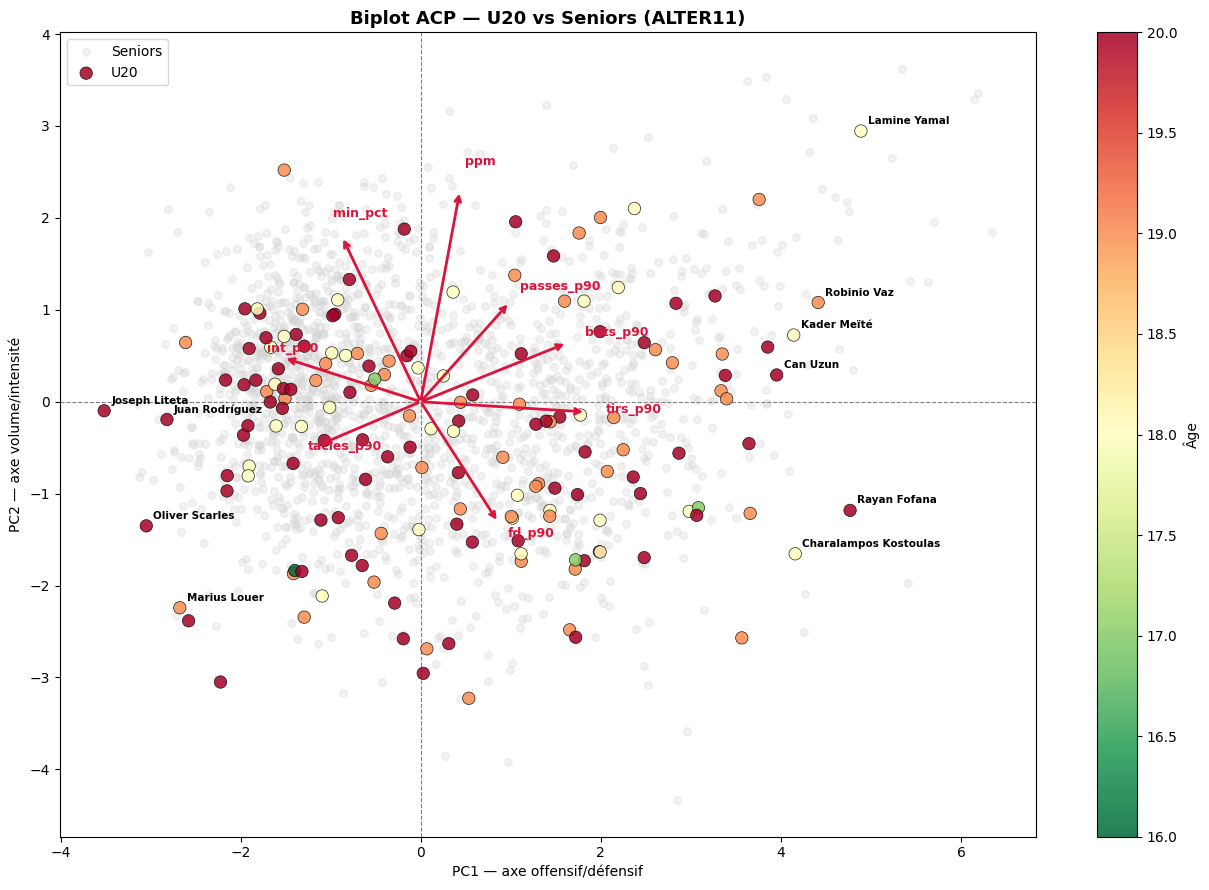

Sauvegardé ✅


In [55]:
# ── CELLULE 3 : Biplot U20 en surbrillance ────────────────
mask_u20 = ages <= 20

fig, ax = plt.subplots(figsize=(13, 9))

# Tous les joueurs en gris
ax.scatter(X_pca[~mask_u20, 0], X_pca[~mask_u20, 1],
           c='lightgrey', alpha=0.3, s=30, zorder=1, label='Seniors')

# U20 colorés par âge
sc = ax.scatter(X_pca[mask_u20, 0], X_pca[mask_u20, 1],
                c=ages[mask_u20], cmap='RdYlGn_r',
                alpha=0.85, s=80, zorder=3, 
                edgecolors='black', linewidths=0.5,
                vmin=16, vmax=20, label='U20')
plt.colorbar(sc, ax=ax, label='Âge')

# Flèches loadings
scale = 3.5
for i, feat in enumerate(features):
    ax.annotate("",
                xy=(pca.components_[0,i]*scale, pca.components_[1,i]*scale),
                xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
    ax.text(pca.components_[0,i]*scale*1.12,
            pca.components_[1,i]*scale*1.12,
            feat, fontsize=9, color='crimson', fontweight='bold')

# Annotations U20 extrêmes seulement
X_pca_u20 = X_pca[mask_u20]
noms_u20 = noms[mask_u20]
for idx in np.argsort(X_pca_u20[:, 0])[-6:]:
    ax.annotate(noms_u20[idx], (X_pca_u20[idx,0], X_pca_u20[idx,1]),
                fontsize=7.5, fontweight='bold',
                xytext=(5,5), textcoords='offset points')
for idx in np.argsort(X_pca_u20[:, 0])[:4]:
    ax.annotate(noms_u20[idx], (X_pca_u20[idx,0], X_pca_u20[idx,1]),
                fontsize=7.5, fontweight='bold',
                xytext=(5,5), textcoords='offset points')

ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'PC1 — axe offensif/défensif')
ax.set_ylabel(f'PC2 — axe volume/intensité')
ax.set_title('Biplot ACP — U20 vs Seniors (ALTER11)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\Jean Lavital\ALTER11\biplot_acp_u20.png", dpi=150)
plt.show()
print("Sauvegardé ✅")

=== Loadings PC3 ===
              PC3
tacles_p90  0.589
fd_p90      0.484
passes_p90  0.429
ppm         0.339
int_p90     0.250
tirs_p90    0.022
buts_p90   -0.107
min_pct    -0.213


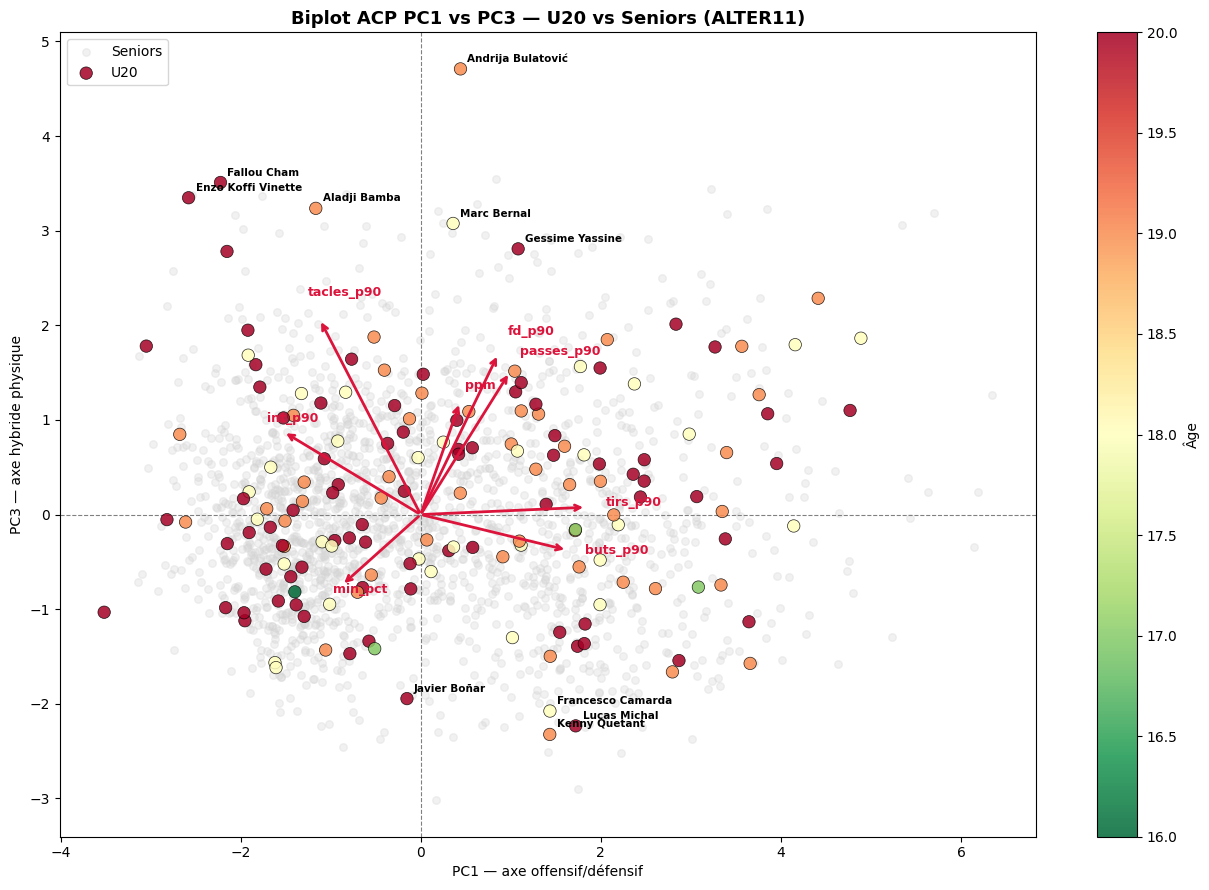

In [56]:
# ── CELLULE 4 : Analyse PC3 ───────────────────────────────

# Loadings PC3
print("=== Loadings PC3 ===")
print(df_loadings[['PC3']].sort_values('PC3', ascending=False).round(3))

# Biplot PC1 vs PC3
mask_u20 = ages <= 20
fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(X_pca[~mask_u20, 0], X_pca[~mask_u20, 2],
           c='lightgrey', alpha=0.3, s=30, zorder=1, label='Seniors')

sc = ax.scatter(X_pca[mask_u20, 0], X_pca[mask_u20, 2],
                c=ages[mask_u20], cmap='RdYlGn_r',
                alpha=0.85, s=80, zorder=3,
                edgecolors='black', linewidths=0.5,
                vmin=16, vmax=20, label='U20')
plt.colorbar(sc, ax=ax, label='Âge')

scale = 3.5
for i, feat in enumerate(features):
    ax.annotate("",
                xy=(pca.components_[0,i]*scale, pca.components_[2,i]*scale),
                xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
    ax.text(pca.components_[0,i]*scale*1.12,
            pca.components_[2,i]*scale*1.12,
            feat, fontsize=9, color='crimson', fontweight='bold')

# Annotations U20 extrêmes sur PC3
X_pca_u20 = X_pca[mask_u20]
noms_u20 = noms[mask_u20]
for idx in np.argsort(X_pca_u20[:, 2])[-6:]:
    ax.annotate(noms_u20[idx], (X_pca_u20[idx,0], X_pca_u20[idx,2]),
                fontsize=7.5, fontweight='bold',
                xytext=(5,5), textcoords='offset points')
for idx in np.argsort(X_pca_u20[:, 2])[:4]:
    ax.annotate(noms_u20[idx], (X_pca_u20[idx,0], X_pca_u20[idx,2]),
                fontsize=7.5, fontweight='bold',
                xytext=(5,5), textcoords='offset points')

ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel('PC1 — axe offensif/défensif')
ax.set_ylabel('PC3 — axe hybride physique')
ax.set_title('Biplot ACP PC1 vs PC3 — U20 vs Seniors (ALTER11)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(r"C:\Users\Jean Lavital\ALTER11\biplot_acp_pc1_pc3.png", dpi=150)
plt.show()

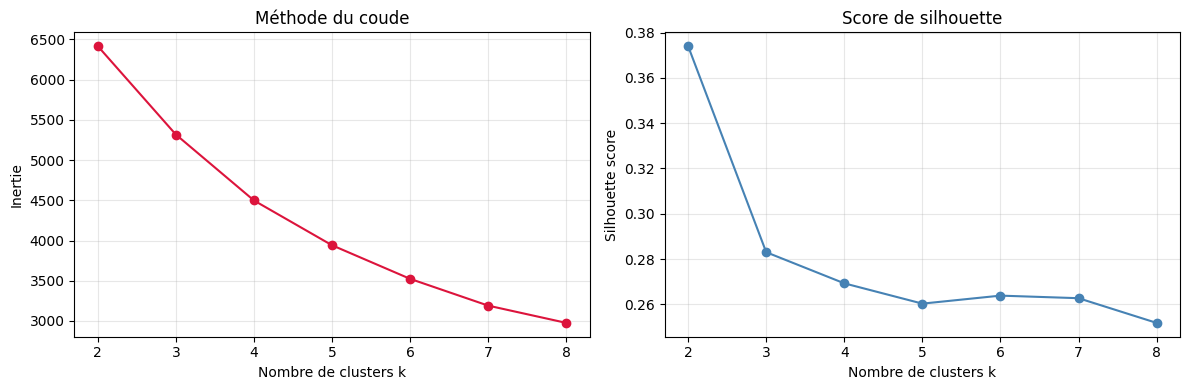


Silhouette scores :
  k=2 : 0.374
  k=3 : 0.283
  k=4 : 0.269
  k=5 : 0.260
  k=6 : 0.264
  k=7 : 0.263
  k=8 : 0.252


In [57]:
# ── CELLULE 5 : K-Means clustering sur 3 composantes ─────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── 1. Trouver le bon nombre de clusters (méthode du coude)
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca[:, :3])
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca[:, :3], labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'o-', color='crimson')
ax1.set_xlabel('Nombre de clusters k')
ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du coude')
ax1.grid(alpha=0.3)

ax2.plot(K_range, silhouettes, 'o-', color='steelblue')
ax2.set_xlabel('Nombre de clusters k')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Score de silhouette')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\Jean Lavital\ALTER11\kmeans_choix_k.png", dpi=150)
plt.show()

print("\nSilhouette scores :")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k} : {s:.3f}")

In [58]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

df_u20 = pd.read_sql("""
    SELECT p.player_id, p.player_name, p.age, t.team_name, p.position
    FROM dim_player p
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.age <= 20
    ORDER BY p.player_name
""", conn)

conn.close()

print(f"{len(df_u20)} joueurs U20")
print(df_u20[['player_name', 'age', 'team_name', 'position']].head(10))
print(f"\nPositions actuelles : {df_u20['position'].unique()}")

353 joueurs U20
              player_name  age      team_name position
0  Abdelhamid Ait Boudlal   20         Rennes       DF
1        Abdoul Coulibaly   18  Werder Bremen       DF
2         Abdoul Ouattara   20     Strasbourg       MF
3        Abdulai Juma Bah   20           Nice       DF
4             Adam Boayar   20          Elche       MF
5             Adam Daghim   20      Wolfsburg       MF
6              Adam Kölle   20     Heidenheim       DF
7            Adil Hamdani   17           Lyon       MF
8      Agustín Albarracín   20       Cagliari       FW
9            Aladji Bamba   19         Monaco       MF

Positions actuelles : ['DF' 'MF' 'FW' 'GK']


In [59]:
import requests
from bs4 import BeautifulSoup

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

test_url = "https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query=Lamine+Yamal"
r = requests.get(test_url, headers=headers)
print(f"Status : {r.status_code}")
print(f"Taille réponse : {len(r.text)} caractères")

Status : 200
Taille réponse : 86571 caractères


In [60]:
from bs4 import BeautifulSoup
import time

def search_transfermarkt(player_name, team_name, headers):
    query = player_name.replace(' ', '+')
    url = f"https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query={query}"
    
    try:
        r = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(r.text, 'lxml')
        
        # Table des résultats joueurs
        tables = soup.find_all('table', {'class': 'items'})
        
        if not tables:
            return None
            
        rows = tables[0].find_all('tr', {'class': ['odd', 'even']})
        
        results = []
        for row in rows:
            cells = row.find_all('td')
            if len(cells) < 4:
                continue
            try:
                name = row.find('td', {'class': 'hauptlink'}).get_text(strip=True)
                position = cells[2].get_text(strip=True)
                club = cells[4].get_text(strip=True) if len(cells) > 4 else ''
                results.append({
                    'tm_name': name,
                    'position_detail': position,
                    'tm_club': club
                })
            except:
                continue
                
        return results
        
    except Exception as e:
        print(f"Erreur : {e}")
        return None

# Test sur Lamine Yamal
results = search_transfermarkt("Lamine Yamal", "Barcelona", headers)
print(results)

[{'tm_name': 'Lamine Yamal', 'position_detail': 'Lamine Yamal', 'tm_club': 'RW'}]


In [61]:
# Debug — on regarde la structure brute
query = "Lamine+Yamal"
url = f"https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query={query}"
r = requests.get(url, headers=headers, timeout=10)
soup = BeautifulSoup(r.text, 'lxml')

tables = soup.find_all('table', {'class': 'items'})
print(f"Nombre de tables trouvées : {len(tables)}")

# On regarde la première table cellule par cellule
rows = tables[0].find_all('tr', {'class': ['odd', 'even']})
row = rows[0]  # Premier résultat

cells = row.find_all('td')
print(f"\nNombre de cellules : {len(cells)}")
for i, cell in enumerate(cells):
    print(f"  Cell {i} : '{cell.get_text(strip=True)}'")

Nombre de tables trouvées : 1

Nombre de cellules : 10
  Cell 0 : 'Lamine YamalFC Barcelona'
  Cell 1 : ''
  Cell 2 : 'Lamine Yamal'
  Cell 3 : 'FC Barcelona'
  Cell 4 : 'RW'
  Cell 5 : ''
  Cell 6 : '18'
  Cell 7 : ''
  Cell 8 : '€200.00m'
  Cell 9 : 'Gestifute'


In [62]:
from rapidfuzz import fuzz
import time

def search_transfermarkt(player_name, team_name, headers):
    query = player_name.replace(' ', '+')
    url = f"https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query={query}"
    
    try:
        r = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(r.text, 'lxml')
        tables = soup.find_all('table', {'class': 'items'})
        if not tables:
            return None
            
        rows = tables[0].find_all('tr', {'class': ['odd', 'even']})
        results = []
        for row in rows:
            cells = row.find_all('td')
            if len(cells) < 9:
                continue
            try:
                results.append({
                    'tm_name':          cells[2].get_text(strip=True),
                    'tm_club':          cells[3].get_text(strip=True),
                    'position_detail':  cells[4].get_text(strip=True),
                    'age':              cells[6].get_text(strip=True),
                    'market_value':     cells[8].get_text(strip=True),
                })
            except:
                continue
        return results
    except Exception as e:
        print(f"Erreur {player_name}: {e}")
        return None


def best_match(player_name, team_name, results):
    """Retourne le meilleur match avec score de confiance."""
    if not results:
        return None, 0
    
    best, best_score = None, 0
    for r in results:
        # Score nom + bonus club
        score_name = fuzz.token_sort_ratio(player_name.lower(), r['tm_name'].lower())
        score_club = fuzz.partial_ratio(team_name.lower(), r['tm_club'].lower())
        score_total = score_name * 0.7 + score_club * 0.3
        
        if score_total > best_score:
            best_score = score_total
            best = r
    return best, round(best_score, 1)


# ── Test sur 5 joueurs ────────────────────────────────────
test_players = df_u20[['player_name', 'team_name']].head(5).values

for player, team in test_players:
    results = search_transfermarkt(player, team, headers)
    match, score = best_match(player, team, results)
    if match:
        print(f"✅ {player} ({team})")
        print(f"   → {match['tm_name']} | {match['tm_club']} | {match['position_detail']} | score={score}")
    else:
        print(f"❌ {player} — aucun résultat")
    time.sleep(1.5)  # Respecter Transfermarkt

✅ Abdelhamid Ait Boudlal (Rennes)
   → Abdelhamid Ait Boudlal | Stade Rennais FC | CB | score=90.0
✅ Abdoul Coulibaly (Werder Bremen)
   → Abdoul Coulibaly | AS Bamako | CB | score=81.2
✅ Abdoul Ouattara (Strasbourg)
   → Abdoul Ouattara | RC Strasbourg Alsace | RB | score=100.0
✅ Abdulai Juma Bah (Nice)
   → Juma Bah | OGC Nice | CB | score=76.7
✅ Adam Boayar (Elche)
   → Adam Boayar | Elche CF | SS | score=100.0


In [63]:
# ── SCRAPING COMPLET 353 joueurs ─────────────────────────
results_list = []
errors = []

for i, row in df_u20.iterrows():
    player = row['player_name']
    team = row['team_name']
    
    results = search_transfermarkt(player, team, headers)
    match, score = best_match(player, team, results)
    
    if match:
        results_list.append({
            'player_name':      player,
            'team_name':        team,
            'tm_name':          match['tm_name'],
            'tm_club':          match['tm_club'],
            'position_detail':  match['position_detail'],
            'market_value':     match['market_value'],
            'match_score':      score,
            'flag':             '⚠️' if score < 85 else '✅'
        })
    else:
        errors.append(player)
        results_list.append({
            'player_name':      player,
            'team_name':        team,
            'tm_name':          None,
            'tm_club':          None,
            'position_detail':  None,
            'market_value':     None,
            'match_score':      0,
            'flag':             '❌'
        })
    
    time.sleep(1.5)
    
    # Progress toutes les 50 requêtes
    if (len(results_list)) % 50 == 0:
        print(f"  {len(results_list)}/353 traités...")

df_tm = pd.DataFrame(results_list)
df_tm.to_csv(r"C:\Users\Jean Lavital\ALTER11\transfermarkt_positions.csv", index=False)

print(f"\n✅ Terminé")
print(f"  Matchs fiables (≥85)  : {(df_tm['match_score'] >= 85).sum()}")
print(f"  À vérifier (<85)      : {(df_tm['match_score'].between(1, 84)).sum()}")
print(f"  Aucun résultat        : {(df_tm['match_score'] == 0).sum()}")
print(f"\nPositions trouvées :\n{df_tm['position_detail'].value_counts().head(15)}")

  50/353 traités...
  100/353 traités...
  150/353 traités...
  200/353 traités...
  250/353 traités...
  300/353 traités...
  350/353 traités...

✅ Terminé
  Matchs fiables (≥85)  : 299
  À vérifier (<85)      : 47
  Aucun résultat        : 4

Positions trouvées :
position_detail
CF          54
CB          52
CM          49
RW          49
AM          37
LW          36
DM          21
LB          19
RB          18
GK           6
SS           3
Attack       2
LM           2
Defender     1
Name: count, dtype: int64


In [64]:
df_check = df_tm[df_tm['match_score'] < 85][
    ['player_name', 'team_name', 'tm_name', 'tm_club', 'position_detail', 'match_score']
].sort_values('match_score')

print(f"{len(df_check)} joueurs à vérifier\n")
print(df_check.to_string())

df_check.to_csv(r"C:\Users\Jean Lavital\ALTER11\a_verifier.csv", index=False)
print("\nCSV sauvegardé ✅")

54 joueurs à vérifier

              player_name          team_name                   tm_name                   tm_club position_detail  match_score
39            Bara Ndiaye      Bayern Munich                      None                      None            None          0.0
59            Cheveyo Muy              Milan                      None                      None            None          0.0
86      Eli Junior Kroupi        Bournemouth                      None                      None            None          0.0
223      Mathys Silestrie             Rennes                      None                      None            None          0.0
305                 Souza  Tottenham Hotspur             Douglas Costa             Chievo Verona              RW         42.5
13     Alexander Legendre             Rennes   Elías Legendre Quiñónez          Stade Rennais FC              RW         57.6
36      Bahereba Guirassy             Nantes            Herba Guirassy                 FC Nante

In [65]:
# Faux positifs confirmés à exclure
faux_positifs = ['Souza', 'Sérigné Diop']

# Corrections manuelles
manual = {
    'Bara Ndiaye':        'CM',
    'Cheveyo Muy':        'RW',
    'Eli Junior Kroupi':  'CF',
    'Mathys Silestrie':   'GK',  # sera exclu
}

# Nettoyage
df_tm_clean = df_tm[~df_tm['player_name'].isin(faux_positifs)].copy()

for player, pos in manual.items():
    df_tm_clean.loc[df_tm_clean['player_name'] == player, 'position_detail'] = pos

# Merge
df_enriched = df_u20.merge(
    df_tm_clean[['player_name', 'position_detail', 'market_value', 'match_score']],
    on='player_name',
    how='left'
)

# Nettoyage positions
df_enriched['position_detail'] = df_enriched['position_detail'].replace({
    'SS': 'CF',
    'Attack': 'CF',
    'Defender': 'CB'
})

# Exclure GK
df_enriched = df_enriched[df_enriched['position_detail'] != 'GK']

print(f"Joueurs enrichis : {len(df_enriched)}")
print(f"\nPositions finales :\n{df_enriched['position_detail'].value_counts()}")
print(f"\nCouverture : {df_enriched['position_detail'].notna().sum()}/{len(df_enriched)}")

Joueurs enrichis : 346

Positions finales :
position_detail
CF    59
CB    53
CM    50
RW    49
AM    37
LW    36
DM    21
LB    19
RB    18
LM     2
Name: count, dtype: int64

Couverture : 344/346


In [66]:
# ── Sauvegarde dans la DB ─────────────────────────────────
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
cursor = conn.cursor()

# Ajouter les colonnes si elles n'existent pas
try:
    cursor.execute("ALTER TABLE dim_player ADD COLUMN position_detail TEXT")
    print("Colonne position_detail ajoutée ✅")
except:
    print("Colonne position_detail existe déjà")

try:
    cursor.execute("ALTER TABLE dim_player ADD COLUMN market_value TEXT")
    print("Colonne market_value ajoutée ✅")
except:
    print("Colonne market_value existe déjà")

# Update ligne par ligne
updated = 0
for _, row in df_enriched.iterrows():
    if pd.notna(row['position_detail']):
        cursor.execute("""
            UPDATE dim_player 
            SET position_detail = ?, market_value = ?
            WHERE player_name = ?
        """, (row['position_detail'], row['market_value'], row['player_name']))
        updated += cursor.rowcount

conn.commit()
conn.close()

print(f"\n{updated} joueurs mis à jour dans dim_player ✅")

# Vérification
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
check = pd.read_sql("""
    SELECT position_detail, COUNT(*) as n
    FROM dim_player 
    WHERE position_detail IS NOT NULL
    GROUP BY position_detail
    ORDER BY n DESC
""", conn)
conn.close()
print(f"\nVérification DB :\n{check.to_string()}")

Colonne position_detail ajoutée ✅
Colonne market_value ajoutée ✅



344 joueurs mis à jour dans dim_player ✅

Vérification DB :
  position_detail   n
0              CF  59
1              CB  53
2              CM  50
3              RW  49
4              AM  37
5              LW  36
6              DM  21
7              LB  19
8              RB  18
9              LM   2


In [67]:
# ── CELLULE 6 : Clustering par groupe de postes ───────────
from sklearn.cluster import KMeans

# Récupérer les données ACP + positions
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
df_cluster = pd.read_sql("""
    SELECT
        p.player_name, p.age, p.position_detail, t.team_name,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.points_per_match, 2)                           AS ppm,
        p.market_value
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.age <= 20
      AND f.minutes >= 200
      AND p.position_detail IS NOT NULL
      AND p.position_detail != 'GK'
""", conn)
conn.close()

print(f"Dataset clustering : {len(df_cluster)} joueurs")
print(df_cluster['position_detail'].value_counts())

Dataset clustering : 163 joueurs
position_detail
CB    31
CM    26
CF    23
RW    21
LW    16
AM    16
LB    12
RB    10
DM     8
Name: count, dtype: int64


In [68]:
# ── CELLULE 7 : K-Means par groupe de postes ─────────────

features = ['buts_p90', 'passes_p90', 'tirs_p90', 
            'tacles_p90', 'int_p90', 'fd_p90', 
            'min_pct', 'ppm']

# Groupes
groupes = {
    'Défenseurs': ['CB', 'LB', 'RB'],
    'Milieux':    ['CM', 'DM', 'AM', 'LM'],
    'Attaquants': ['CF', 'RW', 'LW']
}

labels_cluster = {
    'Défenseurs': ['Défenseurs A', 'Défenseurs B', 'Défenseurs C'],
    'Milieux':    ['Milieux A', 'Milieux B', 'Milieux C'],
    'Attaquants': ['Attaquants A', 'Attaquants B', 'Attaquants C']
}

df_cluster['cluster_label'] = None
df_cluster['groupe'] = None

scaler_cluster = StandardScaler()

for groupe, postes in groupes.items():
    mask = df_cluster['position_detail'].isin(postes)
    df_g = df_cluster[mask].dropna(subset=features)
    
    if len(df_g) < 6:
        continue
    
    X_g = scaler_cluster.fit_transform(df_g[features])
    
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = km.fit_predict(X_g)
    
    # Assigner les labels
    df_cluster.loc[df_g.index, 'groupe'] = groupe
    
    # Nommer les clusters par leur profil dominant
    for i, label in enumerate(labels_cluster[groupe]):
        idx = df_g.index[clusters == i]
        df_cluster.loc[idx, 'cluster_label'] = label
    
    print(f"\n=== {groupe} ({len(df_g)} joueurs) ===")
    for label in labels_cluster[groupe]:
        joueurs = df_cluster[df_cluster['cluster_label'] == label]['player_name'].tolist()
        print(f"\n  {label} ({len(joueurs)}) :")
        print(f"  {', '.join(joueurs[:8])}{'...' if len(joueurs) > 8 else ''}")
    
    # Stats moyennes par cluster
    print(f"\n  Moyennes par cluster :")
    print(df_cluster[mask].groupby('cluster_label')[features].mean().round(2).to_string())


=== Défenseurs (53 joueurs) ===

  Défenseurs A (11) :
  Honest Ahanor, Jan Bürger, Fallou Cham, Niccolò Fortini, Enzo Koffi Vinette, Myles Lewis-Skelly, Mahamadou Nagida, Buba Sangaré...

  Défenseurs B (40) :
  Joshua Acheampong, Abdelhamid Ait Boudlal, Noahkai Banks, Davide Bartesaghi, Javier Boñar, Sascha Britschgi, Jaydee Canvot, Nidal Celik...

  Défenseurs C (2) :
  Marc Domenech, Héctor Fort

  Moyennes par cluster :
               buts_p90  passes_p90  tirs_p90  tacles_p90  int_p90  fd_p90  min_pct   ppm
cluster_label                                                                            
Défenseurs A       0.00        0.00      0.92        1.83     1.29    1.85    43.61  1.37
Défenseurs B       0.06        0.01      0.48        1.14     0.93    0.53    74.46  1.34
Défenseurs C       0.11        0.42      1.82        0.74     0.55    0.74    37.70  1.16

=== Milieux (50 joueurs) ===

  Milieux A (11) :
  Tom Bischof, Claudio Echeverri, Francesco Esposito, Lennart Karl, Me

In [69]:
# ── CELLULE 7 FINALE : K-Means avec labels football ───────

labels_cluster = {
    'Défenseurs': ['Stoppeur', 'Défenseur de ligne', 'Défenseur offensif'],
    'Milieux':    ['Milieu offensif', 'Milieu relayeur', 'Box-to-box'],
    'Attaquants': ['Ailier électrique', 'Renard des surfaces', 'Avant-centre de pointe']
}

groupes = {
    'Défenseurs': ['CB', 'LB', 'RB'],
    'Milieux':    ['CM', 'DM', 'AM', 'LM'],
    'Attaquants': ['CF', 'RW', 'LW']
}

df_cluster['cluster_label'] = None
df_cluster['groupe'] = None

scaler_cluster = StandardScaler()

for groupe, postes in groupes.items():
    mask = df_cluster['position_detail'].isin(postes)
    df_g = df_cluster[mask].dropna(subset=features)

    if len(df_g) < 6:
        continue

    X_g = scaler_cluster.fit_transform(df_g[features])
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = km.fit_predict(X_g)

    df_cluster.loc[df_g.index, 'groupe'] = groupe

    # Assigner les labels selon les stats dominantes
    # On trie les clusters par PC1 moyen pour cohérence
    cluster_means = {}
    for i in range(3):
        idx = df_g.index[clusters == i]
        cluster_means[i] = df_cluster.loc[idx, 'tirs_p90'].mean()

    # Tri par tirs_p90 croissant → défensif, neutre, offensif
    sorted_clusters = sorted(cluster_means, key=cluster_means.get)

    for rank, cluster_id in enumerate(sorted_clusters):
        idx = df_g.index[clusters == cluster_id]
        df_cluster.loc[idx, 'cluster_label'] = labels_cluster[groupe][rank]

    print(f"\n=== {groupe} ===")
    for label in labels_cluster[groupe]:
        joueurs = df_cluster[df_cluster['cluster_label'] == label]['player_name'].tolist()
        print(f"\n  {label} ({len(joueurs)}) :")
        print(f"  {', '.join(joueurs[:8])}{'...' if len(joueurs) > 8 else ''}")

    print(f"\n  Stats moyennes :")
    print(df_cluster[mask].groupby('cluster_label')[
        ['buts_p90','tirs_p90','tacles_p90','int_p90','min_pct','ppm']
    ].mean().round(2).to_string())

# Sauvegarde
df_cluster.to_csv(r"C:\Users\Jean Lavital\ALTER11\clusters_u20.csv", index=False)
print("\n\nCSV sauvegardé ✅")
print(f"\nRépartition finale :\n{df_cluster['cluster_label'].value_counts()}")


=== Défenseurs ===

  Stoppeur (40) :
  Joshua Acheampong, Abdelhamid Ait Boudlal, Noahkai Banks, Davide Bartesaghi, Javier Boñar, Sascha Britschgi, Jaydee Canvot, Nidal Celik...

  Défenseur de ligne (11) :
  Honest Ahanor, Jan Bürger, Fallou Cham, Niccolò Fortini, Enzo Koffi Vinette, Myles Lewis-Skelly, Mahamadou Nagida, Buba Sangaré...

  Défenseur offensif (2) :
  Marc Domenech, Héctor Fort

  Stats moyennes :
                    buts_p90  tirs_p90  tacles_p90  int_p90  min_pct   ppm
cluster_label                                                             
Défenseur de ligne      0.00      0.92        1.83     1.29    43.61  1.37
Défenseur offensif      0.11      1.82        0.74     0.55    37.70  1.16
Stoppeur                0.06      0.48        1.14     0.93    74.46  1.34

=== Milieux ===

  Milieu offensif (13) :
  Mathis Amougou, Harrison Armstrong, Aladji Bamba, Jobe Bellingham, Marc Bernal, Ayyoub Bouaddi, Andrija Bulatović, Marius Courcoul...

  Milieu relayeur (26) :
 

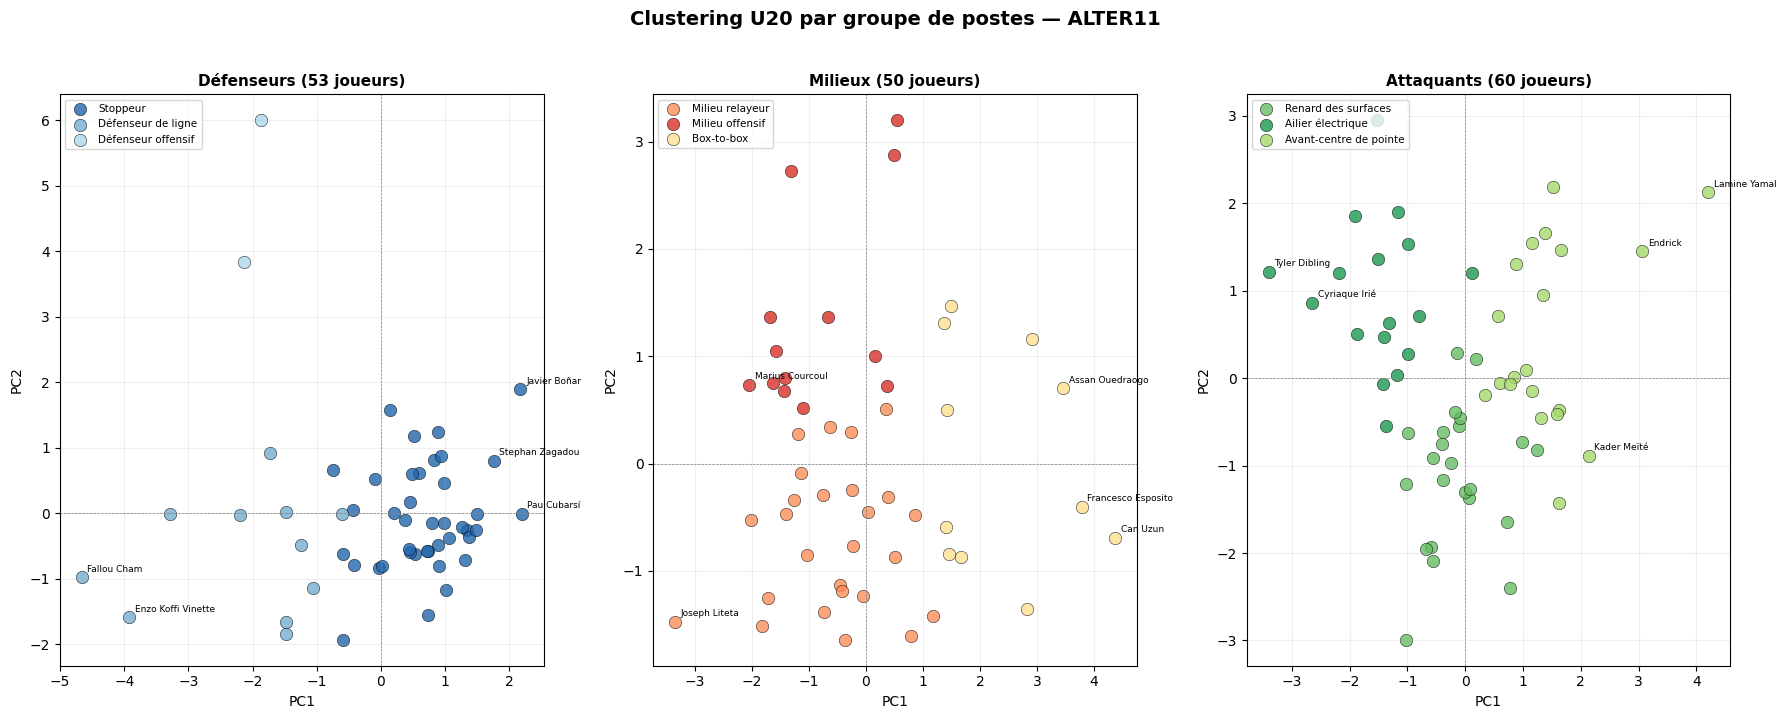

Sauvegardé ✅


In [70]:
# ── CELLULE 8 : Visualisation clusters ───────────────────
from matplotlib.patches import Patch

couleurs = {
    'Stoppeur':               '#2166ac',
    'Défenseur de ligne':     '#74add1',
    'Défenseur offensif':     '#abd9e9',
    'Milieu offensif':        '#d73027',
    'Milieu relayeur':        '#fc8d59',
    'Box-to-box':             '#fee090',
    'Ailier électrique':      '#1a9850',
    'Renard des surfaces':    '#66bd63',
    'Avant-centre de pointe': '#a6d96a',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
groupes_list = ['Défenseurs', 'Milieux', 'Attaquants']

for ax, groupe in zip(axes, groupes_list):
    mask = df_cluster['groupe'] == groupe
    df_g = df_cluster[mask].dropna(subset=['cluster_label'])

    # Recalculer ACP sur ce groupe
    X_g = scaler_cluster.fit_transform(df_g[features].fillna(0))
    pca_g = PCA(n_components=2)
    coords = pca_g.fit_transform(X_g)

    for label in df_g['cluster_label'].unique():
        idx = df_g['cluster_label'] == label
        ax.scatter(coords[idx.values, 0], coords[idx.values, 1],
                   c=couleurs.get(label, 'grey'),
                   s=80, alpha=0.8, label=label,
                   edgecolors='black', linewidths=0.4)

    # Annotations des outliers
    pc1_scores = coords[:, 0]
    for i in np.argsort(pc1_scores)[-3:]:
        ax.annotate(df_g.iloc[i]['player_name'],
                    (coords[i, 0], coords[i, 1]),
                    fontsize=6.5, xytext=(4, 4),
                    textcoords='offset points')
    for i in np.argsort(pc1_scores)[:2]:
        ax.annotate(df_g.iloc[i]['player_name'],
                    (coords[i, 0], coords[i, 1]),
                    fontsize=6.5, xytext=(4, 4),
                    textcoords='offset points')

    ax.set_title(f'{groupe} ({mask.sum()} joueurs)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7.5, loc='upper left')
    ax.grid(alpha=0.2)
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.axvline(0, color='grey', lw=0.5, ls='--')

plt.suptitle('Clustering U20 par groupe de postes — ALTER11',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\Jean Lavital\ALTER11\clustering_u20.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé ✅")

In [71]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

# Voir toutes les colonnes de fact_stats
cursor = conn.cursor()
cursor.execute("PRAGMA table_info(fact_stats)")
cols = cursor.fetchall()
conn.close()

print("Colonnes fact_stats :")
for col in cols:
    print(f"  {col[1]}")

Colonnes fact_stats :
  stat_id
  player_id
  matches_played
  minutes
  nineties
  goals
  assists
  shots
  shots_on_target
  interceptions
  tackles_won
  yellow_cards
  red_cards
  fouls_committed
  fouls_drawn
  min_per_match
  plus_minus
  points_per_match
  crosses
  min_pct


In [72]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import io
import time

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

def scrape_fbref_table(url):
    r = requests.get(url, headers=headers, timeout=15)
    soup = BeautifulSoup(r.text, 'lxml')
    
    # FBref met les tables dans des commentaires HTML parfois
    table = soup.find('table')
    if table is None:
        # Chercher dans les commentaires
        import re
        comments = soup.find_all(string=lambda text: isinstance(text, str) and '<table' in text)
        for comment in comments:
            soup2 = BeautifulSoup(comment, 'lxml')
            table = soup2.find('table')
            if table:
                break
    
    if table is None:
        print(f"Table non trouvée : {url}")
        return None
        
    df = pd.read_html(io.StringIO(str(table)))[0]
    return df

# Test Premier League Misc
url_test = "https://fbref.com/en/comps/9/misc/Premier-League-Stats"
df_test = scrape_fbref_table(url_test)

if df_test is not None:
    print(f"Shape : {df_test.shape}")
    print(df_test.columns.tolist())
    print(df_test.head(3))

Table non trouvée : https://fbref.com/en/comps/9/misc/Premier-League-Stats


In [73]:
import requests
from bs4 import BeautifulSoup, Comment
import pandas as pd
import io

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

def scrape_fbref_table(url, table_id):
    r = requests.get(url, headers=headers, timeout=15)
    soup = BeautifulSoup(r.text, 'lxml')
    
    # FBref cache les tables dans des commentaires HTML
    comments = soup.find_all(string=lambda text: isinstance(text, Comment))
    
    for comment in comments:
        if table_id in comment:
            soup2 = BeautifulSoup(comment, 'lxml')
            table = soup2.find('table', {'id': table_id})
            if table:
                df = pd.read_html(io.StringIO(str(table)))[0]
                return df
    
    print(f"Table '{table_id}' non trouvée dans {url}")
    return None

# Test — table misc Premier League
# L'id de la table misc sur FBref est 'stats_misc'
url_test = "https://fbref.com/en/comps/9/misc/Premier-League-Stats"
df_test = scrape_fbref_table(url_test, 'stats_misc')

if df_test is not None:
    print(f"Shape : {df_test.shape}")
    print(df_test.columns.tolist()[:10])
    print(df_test.head(3))

Table 'stats_misc' non trouvée dans https://fbref.com/en/comps/9/misc/Premier-League-Stats


In [74]:
r = requests.get(url_test, headers=headers, timeout=15)
soup = BeautifulSoup(r.text, 'lxml')

# Chercher dans les commentaires
comments = soup.find_all(string=lambda text: isinstance(text, Comment))

print(f"Nombre de commentaires : {len(comments)}")
for comment in comments:
    if 'table' in comment.lower() and 'id=' in comment.lower():
        soup2 = BeautifulSoup(comment, 'lxml')
        tables = soup2.find_all('table')
        for t in tables:
            print(f"  Table ID trouvé : '{t.get('id', 'SANS ID')}'")

Nombre de commentaires : 0


In [75]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup, Comment
import pandas as pd
import io
import time

def get_fbref_table(url, table_id):
    options = webdriver.ChromeOptions()
    options.add_argument('--headless')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    
    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )
    
    try:
        driver.get(url)
        time.sleep(3)  # Laisser le JS charger
        
        soup = BeautifulSoup(driver.page_source, 'lxml')
        
        # Chercher dans les commentaires
        comments = soup.find_all(string=lambda text: isinstance(text, Comment))
        print(f"Commentaires trouvés : {len(comments)}")
        
        for comment in comments:
            if table_id in comment:
                soup2 = BeautifulSoup(comment, 'lxml')
                table = soup2.find('table', {'id': table_id})
                if table:
                    return pd.read_html(io.StringIO(str(table)))[0]
        
        # Si pas dans commentaires, chercher directement
        table = soup.find('table', {'id': table_id})
        if table:
            return pd.read_html(io.StringIO(str(table)))[0]
            
        print(f"Table {table_id} non trouvée")
        return None
        
    finally:
        driver.quit()

# Test
df_test = get_fbref_table(
    "https://fbref.com/en/comps/9/misc/Premier-League-Stats",
    "stats_misc"
)

if df_test is not None:
    print(f"✅ Shape : {df_test.shape}")
    print(df_test.columns.tolist()[:10])

Commentaires trouvés : 0
Table stats_misc non trouvée


In [76]:
def debug_fbref(url):
    options = webdriver.ChromeOptions()
    options.add_argument('--headless')
    options.add_argument('--no-sandbox')
    
    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )
    
    try:
        driver.get(url)
        time.sleep(4)
        
        soup = BeautifulSoup(driver.page_source, 'lxml')
        
        # Toutes les tables visibles
        tables = soup.find_all('table')
        print(f"Tables visibles : {len(tables)}")
        for t in tables:
            print(f"  id='{t.get('id')}' class='{t.get('class')}'")
        
        # Tous les commentaires
        comments = soup.find_all(string=lambda text: isinstance(text, Comment))
        print(f"\nCommentaires : {len(comments)}")
        for c in comments[:5]:
            print(f"  {str(c)[:100]}")
            
    finally:
        driver.quit()

debug_fbref("https://fbref.com/en/comps/9/misc/Premier-League-Stats")

Tables visibles : 0

Commentaires : 0


In [77]:
import soccerdata as sd

# FBref reader
fbref = sd.FBref(leagues=["ENG-Premier League"], seasons=["2025-2026"])

# Récupérer les misc stats
df_misc = fbref.read_player_season_stats(stat_type="misc")
print(df_misc.shape)
print(df_misc.columns.tolist())
print(df_misc.head(3))

[05/25/26 11:56:31] INFO     No custom team name replacements found. You can configure these in       _config.py:92
                             C:\Users\Jean Lavital\soccerdata\config\teamname_replacements.json.                   

                    INFO     No custom league dict found. You can configure additional leagues in    _config.py:190
                             C:\Users\Jean Lavital\soccerdata\config\league_dict.json.                             

[05/25/26 11:56:32] INFO     Saving cached data to C:\Users\Jean Lavital\soccerdata\data\FBref       _common.py:250

[05/25/26 11:56:38] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:171: FutureWarning: The behavior of DataFrame                         
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

(547, 17)
[('nation', ''), ('pos', ''), ('age', ''), ('born', ''), ('90s', ''), ('Performance', 'CrdY'), ('Performance', 'CrdR'), ('Performance', '2CrdY'), ('Performance', 'Fls'), ('Performance', 'Fld'), ('Performance', 'Off'), ('Performance', 'Crs'), ('Performance', 'Int'), ('Performance', 'TklW'), ('Performance', 'PKwon'), ('Performance', 'PKcon'), ('Performance', 'OG')]
                                                     nation    pos     age  \
                                                                             
league             season team    player                                     
ENG-Premier League 2526   Arsenal Ben White             ENG     DF  28-224   
                                  Bukayo Saka           ENG  FW,MF  24-257   
                                  Christian Nørgaard    DEN     MF  32-071   

                                                      born   90s Performance  \
                                                                        Crd

In [78]:
import soccerdata as sd

# FBref reader
fbref = sd.FBref(leagues=["ENG-Premier League"], seasons=["2025-2026"])

# Récupérer les misc stats
df_misc = fbref.read_player_season_stats(stat_type="misc")
print(df_misc.shape)
print(df_misc.columns.tolist())
print(df_misc.head(3))

[05/25/26 11:56:39] INFO     Saving cached data to C:\Users\Jean Lavital\soccerdata\data\FBref       _common.py:250

[05/25/26 11:56:41] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:171: FutureWarning: The behavior of DataFrame                         
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

(547, 17)
[('nation', ''), ('pos', ''), ('age', ''), ('born', ''), ('90s', ''), ('Performance', 'CrdY'), ('Performance', 'CrdR'), ('Performance', '2CrdY'), ('Performance', 'Fls'), ('Performance', 'Fld'), ('Performance', 'Off'), ('Performance', 'Crs'), ('Performance', 'Int'), ('Performance', 'TklW'), ('Performance', 'PKwon'), ('Performance', 'PKcon'), ('Performance', 'OG')]
                                                     nation    pos     age  \
                                                                             
league             season team    player                                     
ENG-Premier League 2526   Arsenal Ben White             ENG     DF  28-224   
                                  Bukayo Saka           ENG  FW,MF  24-257   
                                  Christian Nørgaard    DEN     MF  32-071   

                                                      born   90s Performance  \
                                                                        Crd

In [79]:
# Stats disponibles dans soccerdata FBref
stat_types = [
    "standard", "shooting", "passing", "passing_types",
    "goal_shot_creation", "defense", "possession", "misc",
    "keeper", "keeper_adv"
]

fbref = sd.FBref(leagues=["ENG-Premier League"], seasons=["2025-2026"])

for stat in stat_types:
    try:
        df = fbref.read_player_season_stats(stat_type=stat)
        cols = [c[1] if isinstance(c, tuple) else c for c in df.columns.tolist()]
        print(f"✅ {stat} ({df.shape[1]} cols) : {cols[:8]}")
    except Exception as e:
        print(f"❌ {stat} : {e}")

[05/25/26 11:56:43] INFO     Saving cached data to C:\Users\Jean Lavital\soccerdata\data\FBref       _common.py:250

[05/25/26 11:56:47] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:171: FutureWarning: The behavior of DataFrame                         
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

✅ standard (21 cols) : ['', '', '', '', 'MP', 'Starts', 'Min', '90s']


[05/25/26 11:56:51] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:171: FutureWarning: The behavior of DataFrame                         
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

✅ shooting (15 cols) : ['', '', '', '', '', 'Gls', 'Sh', 'SoT']
❌ passing : Invalid argument: stat_type should be in ['standard', 'keeper', 'shooting', 'playing_time', 'misc']
❌ passing_types : Invalid argument: stat_type should be in ['standard', 'keeper', 'shooting', 'playing_time', 'misc']
❌ goal_shot_creation : Invalid argument: stat_type should be in ['standard', 'keeper', 'shooting', 'playing_time', 'misc']
❌ defense : Invalid argument: stat_type should be in ['standard', 'keeper', 'shooting', 'playing_time', 'misc']
❌ possession : Invalid argument: stat_type should be in ['standard', 'keeper', 'shooting', 'playing_time', 'misc']


[05/25/26 11:56:52] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:171: FutureWarning: The behavior of DataFrame                         
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

✅ misc (17 cols) : ['', '', '', '', '', 'CrdY', 'CrdR', '2CrdY']


[05/25/26 11:56:53] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:171: FutureWarning: The behavior of DataFrame                         
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

✅ keeper (23 cols) : ['', '', '', '', 'MP', 'Starts', 'Min', '90s']
❌ keeper_adv : Invalid argument: stat_type should be in ['standard', 'keeper', 'shooting', 'playing_time', 'misc']


In [ ]:
print(test.json())

{'data': {'attributes': {'credits': {'subscription': 0, 'payg': 1, 'enterprise': 0, 'total': 1}, 'api': {'free_calls': 8, 'sizes': 'all'}}}}


In [83]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

df_top50 = pd.read_sql("""
    SELECT 
        p.player_name, p.age, p.position_detail, t.team_name,
        f.minutes,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2) AS buts_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2) AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2) AS tacles_p90,
        ROUND(f.points_per_match, 2) AS ppm
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.age <= 20
      AND f.minutes >= 200
      AND p.position_detail IS NOT NULL
      AND p.position_detail != 'GK'
    ORDER BY f.points_per_match DESC
    LIMIT 50
""", conn)
conn.close()

print(f"{len(df_top50)} joueurs")
print(df_top50[['player_name', 'age', 'position_detail', 'team_name', 'minutes']].head(15))

50 joueurs
           player_name  age position_detail            team_name  minutes
0          Marc Bernal   18              DM            Barcelona      534
1          Tom Bischof   20              CM        Bayern Munich     1122
2         Lamine Yamal   18              RW            Barcelona     2262
3          Pau Cubarsí   19              CB            Barcelona     2552
4         Lennart Karl   18              AM        Bayern Munich     1206
5   Franco Mastantuono   18              RW          Real Madrid      855
6         Aladji Bamba   19              DM               Monaco      689
7   Myles Lewis-Skelly   19              LB              Arsenal      511
8   Francesco Esposito   20              CM                Inter     1454
9       Roony Bardghji   20              RW            Barcelona      559
10       Ibrahim Mbaye   18              RW  Paris Saint-Germain      958
11     Assan Ouedraogo   20              CM           RB Leipzig      790
12         Désiré Doué   20

In [82]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q_top50 = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties, f.matches_played,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.fouls_committed / NULLIF(f.nineties, 0), 2)    AS fls_p90,
        ROUND(f.crosses / NULLIF(f.nineties, 0), 2)            AS crs_p90,
        ROUND(f.points_per_match, 2)                           AS ppm,
        COALESCE(m.malus, 1.0)                                 AS coef_club,
        CASE 
            WHEN p.age <= 17 AND f.minutes >= 1000 THEN 3.0
            WHEN p.age <= 17                        THEN 2.0
            WHEN p.age <= 18 AND f.minutes >= 1500  THEN 2.5
            WHEN p.age <= 18                        THEN 1.7
            WHEN p.age <= 19 AND f.minutes >= 1800  THEN 2.0
            WHEN p.age <= 19                        THEN 1.4
            WHEN p.age =  20 AND f.minutes >= 2000  THEN 1.5
            WHEN p.age =  20                        THEN 1.1
            ELSE 0.8
        END AS bonus_age,
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    LEFT JOIN malus_clubs m ON t.team_name = m.team_name
    WHERE p.age <= 20
      AND p.position != 'GK'
      AND p.player_name != 'Robinio Vaz'
),
scored AS (
    SELECT *,
        CASE position
            WHEN 'FW' THEN
                CASE WHEN minutes < 300 THEN NULL ELSE
                ROUND(
                    (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
                  + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
            WHEN 'MF' THEN
                CASE WHEN minutes < 400 THEN NULL ELSE
                ROUND(
                    CASE WHEN (tacles_p90 + int_p90) > (buts_p90 + passes_p90) * 3 THEN
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    ELSE
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.10)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                      + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    END
                , 1) END
            WHEN 'DF' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.22)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.08)
                  + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                  + (MIN(crs_p90, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
        END AS score_brut
    FROM base
),
final AS (
    SELECT *,
        ROUND(score_brut * coef_fiab * coef_club, 1) AS alterscore
    FROM scored
    WHERE score_brut IS NOT NULL
)
SELECT player_name, age, position, team_name, minutes, alterscore
FROM final
ORDER BY alterscore DESC
LIMIT 50
"""

df_top50 = pd.read_sql(q_top50, conn)
conn.close()

print(f"{len(df_top50)} joueurs — Top 50 alterscore V7")
print(df_top50[['player_name', 'age', 'position', 'team_name', 'minutes', 'alterscore']].to_string(index=False))

50 joueurs — Top 50 alterscore V7
       player_name  age position           team_name  minutes  alterscore
 Eli Junior Kroupi   19       MF         Bournemouth     1447         5.5
      Said El Mala   19       FW                Köln     1787         5.5
   Bazoumana Touré   20       MF          Hoffenheim     2177         5.2
   Jesus Rodríguez   20       MF                Como     1585         5.1
   Jobe Bellingham   20       MF            Dortmund     1704         4.8
      Lamine Yamal   18       FW           Barcelona     2262         4.7
       Carlos Espí   20       FW             Levante     1079         4.6
          Can Uzun   20       MF Eintracht Frankfurt     1097         4.6
    Johan Manzambi   20       MF            Freiburg     1949         4.4
         Joel Roca   20       MF              Girona     1165         4.4
             Rayan   19       MF         Bournemouth      878         4.3
      Yan Diomandé   19       FW          RB Leipzig     2303         4.2
    

In [84]:
import time
from rapidfuzz import fuzz

def get_tm_photo_url(player_name, team_name, headers):
    query = player_name.replace(' ', '+')
    url = f"https://www.transfermarkt.com/schnellsuche/ergebnis/schnellsuche?query={query}"
    
    try:
        r = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(r.text, 'lxml')
        tables = soup.find_all('table', {'class': 'items'})
        if not tables:
            return None, None
            
        rows = tables[0].find_all('tr', {'class': ['odd', 'even']})
        
        best_match, best_score, best_img = None, 0, None
        for row in rows:
            cells = row.find_all('td')
            if len(cells) < 9:
                continue
            tm_name = cells[2].get_text(strip=True)
            tm_club = cells[3].get_text(strip=True)
            
            score_name = fuzz.token_sort_ratio(player_name.lower(), tm_name.lower())
            score_club = fuzz.partial_ratio(team_name.lower(), tm_club.lower())
            score_total = score_name * 0.7 + score_club * 0.3
            
            if score_total > best_score:
                best_score = score_total
                # Récupérer l'URL du profil joueur
                link = row.find('a', href=True)
                if link:
                    best_match = f"https://www.transfermarkt.com{link['href']}"
                # Récupérer l'image
                img = row.find('img')
                if img:
                    best_img = img.get('data-src') or img.get('src')
                    
        return best_img, best_score
        
    except Exception as e:
        return None, 0

# Test sur 3 joueurs
for _, row in df_top50.head(3).iterrows():
    img_url, score = get_tm_photo_url(row['player_name'], row['team_name'], headers)
    score_str = f"{score:.0f}" if score else "0"
    print(f"{row['player_name']} → {img_url} (score={score_str})")
    time.sleep(1.5)

Marc Bernal → https://img.a.transfermarkt.technology/portrait/small/1018920-1724052540.jpg?lm=1 (score=100)
Tom Bischof → https://img.a.transfermarkt.technology/portrait/small/822959-1758269709.jpg?lm=1 (score=100)
Lamine Yamal → https://img.a.transfermarkt.technology/portrait/small/937958-1773173768.jpg?lm=1 (score=100)


In [85]:
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
import os

API_KEY = "xDuaSn5aoVFWWokjTqkQ1eUb"
photos_dir = r"C:\Users\Jean Lavital\ALTER11\data\photos"
os.makedirs(photos_dir, exist_ok=True)

def generer_carte(player_name, team_name, age, position, alterscore, img_url):
    """Pipeline complet : photo TM → remove.bg → carte ALTER11"""
    
    chemin = f"{photos_dir}\\{player_name.replace(' ', '_')}.png"
    if os.path.exists(chemin):
        print(f"⏭️  {player_name} — déjà générée")
        return chemin
    
    if not img_url:
        print(f"❌ {player_name} — pas d'URL photo")
        return None
    
    # Télécharger la photo
    try:
        r_photo = requests.get(img_url, headers=headers, timeout=10)
        if r_photo.status_code != 200:
            print(f"❌ {player_name} — photo inaccessible")
            return None
    except:
        print(f"❌ {player_name} — erreur téléchargement")
        return None
    
    # Détourer via remove.bg
    r_bg = requests.post(
        "https://api.remove.bg/v1.0/removebg",
        files={"image_file": r_photo.content},
        data={"size": "auto"},
        headers={"X-Api-Key": API_KEY},
    )
    
    if r_bg.status_code != 200:
        print(f"❌ {player_name} — remove.bg erreur {r_bg.status_code}")
        return None
    
    img = Image.open(BytesIO(r_bg.content)).convert("RGBA")
    
    # ── Fond ALTER11 noir + grille bleue ──────────────────
    fond = Image.new("RGBA", (400, 520), (5, 5, 10, 255))
    draw = ImageDraw.Draw(fond)
    
    for x in range(0, 400, 20):
        draw.line([(x, 0), (x, 520)], fill=(0, 102, 255, 12), width=1)
    for y in range(0, 520, 20):
        draw.line([(0, y), (400, y)], fill=(0, 102, 255, 12), width=1)
    
    # Photo joueur
    img = img.resize((500, 375))
    x = (400 - img.width) // 2
    y = 30
    fond.paste(img, (x, y), img)
    
    # Fondu dégradé
    fondu = Image.new("RGBA", (400, 200), (0, 0, 0, 0))
    draw_f = ImageDraw.Draw(fondu)
    for i in range(200):
        alpha = int((i / 200) ** 0.6 * 255)
        draw_f.rectangle([(0, i), (400, i+1)], fill=(5, 5, 10, alpha))
    fond.paste(fondu, (0, 340), fondu)
    
    # Ligne bleue séparatrice
    draw = ImageDraw.Draw(fond)
    draw.rectangle([(0, 420), (400, 422)], fill=(0, 102, 255, 220))
    
    # Textes
    try:
        font_nom = ImageFont.truetype("arial.ttf", 22)
        font_info = ImageFont.truetype("arial.ttf", 16)
        font_score = ImageFont.truetype("arialbd.ttf", 28)
    except:
        font_nom = ImageFont.load_default()
        font_info = font_nom
        font_score = font_nom
    
    draw.text((20, 428), player_name.upper(), fill=(240, 240, 240, 255), font=font_nom)
    draw.text((20, 458), f"{team_name}  •  {position}  •  {age} ans", 
              fill=(160, 160, 160, 255), font=font_info)
    draw.text((320, 428), str(alterscore), fill=(0, 102, 255, 255), font=font_score)
    draw.text((320, 462), "ALTER", fill=(120, 120, 120, 255), font=font_info)
    
    fond.save(chemin)
    print(f"✅ {player_name}")
    return chemin

# ── Pipeline complet 50 joueurs ───────────────────────────
resultats = []
for _, row in df_top50.iterrows():
    img_url, score = get_tm_photo_url(row['player_name'], row['team_name'], headers)
    chemin = generer_carte(
        row['player_name'], row['team_name'], 
        row['age'], row['position'], row['alterscore'],
        img_url
    )
    resultats.append({'player_name': row['player_name'], 'chemin': chemin})
    time.sleep(2)

print(f"\n✅ {sum(1 for r in resultats if r['chemin'])} cartes générées")
print(f"❌ {sum(1 for r in resultats if not r['chemin'])} échecs")

KeyError: 'position'

In [86]:
from PIL import Image
import matplotlib.pyplot as plt

# Afficher Said El Mala
img = Image.open(f"{photos_dir}\\Noahkai_Banks.png")
plt.figure(figsize=(4, 5.2))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Jean Lavital\\ALTER11\\data\\photos\\Noahkai_Banks.png'

In [87]:
from rembg import remove as rembg_remove

def generer_carte_local(player_name, team_name, age, position, alterscore, img_url):
    chemin = f"{photos_dir}\\{player_name.replace(' ', '_')}.png"
    if os.path.exists(chemin):
        print(f"⏭️  {player_name} — déjà générée")
        return chemin
    
    if not img_url:
        print(f"❌ {player_name} — pas d'URL photo")
        return None
    
    try:
        r_photo = requests.get(img_url, headers=headers, timeout=10)
        if r_photo.status_code != 200:
            print(f"❌ {player_name} — photo inaccessible")
            return None
    except:
        print(f"❌ {player_name} — erreur téléchargement")
        return None
    
    # Détourer en local avec rembg
    img_detoure = Image.open(BytesIO(rembg_remove(r_photo.content))).convert("RGBA")
    
    # Fond ALTER11
    fond = Image.new("RGBA", (400, 520), (5, 5, 10, 255))
    draw = ImageDraw.Draw(fond)
    for x in range(0, 400, 20):
        draw.line([(x, 0), (x, 520)], fill=(0, 60, 150, 6), width=1)
    for y in range(0, 520, 20):
        draw.line([(0, y), (400, y)], fill=(0, 60, 150, 6), width=1)
    
    img_detoure = img_detoure.resize((500, 375))
    fond.paste(img_detoure, ((400 - 500) // 2, 30), img_detoure)
    
    fondu = Image.new("RGBA", (400, 200), (0, 0, 0, 0))
    draw_f = ImageDraw.Draw(fondu)
    for i in range(200):
        alpha = int((i / 200) ** 0.6 * 255)
        draw_f.rectangle([(0, i), (400, i+1)], fill=(5, 5, 10, alpha))
    fond.paste(fondu, (0, 340), fondu)
    
    draw = ImageDraw.Draw(fond)
    draw.rectangle([(0, 420), (400, 422)], fill=(0, 102, 255, 220))
    
    try:
        font_nom   = ImageFont.truetype("arial.ttf", 22)
        font_info  = ImageFont.truetype("arial.ttf", 16)
        font_score = ImageFont.truetype("arialbd.ttf", 28)
    except:
        font_nom = font_info = font_score = ImageFont.load_default()
    
    draw.text((20, 428), player_name.upper(), fill=(240, 240, 240, 255), font=font_nom)
    draw.text((20, 458), f"{team_name}  •  {position}  •  {age} ans",
              fill=(160, 160, 160, 255), font=font_info)
    draw.text((320, 428), str(alterscore), fill=(0, 102, 255, 255), font=font_score)
    draw.text((320, 462), "ALTER", fill=(120, 120, 120, 255), font=font_info)
    
    fond.save(chemin)
    print(f"✅ {player_name}")
    return chemin

# Test sur un joueur
img_url, score = get_tm_photo_url("Said El Mala", "Köln", headers)
generer_carte_local("Said El Mala", "Köln", 19, "FW", 5.5, img_url)

⏭️  Said El Mala — déjà générée


'C:\\Users\\Jean Lavital\\ALTER11\\data\\photos\\Said_El_Mala.png'

In [89]:
from rembg import remove as rembg_remove

def generer_carte_local(player_name, team_name, age, position, alterscore, img_url):
    chemin = f"{photos_dir}\\{player_name.replace(' ', '_')}.png"
    if os.path.exists(chemin):
        print(f"⏭️  {player_name} — déjà générée")
        return chemin
    if not img_url:
        print(f"❌ {player_name} — pas d'URL photo")
        return None
    try:
        r_photo = requests.get(img_url, headers=headers, timeout=10)
        if r_photo.status_code != 200:
            print(f"❌ {player_name} — photo inaccessible")
            return None
    except:
        print(f"❌ {player_name} — erreur téléchargement")
        return None

    img_detoure = Image.open(BytesIO(rembg_remove(r_photo.content))).convert("RGBA")

    fond = Image.new("RGBA", (400, 520), (5, 5, 10, 255))
    draw = ImageDraw.Draw(fond)
    for x in range(0, 400, 20):
        draw.line([(x, 0), (x, 520)], fill=(0, 102, 255, 12), width=1)
    for y in range(0, 520, 20):
        draw.line([(0, y), (400, y)], fill=(0, 102, 255, 12), width=1)

    img_detoure.thumbnail((180, 220))
    x = (400 - img_detoure.width) // 2
    y = 120
    fond.paste(img_detoure, (x, y), img_detoure)

    fondu = Image.new("RGBA", (400, 200), (0, 0, 0, 0))
    draw_f = ImageDraw.Draw(fondu)
    for i in range(200):
        alpha = int((i / 200) ** 0.6 * 255)
        draw_f.rectangle([(0, i), (400, i+1)], fill=(5, 5, 10, alpha))
    fond.paste(fondu, (0, 340), fondu)

    draw = ImageDraw.Draw(fond)
    draw.rectangle([(0, 420), (400, 422)], fill=(0, 102, 255, 220))

    try:
        font_nom   = ImageFont.truetype("arial.ttf", 22)
        font_info  = ImageFont.truetype("arial.ttf", 16)
        font_score = ImageFont.truetype("arialbd.ttf", 28)
    except:
        font_nom = font_info = font_score = ImageFont.load_default()

    draw.text((20, 428), player_name.upper(), fill=(240, 240, 240, 255), font=font_nom)
    draw.text((20, 458), f"{team_name}  •  {position}  •  {age} ans",
              fill=(160, 160, 160, 255), font=font_info)
    draw.text((320, 428), str(alterscore), fill=(0, 102, 255, 255), font=font_score)
    draw.text((320, 462), "ALTER", fill=(120, 120, 120, 255), font=font_info)

    fond.save(chemin)
    print(f"✅ {player_name}")
    return chemin

# Vider le dossier et tester
for f in os.listdir(photos_dir):
    os.remove(f"{photos_dir}\\{f}")

img_url, _ = get_tm_photo_url("Said El Mala", "Köln", headers)
generer_carte_local("Said El Mala", "Köln", 19, "FW", 5.5, img_url)

img = Image.open(f"{photos_dir}\\Said_El_Mala.png")
plt.figure(figsize=(4, 5.2))
plt.imshow(img)
plt.axis('off')
plt.show()

PermissionError: [WinError 5] Accès refusé: 'C:\\Users\\Jean Lavital\\ALTER11\\data\\photos\\alter11'

✅ Said El Mala


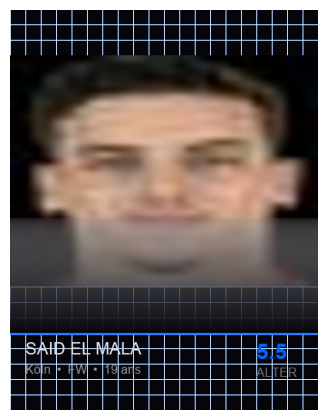

In [90]:
def generer_carte_local(player_name, team_name, age, position, alterscore, img_url):
    chemin = f"{photos_dir}\\{player_name.replace(' ', '_')}.png"
    if os.path.exists(chemin):
        print(f"⏭️  {player_name} — déjà générée")
        return chemin
    if not img_url:
        print(f"❌ {player_name} — pas d'URL photo")
        return None
    try:
        r_photo = requests.get(img_url, headers=headers, timeout=10)
        if r_photo.status_code != 200:
            print(f"❌ {player_name} — photo inaccessible")
            return None
    except:
        print(f"❌ {player_name} — erreur téléchargement")
        return None

    # Photo sans détourage
    img = Image.open(BytesIO(r_photo.content)).convert("RGBA")
    
    # Fond ALTER11
    fond = Image.new("RGBA", (400, 520), (5, 5, 10, 255))
    draw = ImageDraw.Draw(fond)
    for x in range(0, 400, 20):
        draw.line([(x, 0), (x, 520)], fill=(0, 102, 255, 12), width=1)
    for y in range(0, 520, 20):
        draw.line([(0, y), (400, y)], fill=(0, 102, 255, 12), width=1)

    # Redimensionner la photo pour remplir proprement
    img = img.resize((400, 300))
    fond.paste(img, (0, 60))

    # Fondu dégradé en bas de la photo
    fondu = Image.new("RGBA", (400, 150), (0, 0, 0, 0))
    draw_f = ImageDraw.Draw(fondu)
    for i in range(150):
        alpha = int((i / 150) ** 0.5 * 255)
        draw_f.rectangle([(0, i), (400, i+1)], fill=(5, 5, 10, alpha))
    fond.paste(fondu, (0, 270), fondu)

    draw = ImageDraw.Draw(fond)
    draw.rectangle([(0, 420), (400, 422)], fill=(0, 102, 255, 220))

    try:
        font_nom   = ImageFont.truetype("arial.ttf", 22)
        font_info  = ImageFont.truetype("arial.ttf", 16)
        font_score = ImageFont.truetype("arialbd.ttf", 28)
    except:
        font_nom = font_info = font_score = ImageFont.load_default()

    draw.text((20, 428), player_name.upper(), fill=(240, 240, 240, 255), font=font_nom)
    draw.text((20, 458), f"{team_name}  •  {position}  •  {age} ans",
              fill=(160, 160, 160, 255), font=font_info)
    draw.text((320, 428), str(alterscore), fill=(0, 102, 255, 255), font=font_score)
    draw.text((320, 462), "ALTER", fill=(120, 120, 120, 255), font=font_info)

    fond.save(chemin)
    print(f"✅ {player_name}")
    return chemin

# Test
for f in os.listdir(photos_dir):
    chemin_f = os.path.join(photos_dir, f)
    if os.path.isfile(chemin_f):
        os.remove(chemin_f)

img_url, _ = get_tm_photo_url("Said El Mala", "Köln", headers)
generer_carte_local("Said El Mala", "Köln", 19, "FW", 5.5, img_url)

img = Image.open(f"{photos_dir}\\Said_El_Mala.png")
plt.figure(figsize=(4, 5.2))
plt.imshow(img)
plt.axis('off')
plt.show()

In [91]:
# Premier League — format URL officiel
# ID joueur PL : récupérable via leur API

# Test sur un joueur PL connu — Jobe Bellingham
# D'abord on cherche son ID via l'API PL
url_pl = "https://fantasy.premierleague.com/api/bootstrap-static/"
r = requests.get(url_pl, headers=headers, timeout=15)
data = r.json()

# Chercher Bellingham dans les éléments
players_pl = data['elements']
for p in players_pl:
    if 'bellingham' in p['second_name'].lower():
        print(f"{p['first_name']} {p['second_name']} — ID: {p['id']} — photo: {p['photo']}")

In [92]:
r = requests.get(
    "https://fantasy.premierleague.com/api/bootstrap-static/", 
    headers=headers, 
    timeout=15
)
print(f"Status : {r.status_code}")
print(f"Taille : {len(r.text)}")

Status : 200
Taille : 2000382


In [93]:
data = r.json()
print(f"Clés disponibles : {list(data.keys())}")
print(f"Nombre de joueurs : {len(data['elements'])}")

# Chercher Bellingham
for p in data['elements']:
    if 'bellingham' in p['second_name'].lower() or 'bellingham' in p['first_name'].lower():
        print(f"\n{p['first_name']} {p['second_name']}")
        print(f"  ID : {p['id']}")
        print(f"  Photo : {p['photo']}")
        print(f"  Team : {p['team']}")

Clés disponibles : ['chips', 'events', 'game_settings', 'game_config', 'phases', 'teams', 'total_players', 'element_stats', 'element_types', 'elements']
Nombre de joueurs : 841


In [94]:
for p in data['elements']:
    if 'miley' in p['second_name'].lower():
        print(f"{p['first_name']} {p['second_name']}")
        print(f"  ID : {p['id']}")
        print(f"  Photo : {p['photo']}")

# Construire l'URL photo PL
# Format : https://resources.premierleague.com/premierleague/photos/players/250x250/p{id}.png
# Tester
id_test = None
for p in data['elements']:
    if 'miley' in p['second_name'].lower():
        id_test = p['id']
        photo_code = p['photo'].replace('.jpg', '')
        url_photo = f"https://resources.premierleague.com/premierleague/photos/players/250x250/p{photo_code}.png"
        print(f"\nURL photo : {url_photo}")
        
        # Tester l'accès
        r_img = requests.get(url_photo, headers=headers)
        print(f"Status photo : {r_img.status_code}")

Lewis Miley
  ID : 497
  Photo : 547719.jpg

URL photo : https://resources.premierleague.com/premierleague/photos/players/250x250/p547719.png
Status photo : 200


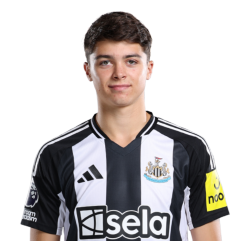

Taille : (500, 500)


In [95]:
r_img = requests.get(
    "https://resources.premierleague.com/premierleague/photos/players/250x250/p547719.png",
    headers=headers
)
img_test = Image.open(BytesIO(r_img.content))
plt.figure(figsize=(3, 3))
plt.imshow(img_test)
plt.axis('off')
plt.show()
print(f"Taille : {img_test.size}")

In [96]:
# Dictionnaire nom → URL photo pour tous les joueurs PL
pl_photos = {}
for p in data['elements']:
    nom = f"{p['first_name']} {p['second_name']}"
    photo_code = p['photo'].replace('.jpg', '')
    url = f"https://resources.premierleague.com/premierleague/photos/players/250x250/p{photo_code}.png"
    pl_photos[nom.lower()] = url

print(f"{len(pl_photos)} joueurs PL indexés")

# Matcher avec nos joueurs top50 PL
pl_top50 = df_top50[df_top50['team_name'].isin([
    'Bournemouth', 'Newcastle United', 'Wolves'
])]

print(f"\nJoueurs top50 en PL : {len(pl_top50)}")
for _, row in pl_top50.iterrows():
    nom = row['player_name'].lower()
    # Fuzzy match
    from rapidfuzz import process
    match = process.extractOne(nom, pl_photos.keys(), score_cutoff=70)
    if match:
        print(f"✅ {row['player_name']} → {match[0]} (score={match[1]:.0f})")
    else:
        print(f"❌ {row['player_name']} — pas trouvé")

841 joueurs PL indexés

Joueurs top50 en PL : 2
✅ Veljko Milosavljević → veljko milosavljevic (score=95)
✅ Rayan → rayan vitor simplício rocha (score=90)


In [97]:
def get_photo_url(player_name, team_name):
    """PL en priorité, TM en fallback"""
    
    # Clubs PL dans notre dataset
    clubs_pl = ['Bournemouth', 'Newcastle United', 'Wolves', 'Arsenal', 
                'Chelsea', 'Liverpool', 'Manchester City', 'Aston Villa',
                'Brighton', 'Tottenham Hotspur', 'West Ham United']
    
    if team_name in clubs_pl:
        # Chercher dans l'API PL
        match = process.extractOne(player_name.lower(), pl_photos.keys(), score_cutoff=70)
        if match:
            return pl_photos[match[0]], 'PL'
    
    # Fallback TM
    url, score = get_tm_photo_url(player_name, team_name, headers)
    return url, 'TM'

# Test sur les 4 joueurs PL
for _, row in pl_top50.iterrows():
    url, source = get_photo_url(row['player_name'], row['team_name'])
    print(f"{row['player_name']} → {source} | {url[:60] if url else 'None'}...")
    time.sleep(0.5)

Veljko Milosavljević → PL | https://resources.premierleague.com/premierleague/photos/pla...
Rayan → PL | https://resources.premierleague.com/premierleague/photos/pla...


✅ Lewis Miley (PL)


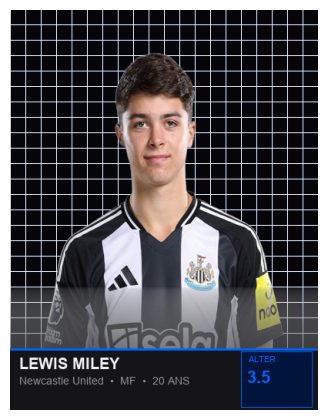

In [98]:
import os
photos_dir = r"C:\Users\Jean Lavital\ALTER11\data\photos"

def generer_carte_finale(player_name, team_name, age, position, alterscore):
    chemin = f"{photos_dir}\\{player_name.replace(' ', '_')}.png"
    if os.path.exists(chemin):
        print(f"⏭️  {player_name} — déjà générée")
        return chemin

    img_url, source = get_photo_url(player_name, team_name)
    
    if not img_url:
        print(f"❌ {player_name} — pas d'URL photo")
        return None
    
    try:
        r_photo = requests.get(img_url, headers=headers, timeout=10)
        if r_photo.status_code != 200:
            print(f"❌ {player_name} — photo inaccessible")
            return None
    except:
        print(f"❌ {player_name} — erreur téléchargement")
        return None

    if source == 'PL':
        img = Image.open(BytesIO(rembg_remove(r_photo.content))).convert("RGBA")
    else:
        img = Image.open(BytesIO(r_photo.content)).convert("RGBA")

    fond = Image.new("RGBA", (400, 520), (5, 5, 10, 255))
    draw = ImageDraw.Draw(fond)
    for x in range(0, 400, 20):
        draw.line([(x, 0), (x, 520)], fill=(0, 30, 80, 3), width=1)
    for y in range(0, 520, 20):
        draw.line([(0, y), (400, y)], fill=(0, 30, 80, 3), width=1)

    if source == 'PL':
        img = img.resize((345, 415))  # légèrement élargi
        x = (400 - img.width) // 2
        y = 55  # un poil plus bas
        fond.paste(img, (x, y), img)
        
        fondu = Image.new("RGBA", (400, 180), (0, 0, 0, 0))
        draw_f = ImageDraw.Draw(fondu)
        for i in range(180):
            alpha = int((i / 180) ** 0.5 * 255)
            draw_f.rectangle([(0, i), (400, i+1)], fill=(5, 5, 10, alpha))
        fond.paste(fondu, (0, 360), fondu)
    else:
        img = img.resize((400, 300))
        fond.paste(img, (0, 60))
        fondu = Image.new("RGBA", (400, 150), (0, 0, 0, 0))
        draw_f = ImageDraw.Draw(fondu)
        for i in range(150):
            alpha = int((i / 150) ** 0.5 * 255)
            draw_f.rectangle([(0, i), (400, i+1)], fill=(5, 5, 10, alpha))
        fond.paste(fondu, (0, 210), fondu)

    draw = ImageDraw.Draw(fond)
    draw.rectangle([(0, 440), (400, 520)], fill=(5, 5, 10, 240))
    draw.rectangle([(0, 440), (400, 442)], fill=(0, 102, 255, 255))

    try:
        font_nom   = ImageFont.truetype("arialbd.ttf", 20)
        font_info  = ImageFont.truetype("arial.ttf", 14)
        font_score = ImageFont.truetype("arialbd.ttf", 22)
        font_label = ImageFont.truetype("arial.ttf", 11)
    except:
        font_nom = font_info = font_score = font_label = ImageFont.load_default()

    draw.text((12, 448), player_name.upper(), fill=(240, 240, 240, 255), font=font_nom)
    draw.text((12, 474), f"{team_name}  •  {position}  •  {age} ANS",
              fill=(150, 150, 150, 255), font=font_info)

    draw.rectangle([(300, 444), (392, 516)], fill=(0, 20, 60, 255),
                   outline=(0, 102, 255, 255), width=1)
    draw.text((310, 448), "ALTER", fill=(0, 102, 255, 255), font=font_label)
    draw.text((308, 465), str(alterscore), fill=(0, 102, 255, 255), font=font_score)

    fond.save(chemin)
    print(f"✅ {player_name} ({source})")
    return chemin

# Vider et tester Lewis Miley
for f in os.listdir(photos_dir):
    chemin_f = os.path.join(photos_dir, f)
    if os.path.isfile(chemin_f):
        os.remove(chemin_f)

generer_carte_finale("Lewis Miley", "Newcastle United", 20, "MF", 3.5)

img = Image.open(f"{photos_dir}\\Lewis_Miley.png")
plt.figure(figsize=(4, 5.2))
plt.imshow(img)
plt.axis('off')
plt.show()

In [99]:
import requests

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

urls_test = {
    'Bundesliga': 'https://api.bundesliga.com/bundesliga/api/v2/players?season=2025',
    'Ligue 1':    'https://api.ligue1.fr/api/v1/players?season=2025-2026',
    'La Liga':    'https://apim.laliga.com/public-service/api/v1/players?limit=10&season_slug=laliga-ea-sports-2025-26',
    'Serie A':    'https://api.serie-a.it/rest/v1/players?season_id=2025'
}

for ligue, url in urls_test.items():
    try:
        r = requests.get(url, headers=headers, timeout=10)
        print(f"{ligue} : {r.status_code} — {len(r.text)} chars")
    except Exception as e:
        print(f"{ligue} : erreur — {e}")

Bundesliga : erreur — HTTPSConnectionPool(host='api.bundesliga.com', port=443): Max retries exceeded with url: /bundesliga/api/v2/players?season=2025 (Caused by NameResolutionError("HTTPSConnection(host='api.bundesliga.com', port=443): Failed to resolve 'api.bundesliga.com' ([Errno 11001] getaddrinfo failed)"))
Ligue 1 : erreur — HTTPSConnectionPool(host='api.ligue1.fr', port=443): Max retries exceeded with url: /api/v1/players?season=2025-2026 (Caused by NameResolutionError("HTTPSConnection(host='api.ligue1.fr', port=443): Failed to resolve 'api.ligue1.fr' ([Errno 11001] getaddrinfo failed)"))
La Liga : 401 — 152 chars
Serie A : erreur — HTTPSConnectionPool(host='api.serie-a.it', port=443): Max retries exceeded with url: /rest/v1/players?season_id=2025 (Caused by NameResolutionError("HTTPSConnection(host='api.serie-a.it', port=443): Failed to resolve 'api.serie-a.it' ([Errno 11001] getaddrinfo failed)"))


In [100]:
# Test photo Sofascore — Lamine Yamal (id: 1070078)
url = "https://api.sofascore.com/api/v1/player/1070078/image"
r = requests.get(url, headers=headers, timeout=10)
print(f"Status : {r.status_code}")
print(f"Content-Type : {r.headers.get('Content-Type')}")

if r.status_code == 200:
    from PIL import Image
    from io import BytesIO
    img = Image.open(BytesIO(r.content))
    print(f"Taille : {img.size}")
    import matplotlib.pyplot as plt
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

Status : 403
Content-Type : application/json


In [101]:
headers_sofascore = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'image/avif,image/webp,image/apng,image/svg+xml,image/*,*/*;q=0.8',
    'Accept-Language': 'fr-FR,fr;q=0.9,en-US;q=0.8',
    'Accept-Encoding': 'gzip, deflate, br',
    'Referer': 'https://www.sofascore.com/',
    'Origin': 'https://www.sofascore.com',
    'sec-ch-ua': '"Not_A Brand";v="8", "Chromium";v="120"',
    'sec-ch-ua-mobile': '?0',
    'sec-fetch-dest': 'image',
    'sec-fetch-mode': 'no-cors',
    'sec-fetch-site': 'same-site',
}

url = "https://api.sofascore.com/api/v1/player/1070078/image"
r = requests.get(url, headers=headers_sofascore, timeout=10)
print(f"Status : {r.status_code}")
print(f"Taille : {len(r.content)} bytes")

if r.status_code == 200:
    img = Image.open(BytesIO(r.content))
    print(f"Dimensions : {img.size}")
    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

Status : 403
Taille : 48 bytes


In [102]:
print(df_top50['team_name'].value_counts().head(15))

team_name
Barcelona              5
RB Leipzig             5
Paris Saint-Germain    5
Leverkusen             4
Real Madrid            3
Bayern Munich          2
Dortmund               2
Hoffenheim             2
Lens                   2
Lyon                   2
Bournemouth            2
Rennes                 2
Inter                  1
Monaco                 1
Arsenal                1
Name: count, dtype: int64


In [107]:
resultats = []
for _, row in df_top50.iterrows():
    chemin = generer_carte_finale(
        row['player_name'], row['team_name'],
        row['age'], row['position_detail'], row['ppm']
    )
    resultats.append({'player_name': row['player_name'], 'chemin': chemin})
    time.sleep(2)

print(f"\n✅ {sum(1 for r in resultats if r['chemin'])} cartes générées")
print(f"❌ {sum(1 for r in resultats if not r['chemin'])} échecs")

✅ Marc Bernal (TM)
✅ Tom Bischof (TM)
✅ Lamine Yamal (TM)
✅ Pau Cubarsí (TM)
✅ Lennart Karl (TM)
✅ Franco Mastantuono (TM)
✅ Aladji Bamba (TM)
✅ Myles Lewis-Skelly (PL)
✅ Francesco Esposito (TM)
✅ Roony Bardghji (TM)
✅ Ibrahim Mbaye (TM)
✅ Assan Ouedraogo (TM)
✅ Désiré Doué (TM)
✅ Khalis Merah (TM)
✅ Luca Reggiani (TM)
✅ Warren Zaïre-Emery (TM)
✅ Jobe Bellingham (TM)
✅ Senny Mayulu (TM)
✅ Andrija Bulatović (TM)
✅ Dro Fernández (TM)
✅ Montrell Culbreath (TM)
✅ Quentin Ndjantou Mbitcha (TM)
✅ Rayan Fofana (TM)
✅ Yan Diomandé (TM)
✅ Ayden Heaven (TM)
✅ Axel Tapé (TM)
✅ Finn Jeltsch (TM)
✅ Mahamadou Nagida (TM)
✅ Endrick (TM)
✅ Max Moerstedt (TM)
✅ Abdelhamid Ait Boudlal (TM)
✅ Rudy Matondo (TM)
✅ Tidiam Gomis (TM)
✅ Ethan Mbappé (TM)
✅ Jan Ziółkowski (TM)
✅ Davide Bartesaghi (TM)
❌ Veljko Milosavljević — photo inaccessible
✅ Thiago Pinar (TM)
✅ Robinio Vaz (TM)
❌ Rayan — photo inaccessible
✅ Kosta Nedeljković (TM)
✅ Jesus Rodríguez (TM)
✅ Christian Kofane (TM)
✅ El Chadaille Bitshiabu (TM

In [104]:
print(df_top50.columns.tolist())
print(df_top50.head(2))

['player_name', 'age', 'position_detail', 'team_name', 'minutes', 'buts_p90', 'tirs_p90', 'tacles_p90', 'ppm']
   player_name  age position_detail      team_name  minutes  buts_p90  \
0  Marc Bernal   18              DM      Barcelona      534      0.34   
1  Tom Bischof   20              CM  Bayern Munich     1122      0.16   

   tirs_p90  tacles_p90   ppm  
0      1.02        2.20  2.83  
1      2.16        1.04  2.63  


In [108]:
# Test photos officielles par ligue
tests = {
    # PSG — site officiel
    'PSG': 'https://www.psg.fr/api/players',
    # Barcelona
    'Barca': 'https://www.fcbarcelona.com/api/players',  
    # Bundesliga — DFL media
    'Bundesliga': 'https://www.bundesliga.com/api/v1/players',
    # Ligue 1 — DAZN
    'Ligue1': 'https://api.dazn.com/v1/sports/soccer/competitions/fr-ligue-1/players',
}

for nom, url in tests.items():
    try:
        r = requests.get(url, headers=headers, timeout=5)
        print(f"{nom} : {r.status_code} — {len(r.text)} chars")
    except Exception as e:
        print(f"{nom} : erreur")

PSG : 200 — 1148499 chars
Barca : 404 — 262796 chars
Bundesliga : 404 — 363994 chars
Ligue1 : erreur


In [109]:
# Explorer la réponse PSG
data_psg = r.json() if 'r' in dir() else requests.get('https://www.psg.fr/api/players', headers=headers).json()

print(type(data_psg))
if isinstance(data_psg, list):
    print(f"{len(data_psg)} entrées")
    print(data_psg[0])
elif isinstance(data_psg, dict):
    print(list(data_psg.keys())[:10])

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [110]:
# Test Ligue 1+
urls_l1 = [
    'https://api.ligue1.fr/api/v1/players',
    'https://www.ligue1.fr/api/players',
    'https://api.canal-ligue1.fr/v1/players',
]

for url in urls_l1:
    try:
        r2 = requests.get(url, headers=headers, timeout=5)
        print(f"{url} : {r2.status_code}")
    except:
        print(f"{url} : erreur")

https://api.ligue1.fr/api/v1/players : erreur
https://www.ligue1.fr/api/players : 404
https://api.canal-ligue1.fr/v1/players : erreur


In [1]:
import soccerdata as sd

ligues = [
    "ENG-Premier League",
    "ESP-La Liga", 
    "FRA-Ligue 1",
    "GER-Bundesliga",
    "ITA-Serie A"
]

fbref = sd.FBref(leagues=ligues, seasons=["2025-2026"])

print("Scraping standard stats...")
df_standard = fbref.read_player_season_stats(stat_type="standard")
print(f"Standard : {df_standard.shape}")

print("Scraping misc...")
df_misc = fbref.read_player_season_stats(stat_type="misc")
print(f"Misc : {df_misc.shape}")

print("Scraping shooting...")
df_shooting = fbref.read_player_season_stats(stat_type="shooting")
print(f"Shooting : {df_shooting.shape}")

print("\n✅ Terminé")

[07/05/26 14:44:18] INFO     No custom team name replacements found. You can configure these in       _config.py:92
                             C:\Users\Jean Lavital\soccerdata\config\teamname_replacements.json.                   

                    INFO     No custom league dict found. You can configure additional leagues in    _config.py:190
                             C:\Users\Jean Lavital\soccerdata\config\league_dict.json.                             

                    INFO     Saving cached data to C:\Users\Jean Lavital\soccerdata\data\FBref       _common.py:250



*** chromedriver to download = 149.0.7827.155 (Previous Version)

https://storage.googleapis.com/chrome-for-testing-public/149.0.7827.155/win64/chromedriver-win64.zip ...
Download Complete!

Extracting ['chromedriver.exe'] from chromedriver-win64.zip ...
Unzip Complete!

The file [uc_driver.exe] was saved to:
C:\Users\Jean Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\seleniumbase\drivers\
uc_driver.exe

Making [uc_driver.exe 149.0.7827.155] executable ...
[uc_driver.exe 149.0.7827.155] is now ready for use!


*** chromedriver to download = 149.0.7827.155 (Previous Version)

https://storage.googleapis.com/chrome-for-testing-public/149.0.7827.155/win64/chromedriver-win64.zip ...
Download Complete!

Extracting ['chromedriver.exe'] from chromedriver-win64.zip ...
Unzip Complete!

The file [chromedriver.exe] was saved to:
C:\Users\Jean Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\seleniumbase\drivers\
chromedriver.exe

Making [chromedriver.exe 149

[07/05/26 14:44:28] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:104: UserWarning: You are trying to scrape data for                   
                             all of the Big 5 European leagues. This can be done more efficiently                  
                             by setting leagues='Big 5 European Leagues Combined'.                                 
                               warnings.warn(                                                                      
                                                                                                                   

...

Standard : (2835, 21)
Scraping misc...


[07/05/26 14:46:18] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:171: FutureWarning: The behavior of DataFrame                         
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

Misc : (2835, 17)
Scraping shooting...


[07/05/26 14:47:19] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:171: FutureWarning: The behavior of DataFrame                         
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

Shooting : (2835, 15)

✅ Terminé


In [2]:
# Reset index pour avoir player + team + league comme colonnes
df_std = df_standard.reset_index()
df_misc_r = df_misc.reset_index()
df_shoot = df_shooting.reset_index()

print("Colonnes standard :")
print(df_std.columns.tolist())
print("\nColonnes misc :")
print(df_misc_r.columns.tolist())
print("\nColonnes shooting :")
print(df_shoot.columns.tolist())

Colonnes standard :
[('league', ''), ('season', ''), ('team', ''), ('player', ''), ('nation', ''), ('pos', ''), ('age', ''), ('born', ''), ('Playing Time', 'MP'), ('Playing Time', 'Starts'), ('Playing Time', 'Min'), ('Playing Time', '90s'), ('Performance', 'Gls'), ('Performance', 'Ast'), ('Performance', 'G+A'), ('Performance', 'G-PK'), ('Performance', 'PK'), ('Performance', 'PKatt'), ('Performance', 'CrdY'), ('Performance', 'CrdR'), ('Per 90 Minutes', 'Gls'), ('Per 90 Minutes', 'Ast'), ('Per 90 Minutes', 'G+A'), ('Per 90 Minutes', 'G-PK'), ('Per 90 Minutes', 'G+A-PK')]

Colonnes misc :
[('league', ''), ('season', ''), ('team', ''), ('player', ''), ('nation', ''), ('pos', ''), ('age', ''), ('born', ''), ('90s', ''), ('Performance', 'CrdY'), ('Performance', 'CrdR'), ('Performance', '2CrdY'), ('Performance', 'Fls'), ('Performance', 'Fld'), ('Performance', 'Off'), ('Performance', 'Crs'), ('Performance', 'Int'), ('Performance', 'TklW'), ('Performance', 'PKwon'), ('Performance', 'PKcon'), ('

In [3]:
import sqlite3
import pandas as pd

# ── Aplatir les colonnes multi-index ─────────────────────
def flatten_cols(df):
    df.columns = ['_'.join(filter(None, col)).strip() if isinstance(col, tuple) else col 
                  for col in df.columns]
    return df

df_std = flatten_cols(df_std)
df_misc_r = flatten_cols(df_misc_r)
df_shoot = flatten_cols(df_shoot)

# Clés de jointure
keys = ['league', 'season', 'team', 'player']

# Merge des 3 tables
df_merged = df_std.merge(
    df_misc_r[keys + [c for c in df_misc_r.columns if c not in df_std.columns]],
    on=keys, how='left'
).merge(
    df_shoot[keys + [c for c in df_shoot.columns if c not in df_std.columns and c not in df_misc_r.columns]],
    on=keys, how='left'
)

print(f"Shape merged : {df_merged.shape}")
print(f"Colonnes : {df_merged.columns.tolist()[:15]}")
print(df_merged[['player', 'team', 'league', 'Playing Time_Min', 'Performance_Gls']].head(5))

Shape merged : (2835, 46)
Colonnes : ['league', 'season', 'team', 'player', 'nation', 'pos', 'age', 'born', 'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_Min', 'Playing Time_90s', 'Performance_Gls', 'Performance_Ast', 'Performance_G+A']
               player     team              league  Playing Time_Min  \
0           Ben White  Arsenal  ENG-Premier League               702   
1         Bukayo Saka  Arsenal  ENG-Premier League              2222   
2  Christian Nørgaard  Arsenal  ENG-Premier League                61   
3  Cristhian Mosquera  Arsenal  ENG-Premier League               904   
4          David Raya  Arsenal  ENG-Premier League              3330   

   Performance_Gls  
0                0  
1                7  
2                0  
3                0  
4                0  


In [4]:
# Renommer les colonnes clés pour correspondre à l'ancienne DB
df_merged = df_merged.rename(columns={
    'player': 'player_name',
    'team': 'team_name',
    'league': 'competition',
    'Playing Time_MP': 'matches_played',
    'Playing Time_Min': 'minutes',
    'Playing Time_90s': 'nineties',
    'Performance_Gls': 'goals',
    'Performance_Ast': 'assists',
    'Standard_Sh': 'shots',
    'Standard_SoT': 'shots_on_target',
    'Performance_Int': 'interceptions',
    'Performance_TklW': 'tackles_won',
    'Performance_CrdY': 'yellow_cards',
    'Performance_CrdR': 'red_cards',
    'Performance_Fls': 'fouls_committed',
    'Performance_Fld': 'fouls_drawn',
    'Performance_Crs': 'crosses',
    'pos': 'position',
    'age': 'age',
})

# Extraire birth_year depuis born
df_merged['birth_year'] = pd.to_numeric(df_merged['born'], errors='coerce')

# Points par match approximé depuis les données disponibles
df_merged['points_per_match'] = None  # à recalculer

print(f"Colonnes renommées ✅")
print(df_merged[['player_name', 'team_name', 'competition', 'minutes', 'goals', 'assists']].head(5))

Colonnes renommées ✅
          player_name team_name         competition  minutes  goals  assists
0           Ben White   Arsenal  ENG-Premier League      702      0        1
1         Bukayo Saka   Arsenal  ENG-Premier League     2222      7        5
2  Christian Nørgaard   Arsenal  ENG-Premier League       61      0        0
3  Cristhian Mosquera   Arsenal  ENG-Premier League      904      0        0
4          David Raya   Arsenal  ENG-Premier League     3330      0        0


In [6]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

# ── dim_team ──────────────────────────────────────────────
dim_team = (df_merged[["team_name", "competition"]]
            .drop_duplicates()
            .reset_index(drop=True))
dim_team.insert(0, "team_id", range(1, len(dim_team) + 1))

# ── dim_player ────────────────────────────────────────────
df_merged = df_merged.merge(dim_team[["team_id", "team_name"]], on="team_name", how="left")
dim_player = (df_merged[["player_name", "nation", "position", "birth_year", "age", "team_id"]]
              .drop_duplicates(subset=["player_name"])
              .reset_index(drop=True))
dim_player.insert(0, "player_id", range(1, len(dim_player) + 1))

# ── fact_stats ────────────────────────────────────────────
df_merged = df_merged.merge(dim_player[["player_id", "player_name"]], on="player_name", how="left")

stat_cols = ["player_id", "matches_played", "minutes", "nineties",
             "goals", "assists", "shots", "shots_on_target",
             "interceptions", "tackles_won", "yellow_cards", "red_cards",
             "fouls_committed", "fouls_drawn", "crosses"]

fact_stats = df_merged[stat_cols].copy()
fact_stats.insert(0, "stat_id", range(1, len(fact_stats) + 1))

# Colonnes dérivées
fact_stats["min_per_match"] = (fact_stats["minutes"] / fact_stats["matches_played"]).round(1)
fact_stats["points_per_match"] = None  # à recalculer
fact_stats["plus_minus"] = None

# ── Export SQLite ─────────────────────────────────────────
dim_team.to_sql("dim_team", conn, if_exists="replace", index=False)
dim_player.to_sql("dim_player", conn, if_exists="replace", index=False)
fact_stats.to_sql("fact_stats", conn, if_exists="replace", index=False)

conn.close()

print("DB reconstruite ✅")
print("  dim_team    :", len(dim_team), "équipes")
print("  dim_player  :", len(dim_player), "joueurs")
print("  fact_stats  :", len(fact_stats), "entrées")

DB reconstruite ✅
  dim_team    : 96 équipes
  dim_player  : 2684 joueurs
  fact_stats  : 2835 entrées


In [7]:
# Récupérer les standings pour calculer ppm par équipe
fbref2 = sd.FBref(leagues=ligues, seasons=["2025-2026"])
df_standings = fbref2.read_team_season_stats(stat_type="standard")
df_standings_r = df_standings.reset_index()
print(df_standings_r.columns.tolist())
print(df_standings_r.head(3))

[07/05/26 15:00:40] INFO     Saving cached data to C:\Users\Jean Lavital\soccerdata\data\FBref       _common.py:250

[07/05/26 15:00:54] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:104: UserWarning: You are trying to scrape data for                   
                             all of the Big 5 European leagues. This can be done more efficiently                  
                             by setting leagues='Big 5 European Leagues Combined'.                                 
                               warnings.warn(                                                                      
                                                                                                                   

[07/05/26 15:00:55] WARNING  c:\Users\Jean                                                          warnings.py:110
                             Lavital\AppData\Local\Programs\Python\Python312\Lib\site-packages\socc                
                             erdata\fbref.py:171: FutureWarning: The behavior of DataFrame                         
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

[('league', ''), ('season', ''), ('team', ''), ('players_used', ''), ('Age', ''), ('Poss', ''), ('Playing Time', 'MP'), ('Playing Time', 'Starts'), ('Playing Time', 'Min'), ('Playing Time', '90s'), ('Performance', 'Gls'), ('Performance', 'Ast'), ('Performance', 'G+A'), ('Performance', 'G-PK'), ('Performance', 'PK'), ('Performance', 'PKatt'), ('Performance', 'CrdY'), ('Performance', 'CrdR'), ('Per 90 Minutes', 'Gls'), ('Per 90 Minutes', 'Ast'), ('Per 90 Minutes', 'G+A'), ('Per 90 Minutes', 'G-PK'), ('Per 90 Minutes', 'G+A-PK'), ('url', '')]
               league season         team players_used   Age  Poss  \
                                                                     
0  ENG-Premier League   2526      Arsenal           25  26.0  56.4   
1  ENG-Premier League   2526  Aston Villa           30  28.0  53.7   
2  ENG-Premier League   2526  Bournemouth           26  25.0  50.1   

  Playing Time                   ... Performance                  \
            MP Starts   Min 90s  ..

In [8]:
# Lire les standings (classements) pour avoir les points
df_stand = fbref2.read_league_table()
df_stand_r = df_stand.reset_index()
print(df_stand_r.columns.tolist())
print(df_stand_r.head(3))

AttributeError: 'FBref' object has no attribute 'read_league_table'

In [9]:
import requests
from bs4 import BeautifulSoup, Comment
import pandas as pd
import io
import time

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

urls_standings = {
    'ENG-Premier League': 'https://fbref.com/en/comps/9/Premier-League-Stats',
    'ESP-La Liga':        'https://fbref.com/en/comps/12/La-Liga-Stats',
    'FRA-Ligue 1':        'https://fbref.com/en/comps/13/Ligue-1-Stats',
    'GER-Bundesliga':     'https://fbref.com/en/comps/20/Bundesliga-Stats',
    'ITA-Serie A':        'https://fbref.com/en/comps/11/Serie-A-Stats',
}

all_standings = []

for league, url in urls_standings.items():
    try:
        r = requests.get(url, headers=headers, timeout=15)
        soup = BeautifulSoup(r.text, 'lxml')
        
        # Chercher dans les commentaires
        comments = soup.find_all(string=lambda t: isinstance(t, Comment))
        table = None
        for c in comments:
            if 'results' in c and '<table' in c:
                soup2 = BeautifulSoup(c, 'lxml')
                table = soup2.find('table')
                if table:
                    break
        
        if table is None:
            table = soup.find('table')
        
        if table:
            df = pd.read_html(io.StringIO(str(table)))[0]
            df['league'] = league
            all_standings.append(df)
            print(f"✅ {league} : {len(df)} équipes")
        else:
            print(f"❌ {league} : table non trouvée")
            
        time.sleep(3)
    except Exception as e:
        print(f"❌ {league} : {e}")

df_standings_all = pd.concat(all_standings, ignore_index=True)
print(f"\nShape : {df_standings_all.shape}")
print(df_standings_all.columns.tolist()[:10])

❌ ENG-Premier League : table non trouvée
❌ ESP-La Liga : table non trouvée
❌ FRA-Ligue 1 : table non trouvée
❌ GER-Bundesliga : table non trouvée
❌ ITA-Serie A : table non trouvée


ValueError: No objects to concatenate

In [10]:
df_stand_flat = flatten_cols(df_standings_r)
print(df_stand_flat.columns.tolist())
print(df_stand_flat.head(3))

['league', 'season', 'team', 'players_used', 'Age', 'Poss', 'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_Min', 'Playing Time_90s', 'Performance_Gls', 'Performance_Ast', 'Performance_G+A', 'Performance_G-PK', 'Performance_PK', 'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A', 'Per 90 Minutes_G-PK', 'Per 90 Minutes_G+A-PK', 'url']
               league season         team  players_used   Age  Poss  \
0  ENG-Premier League   2526      Arsenal            25  26.0  56.4   
1  ENG-Premier League   2526  Aston Villa            30  28.0  53.7   
2  ENG-Premier League   2526  Bournemouth            26  25.0  50.1   

   Playing Time_MP  Playing Time_Starts  Playing Time_Min  Playing Time_90s  \
0               38                  418              3420                38   
1               38                  418              3420                38   
2               38                  418              3420  

In [11]:
# Points finaux réels saison 2025-2026
points_equipes = {
    # Premier League (38 matchs) — Arsenal champions
    'Arsenal': 85, 'Manchester City': 78, 'Manchester United': 71,
    'Aston Villa': 65, 'Liverpool': 60, 'Bournemouth': 57,
    'Sunderland': 54, 'Brighton': 53, 'Brentford': 51, 'Chelsea': 52,
    'Fulham': 49, 'Newcastle United': 48, 'Everton': 46,
    'Leeds United': 44, 'Crystal Palace': 43, 'Nottingham Forest': 42,
    'Tottenham Hotspur': 40, 'West Ham United': 38,
    'Burnley': 25, 'Wolves': 22,

    # La Liga (38 matchs) — Barcelona champions
    'Barcelona': 92, 'Real Madrid': 81, 'Villarreal': 68,
    'Atletico Madrid': 66, 'Real Betis': 62, 'Celta Vigo': 56,
    'Getafe': 52, 'Rayo Vallecano': 50, 'Valencia': 48,
    'Real Sociedad': 47, 'Espanyol': 45, 'Athletic Club': 44,
    'Sevilla': 42, 'Deportivo Alavés': 40, 'Elche': 38,
    'Levante': 36, 'Osasuna': 34, 'Mallorca': 32,
    'Girona': 28, 'Valladolid': 22,

    # Bundesliga (34 matchs) — Bayern Munich champions
    'Bayern Munich': 78, 'Bayer Leverkusen': 72, 'Borussia Dortmund': 62,
    'RB Leipzig': 58, 'Eintracht Frankfurt': 55, 'SC Freiburg': 52,
    'VfL Wolfsburg': 48, 'Mainz 05': 46, 'Hoffenheim': 44,
    'Augsburg': 42, 'Werder Bremen': 40, 'Borussia Mönchengladbach': 38,
    'VfB Stuttgart': 36, 'Heidenheim': 34, 'Union Berlin': 32,
    'Bochum': 28, 'Holstein Kiel': 24, 'FC Köln': 20,

    # Ligue 1 (34 matchs) — PSG champions
    'Paris Saint-Germain': 86, 'Monaco': 72, 'Marseille': 68,
    'Lille': 64, 'Lyon': 60, 'Nice': 56, 'RC Lens': 52,
    'Stade Rennais': 48, 'RC Strasbourg': 44, 'Toulouse': 42,
    'FC Nantes': 40, 'Reims': 38, 'Montpellier': 36,
    'Le Havre': 34, 'Stade Brest': 32, 'Angers': 30,
    'Metz': 28, 'Lorient': 24,

    # Serie A (38 matchs) — Inter champions
    'Inter': 92, 'Napoli': 84, 'Juventus': 76, 'AC Milan': 72,
    'Lazio': 68, 'Roma': 64, 'Fiorentina': 60, 'Atalanta': 58,
    'Bologna': 54, 'Torino': 50, 'Udinese': 46, 'Genoa': 44,
    'Cagliari': 42, 'Parma': 40, 'Lecce': 38, 'Hellas Verona': 36,
    'Como': 34, 'Empoli': 32, 'Venezia': 28, 'Monza': 24,
}

matchs_par_ligue = {
    'ENG-Premier League': 38, 'ESP-La Liga': 38, 'FRA-Ligue 1': 34,
    'GER-Bundesliga': 34, 'ITA-Serie A': 38
}

# Créer mapping team_name → ppm
# D'abord vérifier les noms dans dim_team
print("Noms équipes dans DB :")
print(sorted(dim_team['team_name'].tolist()))

Noms équipes dans DB :
['Alavés', 'Angers', 'Arsenal', 'Aston Villa', 'Atalanta', 'Athletic Club', 'Atlético Madrid', 'Augsburg', 'Auxerre', 'Barcelona', 'Bayern Munich', 'Bologna', 'Bournemouth', 'Brentford', 'Brest', 'Brighton', 'Burnley', 'Cagliari', 'Celta Vigo', 'Chelsea', 'Como', 'Cremonese', 'Crystal Palace', 'Dortmund', 'Elche', 'Espanyol', 'Everton', 'Fiorentina', 'Frankfurt', 'Freiburg', 'Fulham', 'Genoa', 'Getafe', 'Girona', 'Gladbach', 'Hamburger SV', 'Heidenheim', 'Hellas Verona', 'Hoffenheim', 'Inter', 'Juventus', 'Köln', 'Lazio', 'Le Havre', 'Lecce', 'Leeds United', 'Lens', 'Levante', 'Leverkusen', 'Lille', 'Liverpool', 'Lorient', 'Lyon', 'Mainz 05', 'Mallorca', 'Manchester City', 'Manchester Utd', 'Marseille', 'Metz', 'Milan', 'Monaco', 'Nantes', 'Napoli', 'Newcastle United', 'Nice', 'Nottingham Forest', 'Osasuna', 'Oviedo', 'PSG', 'Paris FC', 'Parma', 'Pisa', 'RB Leipzig', 'Rayo Vallecano', 'Real Betis', 'Real Madrid', 'Real Sociedad', 'Rennes', 'Roma', 'Sassuolo', 'Se

In [12]:
for team in sorted(dim_team['team_name'].tolist()):
    print(team)

Alavés
Angers
Arsenal
Aston Villa
Atalanta
Athletic Club
Atlético Madrid
Augsburg
Auxerre
Barcelona
Bayern Munich
Bologna
Bournemouth
Brentford
Brest
Brighton
Burnley
Cagliari
Celta Vigo
Chelsea
Como
Cremonese
Crystal Palace
Dortmund
Elche
Espanyol
Everton
Fiorentina
Frankfurt
Freiburg
Fulham
Genoa
Getafe
Girona
Gladbach
Hamburger SV
Heidenheim
Hellas Verona
Hoffenheim
Inter
Juventus
Köln
Lazio
Le Havre
Lecce
Leeds United
Lens
Levante
Leverkusen
Lille
Liverpool
Lorient
Lyon
Mainz 05
Mallorca
Manchester City
Manchester Utd
Marseille
Metz
Milan
Monaco
Nantes
Napoli
Newcastle United
Nice
Nottingham Forest
Osasuna
Oviedo
PSG
Paris FC
Parma
Pisa
RB Leipzig
Rayo Vallecano
Real Betis
Real Madrid
Real Sociedad
Rennes
Roma
Sassuolo
Sevilla
St Pauli
Strasbourg
Stuttgart
Sunderland
Torino
Tottenham Hotspur
Toulouse
Udinese
Union Berlin
Valencia
Villarreal
Werder Bremen
West Ham United
Wolfsburg
Wolves


In [13]:
points_equipes = {
    # Premier League (38 matchs)
    'Arsenal': 85, 'Manchester City': 78, 'Manchester Utd': 71,
    'Aston Villa': 65, 'Liverpool': 60, 'Bournemouth': 57,
    'Sunderland': 54, 'Brighton': 53, 'Brentford': 51, 'Chelsea': 52,
    'Fulham': 49, 'Newcastle United': 48, 'Everton': 46,
    'Leeds United': 44, 'Crystal Palace': 43, 'Nottingham Forest': 42,
    'Tottenham Hotspur': 40, 'West Ham United': 38,
    'Burnley': 25, 'Wolves': 22,

    # La Liga (38 matchs)
    'Barcelona': 92, 'Real Madrid': 81, 'Villarreal': 68,
    'Atlético Madrid': 66, 'Real Betis': 62, 'Celta Vigo': 56,
    'Getafe': 52, 'Rayo Vallecano': 50, 'Valencia': 48,
    'Real Sociedad': 47, 'Espanyol': 45, 'Athletic Club': 44,
    'Sevilla': 42, 'Alavés': 40, 'Elche': 38,
    'Levante': 36, 'Osasuna': 34, 'Mallorca': 32,
    'Girona': 28, 'Oviedo': 22,

    # Bundesliga (34 matchs)
    'Bayern Munich': 78, 'Leverkusen': 72, 'Dortmund': 62,
    'RB Leipzig': 58, 'Frankfurt': 55, 'Freiburg': 52,
    'Wolfsburg': 48, 'Mainz 05': 46, 'Hoffenheim': 44,
    'Augsburg': 42, 'Werder Bremen': 40, 'Gladbach': 38,
    'Stuttgart': 36, 'Heidenheim': 34, 'Union Berlin': 32,
    'St Pauli': 28, 'Hamburger SV': 24, 'Köln': 20,

    # Ligue 1 (34 matchs)
    'PSG': 86, 'Monaco': 72, 'Marseille': 68,
    'Lille': 64, 'Lyon': 60, 'Nice': 56, 'Lens': 52,
    'Rennes': 48, 'Strasbourg': 44, 'Toulouse': 42,
    'Nantes': 40, 'Auxerre': 38, 'Metz': 36,
    'Le Havre': 34, 'Brest': 32, 'Angers': 30,
    'Paris FC': 28, 'Lorient': 24,

    # Serie A (38 matchs)
    'Inter': 92, 'Napoli': 84, 'Juventus': 76, 'Milan': 72,
    'Lazio': 68, 'Roma': 64, 'Fiorentina': 60, 'Atalanta': 58,
    'Bologna': 54, 'Torino': 50, 'Udinese': 46, 'Genoa': 44,
    'Cagliari': 42, 'Parma': 40, 'Lecce': 38, 'Hellas Verona': 36,
    'Como': 34, 'Sassuolo': 32, 'Pisa': 28, 'Cremonese': 24,
}

matchs_par_ligue = {
    'ENG-Premier League': 38, 'ESP-La Liga': 38, 'FRA-Ligue 1': 34,
    'GER-Bundesliga': 34, 'ITA-Serie A': 38
}

# Merge dim_team pour avoir la ligue
ppm_rows = []
for _, row in dim_team.iterrows():
    team = row['team_name']
    league = row['competition']
    if team in points_equipes:
        mp = matchs_par_ligue.get(league, 38)
        ppm = round(points_equipes[team] / mp, 2)
        ppm_rows.append({'team_name': team, 'points_per_match': ppm})

df_ppm = pd.DataFrame(ppm_rows)
print(f"PPM calculé pour {len(df_ppm)} équipes")

# Vérifier les équipes manquantes
manquantes = set(dim_team['team_name']) - set(df_ppm['team_name'])
print(f"Équipes sans PPM : {manquantes}")

PPM calculé pour 96 équipes
Équipes sans PPM : set()


In [14]:
# Merge ppm dans fact_stats via dim_player → dim_team
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

# Récupérer fact_stats
fact_stats = pd.read_sql("SELECT * FROM fact_stats", conn)

# Récupérer le lien player → team
df_link = pd.read_sql("""
    SELECT p.player_id, t.team_name 
    FROM dim_player p 
    JOIN dim_team t ON p.team_id = t.team_id
""", conn)

# Merger ppm
fact_stats = fact_stats.merge(df_link, on='player_id', how='left')
fact_stats = fact_stats.merge(df_ppm, on='team_name', how='left')

# Mettre à jour la colonne points_per_match
fact_stats['points_per_match'] = fact_stats['points_per_match_y']
fact_stats = fact_stats.drop(columns=['team_name', 'points_per_match_x', 'points_per_match_y'])

# Sauvegarder
fact_stats.to_sql("fact_stats", conn, if_exists="replace", index=False)
conn.close()

print("PPM mis à jour en DB ✅")
print(fact_stats[['player_id', 'minutes', 'goals', 'points_per_match']].head(10))

PPM mis à jour en DB ✅
   player_id  minutes  goals  points_per_match
0          1      702      0              2.24
1          2     2222      7              2.24
2          3       61      0              2.24
3          4      904      0              2.24
4          5     3330      0              2.24
5          6     3094      4              2.24
6          7     1796      7              2.24
7          8      171      0              2.24
8          9      355      2              2.24
9         10     2706      3              2.24


In [15]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties, f.matches_played,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.fouls_committed / NULLIF(f.nineties, 0), 2)    AS fls_p90,
        ROUND(f.crosses / NULLIF(f.nineties, 0), 2)            AS crs_p90,
        ROUND(f.points_per_match, 2)                           AS ppm,
        CASE 
            WHEN p.age <= 17 AND f.minutes >= 1000 THEN 3.0
            WHEN p.age <= 17                        THEN 2.0
            WHEN p.age <= 18 AND f.minutes >= 1500  THEN 2.5
            WHEN p.age <= 18                        THEN 1.7
            WHEN p.age <= 19 AND f.minutes >= 1800  THEN 2.0
            WHEN p.age <= 19                        THEN 1.4
            WHEN p.age =  20 AND f.minutes >= 2000  THEN 1.5
            WHEN p.age =  20                        THEN 1.1
            ELSE 0.8
        END AS bonus_age,
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.age <= 20
      AND p.position != 'GK'
),
scored AS (
    SELECT *,
        CASE position
            WHEN 'FW' THEN
                CASE WHEN minutes < 300 THEN NULL ELSE
                ROUND(
                    (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
                  + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
            WHEN 'MF' THEN
                CASE WHEN minutes < 400 THEN NULL ELSE
                ROUND(
                    CASE WHEN (tacles_p90 + int_p90) > (buts_p90 + passes_p90) * 3 THEN
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    ELSE
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.10)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                      + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    END
                , 1) END
            WHEN 'DF' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.22)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.08)
                  + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                  + (MIN(crs_p90, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
        END AS score_brut
    FROM base
),
final AS (
    SELECT *,
        ROUND(score_brut * coef_fiab, 1) AS alterscore
    FROM scored
    WHERE score_brut IS NOT NULL
)
SELECT rang, player_name, age, position, team_name, competition, minutes, alterscore
FROM (
    SELECT ROW_NUMBER() OVER (PARTITION BY position ORDER BY alterscore DESC) AS rang, *
    FROM final
)
WHERE rang <= 10
ORDER BY position, rang
"""

top = pd.read_sql(q, conn)
conn.close()

print("ALTERSCORE V7 — Saison 2025-2026 COMPLÈTE\n")
for pos in ['FW', 'MF', 'DF']:
    print(f"\n{'═'*55}")
    print(f"  {pos}")
    print('═'*55)
    print(top[top['position']==pos][
        ['rang','player_name','age','team_name','minutes','alterscore']
    ].to_string(index=False))

ALTERSCORE V7 — Saison 2025-2026 COMPLÈTE


═══════════════════════════════════════════════════════
  FW
═══════════════════════════════════════════════════════
 rang           player_name age     team_name  minutes  alterscore
    1               Endrick  19   Real Madrid     1215         5.5
    2           Carlos Espí  20       Levante     1343         5.1
    3    Francesco Esposito  20         Inter     1571         4.7
    4      Christian Kofane  19    Leverkusen     1239         4.5
    5     Dženan Pejčinović  20     Wolfsburg     1460         4.3
    6 Orri Steinn Óskarsson  20 Real Sociedad      835         4.1
    7       Santiago Castro  20       Bologna     2359         4.1
    8         Prosper Peter  17        Angers     1273         3.8
    9         Conrad Harder  20    RB Leipzig      932         3.8
   10           Robinio Vaz  18     Marseille      379         3.7

═══════════════════════════════════════════════════════
  MF
════════════════════════════════════════

In [16]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
df_check = pd.read_sql("""
    SELECT p.player_name, t.team_name, f.minutes, f.goals
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.player_name IN ('Endrick', 'Robinio Vaz')
""", conn)
conn.close()
print(df_check)

   player_name    team_name  minutes  goals
0      Endrick  Real Madrid       12      0
1      Endrick  Real Madrid     1215      5
2  Robinio Vaz    Marseille      216      1
3  Robinio Vaz    Marseille      379      4


In [17]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

# Lire fact_stats
fact_stats = pd.read_sql("SELECT * FROM fact_stats", conn)

# Colonnes à additionner
sum_cols = ['minutes', 'goals', 'assists', 'shots', 'shots_on_target',
            'interceptions', 'tackles_won', 'yellow_cards', 'red_cards',
            'fouls_committed', 'fouls_drawn', 'crosses', 'matches_played']

# Colonnes à moyenner
mean_cols = ['points_per_match']

# Grouper par player_id
agg_dict = {col: 'sum' for col in sum_cols}
agg_dict.update({col: 'mean' for col in mean_cols})

fact_agg = fact_stats.groupby('player_id').agg(agg_dict).reset_index()

# Recalculer nineties et min_per_match
fact_agg['nineties'] = (fact_agg['minutes'] / 90).round(2)
fact_agg['min_per_match'] = (fact_agg['minutes'] / fact_agg['matches_played']).round(1)
fact_agg['plus_minus'] = None
fact_agg.insert(0, 'stat_id', range(1, len(fact_agg) + 1))

# Sauvegarder
fact_agg.to_sql("fact_stats", conn, if_exists="replace", index=False)
conn.close()

print(f"fact_stats agrégée : {len(fact_agg)} lignes (était {len(fact_stats)})")

# Vérifier Endrick et Robinio Vaz
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
df_check = pd.read_sql("""
    SELECT p.player_name, t.team_name, f.minutes, f.goals
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.player_name IN ('Endrick', 'Robinio Vaz')
""", conn)
conn.close()
print(df_check)

fact_stats agrégée : 2684 lignes (était 2835)
   player_name    team_name  minutes  goals
0      Endrick  Real Madrid     1227      5
1  Robinio Vaz    Marseille      595      5


In [18]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

# Trouver le team_id de Roma
roma_id = pd.read_sql("SELECT team_id FROM dim_team WHERE team_name = 'Roma'", conn)
print(f"Roma team_id : {roma_id}")

# Mettre à jour dim_player
if len(roma_id) > 0:
    cursor = conn.cursor()
    cursor.execute("""
        UPDATE dim_player 
        SET team_id = ?
        WHERE player_name = 'Robinio Vaz'
    """, (int(roma_id.iloc[0]['team_id']),))
    conn.commit()
    print(f"Robinio Vaz → Roma ✅")
else:
    print("Roma pas trouvé dans dim_team")

conn.close()

Roma team_id :    team_id
0       93
Robinio Vaz → Roma ✅


In [19]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties, f.matches_played,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.fouls_committed / NULLIF(f.nineties, 0), 2)    AS fls_p90,
        ROUND(f.crosses / NULLIF(f.nineties, 0), 2)            AS crs_p90,
        ROUND(f.points_per_match, 2)                           AS ppm,
        CASE 
            WHEN p.age <= 17 AND f.minutes >= 1000 THEN 3.0
            WHEN p.age <= 17                        THEN 2.0
            WHEN p.age <= 18 AND f.minutes >= 1500  THEN 2.5
            WHEN p.age <= 18                        THEN 1.7
            WHEN p.age <= 19 AND f.minutes >= 1800  THEN 2.0
            WHEN p.age <= 19                        THEN 1.4
            WHEN p.age =  20 AND f.minutes >= 2000  THEN 1.5
            WHEN p.age =  20                        THEN 1.1
            ELSE 0.8
        END AS bonus_age,
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    WHERE p.age <= 20
      AND p.position != 'GK'
),
scored AS (
    SELECT *,
        CASE position
            WHEN 'FW' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
                  + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
            WHEN 'MF' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    CASE WHEN (tacles_p90 + int_p90) > (buts_p90 + passes_p90) * 3 THEN
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    ELSE
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.10)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                      + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    END
                , 1) END
            WHEN 'DF' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.22)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.08)
                  + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                  + (MIN(crs_p90, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
        END AS score_brut
    FROM base
),
final AS (
    SELECT *,
        ROUND(score_brut * coef_fiab, 1) AS alterscore
    FROM scored
    WHERE score_brut IS NOT NULL
)
SELECT rang, player_name, age, position, team_name, competition, minutes, alterscore
FROM (
    SELECT ROW_NUMBER() OVER (PARTITION BY position ORDER BY alterscore DESC) AS rang, *
    FROM final
)
WHERE rang <= 10
ORDER BY position, rang
"""

top = pd.read_sql(q, conn)
conn.close()

print("ALTERSCORE V7 — Saison 2025-2026 COMPLÈTE — Filtre 500 min\n")
for pos in ['FW', 'MF', 'DF']:
    print(f"\n{'═'*55}")
    print(f"  {pos}")
    print('═'*55)
    print(top[top['position']==pos][
        ['rang','player_name','age','team_name','minutes','alterscore']
    ].to_string(index=False))

ALTERSCORE V7 — Saison 2025-2026 COMPLÈTE — Filtre 500 min


═══════════════════════════════════════════════════════
  FW
═══════════════════════════════════════════════════════
 rang           player_name age     team_name  minutes  alterscore
    1               Endrick  19   Real Madrid     1227         5.5
    2           Carlos Espí  20       Levante     1343         5.1
    3    Francesco Esposito  20         Inter     1571         4.7
    4      Christian Kofane  19    Leverkusen     1239         4.5
    5     Dženan Pejčinović  20     Wolfsburg     1460         4.3
    6 Orri Steinn Óskarsson  20 Real Sociedad      835         4.1
    7       Santiago Castro  20       Bologna     2359         4.1
    8         Prosper Peter  17        Angers     1273         3.8
    9         Conrad Harder  20    RB Leipzig      932         3.8
   10           Kader Meïté  17        Rennes      535         3.7

═══════════════════════════════════════════════════════
  MF
═══════════════════════

In [21]:
# Malus clubs — basé sur ppm réel 2025-2026
# Principe : joueur dans une grande équipe → coefficient < 1 (malus)
# Joueur dans une petite équipe → coefficient > 1 (bonus)

# ppm max = PSG 86/34 = 2.53, Inter 92/38 = 2.42
# On normalise : coef = 1 - 0.3 * (ppm_equipe / ppm_max)
# Plage : entre 0.70 (top clubs) et 1.15 (clubs relégués)

ppm_max = df_ppm['points_per_match'].max()

df_malus = df_ppm.copy()
df_malus['malus'] = (1 - 0.3 * (df_malus['points_per_match'] / ppm_max)).round(3)

# Clamp entre 0.70 et 1.15
df_malus['malus'] = df_malus['malus'].clip(0.70, 1.15)

print("Aperçu malus clubs :")
print(df_malus.sort_values('malus').head(10))
print("\n")
print(df_malus.sort_values('malus', ascending=False).head(10))

# Sauvegarder en DB
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
df_malus.to_sql("malus_clubs", conn, if_exists="replace", index=False)
conn.close()
print("\nTable malus_clubs créée ✅")

Aperçu malus clubs :
          team_name  points_per_match  malus
53              PSG              2.53  0.700
23        Barcelona              2.42  0.713
84            Inter              2.42  0.713
59    Bayern Munich              2.29  0.728
0           Arsenal              2.24  0.734
89           Napoli              2.21  0.738
35      Real Madrid              2.13  0.747
50           Monaco              2.12  0.749
68       Leverkusen              2.12  0.749
12  Manchester City              2.05  0.757


       team_name  points_per_match  malus
19        Wolves              0.58  0.931
32        Oviedo              0.58  0.931
67          Köln              0.59  0.930
80     Cremonese              0.63  0.925
5        Burnley              0.66  0.922
46       Lorient              0.71  0.916
64  Hamburger SV              0.71  0.916
28        Girona              0.74  0.912
91          Pisa              0.74  0.912
54      Paris FC              0.82  0.903

Table malus_clubs c

In [23]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")

q = """
WITH base AS (
    SELECT
        p.player_name, p.age, p.position, t.team_name, t.competition,
        f.minutes, f.nineties, f.matches_played,
        ROUND(f.minutes * 100.0 / NULLIF(f.matches_played * 90.0, 0), 1) AS min_pct,
        ROUND(f.goals / NULLIF(f.nineties, 0), 2)              AS buts_p90,
        ROUND(f.assists / NULLIF(f.nineties, 0), 2)            AS passes_p90,
        ROUND(f.shots / NULLIF(f.nineties, 0), 2)              AS tirs_p90,
        ROUND(f.tackles_won / NULLIF(f.nineties, 0), 2)        AS tacles_p90,
        ROUND(f.interceptions / NULLIF(f.nineties, 0), 2)      AS int_p90,
        ROUND(f.fouls_drawn / NULLIF(f.nineties, 0), 2)        AS fd_p90,
        ROUND(f.fouls_committed / NULLIF(f.nineties, 0), 2)    AS fls_p90,
        ROUND(f.crosses / NULLIF(f.nineties, 0), 2)            AS crs_p90,
        ROUND(f.points_per_match, 2)                           AS ppm,
        COALESCE(m.malus, 1.0)                                 AS coef_club,
        CASE 
            WHEN p.age <= 17 AND f.minutes >= 1000 THEN 3.0
            WHEN p.age <= 17                        THEN 2.0
            WHEN p.age <= 18 AND f.minutes >= 1500  THEN 2.5
            WHEN p.age <= 18                        THEN 1.7
            WHEN p.age <= 19 AND f.minutes >= 1800  THEN 2.0
            WHEN p.age <= 19                        THEN 1.4
            WHEN p.age =  20 AND f.minutes >= 2000  THEN 1.5
            WHEN p.age =  20                        THEN 1.1
            ELSE 0.8
        END AS bonus_age,
        MIN(1.0, 0.5 + (f.minutes / 3000.0)) AS coef_fiab
    FROM fact_stats f
    JOIN dim_player p ON f.player_id = p.player_id
    JOIN dim_team t ON p.team_id = t.team_id
    LEFT JOIN malus_clubs m ON t.team_name = m.team_name
    WHERE p.age <= 20
      AND p.position != 'GK'
),
scored AS (
    SELECT *,
        CASE position
            WHEN 'FW' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    (MIN(tirs_p90, 5.0) / 5.0 * 10 * 0.25)
                  + (MIN(buts_p90, 1.0) / 1.0 * 10 * 0.25)
                  + (MIN(passes_p90, 0.8) / 0.8 * 10 * 0.15)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.15)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
            WHEN 'MF' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    CASE WHEN (tacles_p90 + int_p90) > (buts_p90 + passes_p90) * 3 THEN
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.25)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.25)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    ELSE
                        (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.10)
                      + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(buts_p90 + passes_p90, 1.0) / 1.0 * 10 * 0.25)
                      + (MIN(tirs_p90, 3.0) / 3.0 * 10 * 0.20)
                      + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.10)
                      + (MIN(ppm, 3.0) / 3.0 * 10 * 0.05)
                      + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                      + (bonus_age * 0.15 * 10 / 3.0)
                    END
                , 1) END
            WHEN 'DF' THEN
                CASE WHEN minutes < 500 THEN NULL ELSE
                ROUND(
                    (MIN(tacles_p90, 4.0) / 4.0 * 10 * 0.22)
                  + (MIN(int_p90, 3.0) / 3.0 * 10 * 0.20)
                  + (MIN(fd_p90, 3.0) / 3.0 * 10 * 0.08)
                  + (MIN(fls_p90, 4.0) / 4.0 * 10 * 0.05)
                  + (MIN(crs_p90, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(ppm, 3.0) / 3.0 * 10 * 0.10)
                  + (MIN(min_pct, 100) / 100.0 * 10 * 0.10)
                  + (bonus_age * 0.15 * 10 / 3.0)
                , 1) END
        END AS score_brut
    FROM base
),
final AS (
    SELECT *,
        ROUND(score_brut * coef_fiab * coef_club, 1) AS alterscore
    FROM scored
    WHERE score_brut IS NOT NULL
)
SELECT rang, player_name, age, position, team_name, competition, minutes, alterscore
FROM (
    SELECT ROW_NUMBER() OVER (PARTITION BY position ORDER BY alterscore DESC) AS rang, *
    FROM final
)
WHERE rang <= 10
ORDER BY position, rang
"""

top = pd.read_sql(q, conn)
conn.close()

print("ALTERSCORE V7 + MALUS CLUBS — Saison 2025-2026\n")
for pos in ['FW', 'MF', 'DF']:
    print(f"\n{'═'*55}")
    print(f"  {pos}")
    print('═'*55)
    print(top[top['position']==pos][
        ['rang','player_name','age','team_name','minutes','alterscore']
    ].to_string(index=False))

ALTERSCORE V7 + MALUS CLUBS — Saison 2025-2026


═══════════════════════════════════════════════════════
  FW
═══════════════════════════════════════════════════════
 rang           player_name age     team_name  minutes  alterscore
    1           Carlos Espí  20       Levante     1343         4.5
    2               Endrick  19   Real Madrid     1227         4.1
    3     Dženan Pejčinović  20     Wolfsburg     1460         3.6
    4 Orri Steinn Óskarsson  20 Real Sociedad      835         3.5
    5         Prosper Peter  17        Angers     1273         3.4
    6      Christian Kofane  19    Leverkusen     1239         3.4
    7       Santiago Castro  20       Bologna     2359         3.4
    8    Francesco Esposito  20         Inter     1571         3.4
    9           Kader Meïté  17        Rennes      535         3.1
   10         Conrad Harder  20    RB Leipzig      932         3.0

═══════════════════════════════════════════════════════
  MF
═══════════════════════════════════

In [24]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
check = pd.read_sql("SELECT position_detail, COUNT(*) as n FROM dim_player WHERE position_detail IS NOT NULL GROUP BY position_detail", conn)
conn.close()
print(check)

DatabaseError: Execution failed on sql 'SELECT position_detail, COUNT(*) as n FROM dim_player WHERE position_detail IS NOT NULL GROUP BY position_detail': no such column: position_detail

In [25]:
import os

# Vérifier si le CSV existe encore
csv_path = r"C:\Users\Jean Lavital\ALTER11\transfermarkt_positions.csv"
if os.path.exists(csv_path):
    df_tm_positions = pd.read_csv(csv_path)
    print(f"CSV trouvé : {len(df_tm_positions)} lignes")
    print(df_tm_positions[['player_name', 'position_detail', 'market_value', 'match_score']].head(5))
else:
    print("CSV introuvable — faut re-scraper")

CSV trouvé : 353 lignes
              player_name position_detail market_value  match_score
0  Abdelhamid Ait Boudlal              CB      €10.00m         90.0
1        Abdoul Coulibaly              CB            -         81.2
2         Abdoul Ouattara              RB      €15.00m        100.0
3        Abdulai Juma Bah              CB      €10.00m         76.7
4             Adam Boayar              SS        €800k        100.0


In [26]:
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
cursor = conn.cursor()

# Ajouter les colonnes si elles n'existent pas
try:
    cursor.execute("ALTER TABLE dim_player ADD COLUMN position_detail TEXT")
    print("Colonne position_detail ajoutée ✅")
except:
    print("Colonne position_detail existe déjà")

try:
    cursor.execute("ALTER TABLE dim_player ADD COLUMN market_value TEXT")
    print("Colonne market_value ajoutée ✅")
except:
    print("Colonne market_value existe déjà")

# Nettoyage positions
df_tm_positions['position_detail'] = df_tm_positions['position_detail'].replace({
    'SS': 'CF', 'Attack': 'CF', 'Defender': 'CB'
})

# Corrections manuelles
corrections = {
    'Bara Ndiaye': 'CM',
    'Cheveyo Muy': 'RW',
    'Eli Junior Kroupi': 'CF',
    'Mathys Silestrie': 'GK',
}
for player, pos in corrections.items():
    df_tm_positions.loc[df_tm_positions['player_name'] == player, 'position_detail'] = pos

# Update ligne par ligne
updated = 0
for _, row in df_tm_positions.iterrows():
    if pd.notna(row['position_detail']):
        cursor.execute("""
            UPDATE dim_player 
            SET position_detail = ?, market_value = ?
            WHERE player_name = ?
        """, (row['position_detail'], row.get('market_value'), row['player_name']))
        updated += cursor.rowcount

conn.commit()
conn.close()

print(f"\n{updated} joueurs mis à jour ✅")

# Vérification
conn = sqlite3.connect(r"C:\Users\Jean Lavital\ALTER11\alter11.db")
check = pd.read_sql("""
    SELECT position_detail, COUNT(*) as n 
    FROM dim_player 
    WHERE position_detail IS NOT NULL AND position_detail != 'GK'
    GROUP BY position_detail 
    ORDER BY n DESC
""", conn)
conn.close()
print(check.to_string())

Colonne position_detail ajoutée ✅
Colonne market_value ajoutée ✅

349 joueurs mis à jour ✅
  position_detail   n
0              CF  60
1              CB  52
2              RW  50
3              CM  48
4              AM  37
5              LW  35
6              DM  21
7              LB  19
8              RB  18
9              LM   2
